Plotted 10129 pixels for NGC4698
log(SFR) range: -4.09 to -1.54


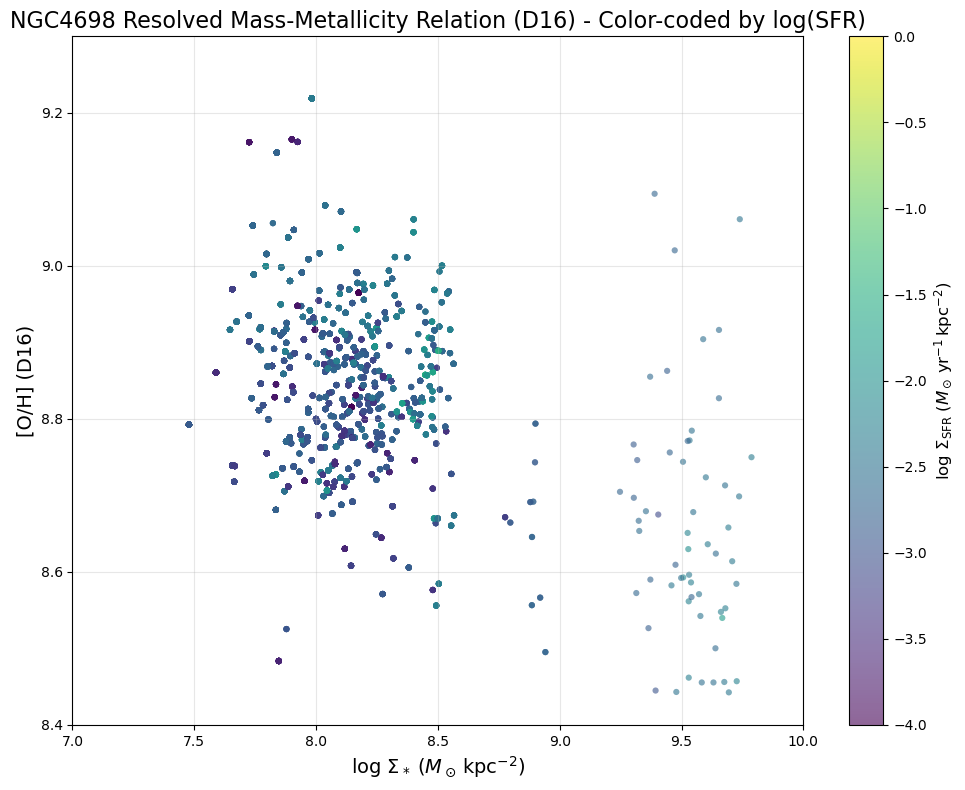

Successfully plotted spatially-resolved MZR for NGC4698 with log(SFR) color-coding


In [1]:
# ------------------------------------------------------------------
# NGC4698 Resolved MZR (D16) - Color-coded by log(SFR)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS


def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and D16 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
    return sigM, sigSFR_HII, oh_d16

# Create single plot figure
fig, ax = plt.subplots(figsize=(10, 8))

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps using the provided function
    logSigmaM, logSigmaSFR, oh_d16 = load_maps(gal)
    
    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_d16) & np.isfinite(logSigmaSFR)

    # Create scatter plot color-coded by log(SFR)
    scatter = ax.scatter(
        logSigmaM[good],
        oh_d16[good],
        c=logSigmaSFR[good],
        s=20, 
        alpha=0.6,
        cmap='viridis',
        vmin=-4,
        vmax=0,
        edgecolors='none'
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', 
                   fontsize=12)
    
    print(f"Plotted {np.sum(good)} pixels for {gal}")
    print(f"log(SFR) range: {logSigmaSFR[good].min():.2f} to {logSigmaSFR[good].max():.2f}")
    
else:
    print(f"Data files not found for {gal}")

# Final cosmetics
ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
ax.set_ylabel(r'[O/H] (D16)', fontsize=14)
ax.set_title(f'{gal} Resolved Mass-Metallicity Relation (D16) - Color-coded by log(SFR)', fontsize=16)
ax.set_xlim(7, 10)
ax.set_ylim(8.4, 9.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Successfully plotted spatially-resolved MZR for {gal} with log(SFR) color-coding")

Plotted 10065 pixels for NGC4698
log(SFR) range: -4.09 to -1.54


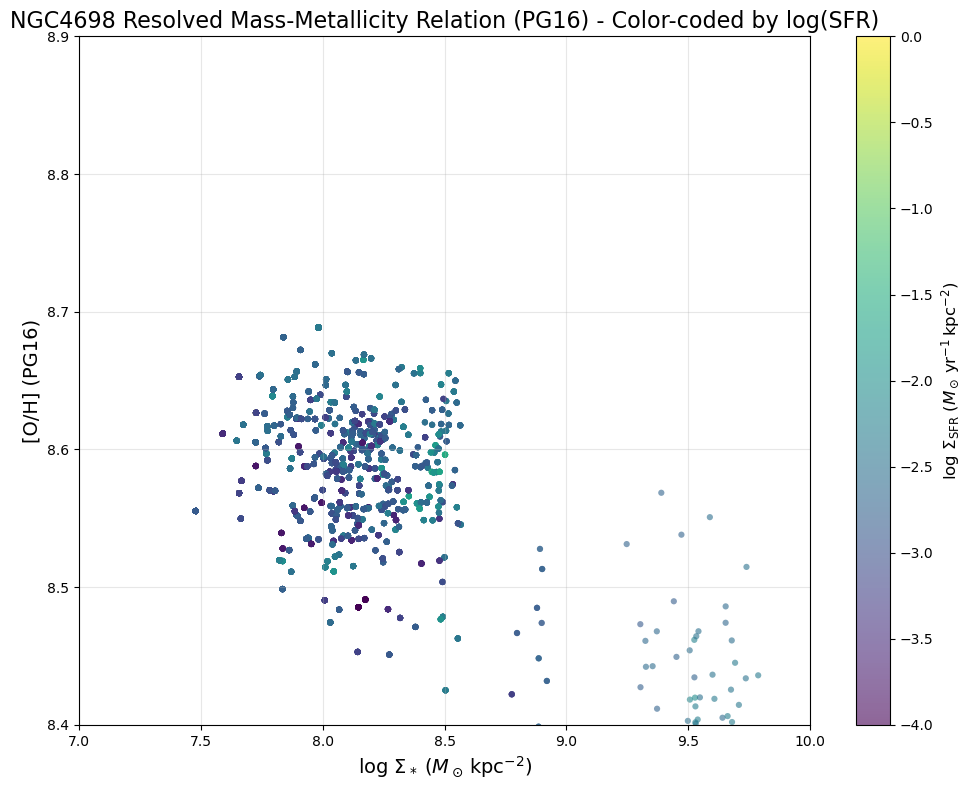

Successfully plotted spatially-resolved MZR for NGC4698 with PG16 metallicity and log(SFR) color-coding


In [2]:
# Update from D16 to PG16 metallicity
def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and PG16 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data  # Changed from D16 to PG16
    return sigM, sigSFR_HII, oh_pg16

# Create new plot figure
fig, ax = plt.subplots(figsize=(10, 8))

if bin_file.exists() and gas_file.exists():
    # Load maps with PG16 metallicity
    logSigmaM, logSigmaSFR, oh_pg16 = load_maps(gal)
    
    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_pg16) & np.isfinite(logSigmaSFR)

    # Create scatter plot color-coded by log(SFR)
    scatter = ax.scatter(
        logSigmaM[good],
        oh_pg16[good],
        c=logSigmaSFR[good],
        s=20, 
        alpha=0.6,
        cmap='viridis',
        vmin=-4,
        vmax=0,
        edgecolors='none'
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', 
                   fontsize=12)
    
    print(f"Plotted {np.sum(good)} pixels for {gal}")
    print(f"log(SFR) range: {logSigmaSFR[good].min():.2f} to {logSigmaSFR[good].max():.2f}")
    
else:
    print(f"Data files not found for {gal}")

# Final cosmetics
ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
ax.set_ylabel(r'[O/H] (PG16)', fontsize=14)  # Updated label
ax.set_title(f'{gal} Resolved Mass-Metallicity Relation (PG16) - Color-coded by log(SFR)', fontsize=16)  # Updated title
ax.set_xlim(7, 10)
ax.set_ylim(8.4, 8.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Successfully plotted spatially-resolved MZR for {gal} with PG16 metallicity and log(SFR) color-coding")

Plotted 10181 pixels for NGC4698
log(SFR) range: -4.09 to -1.54


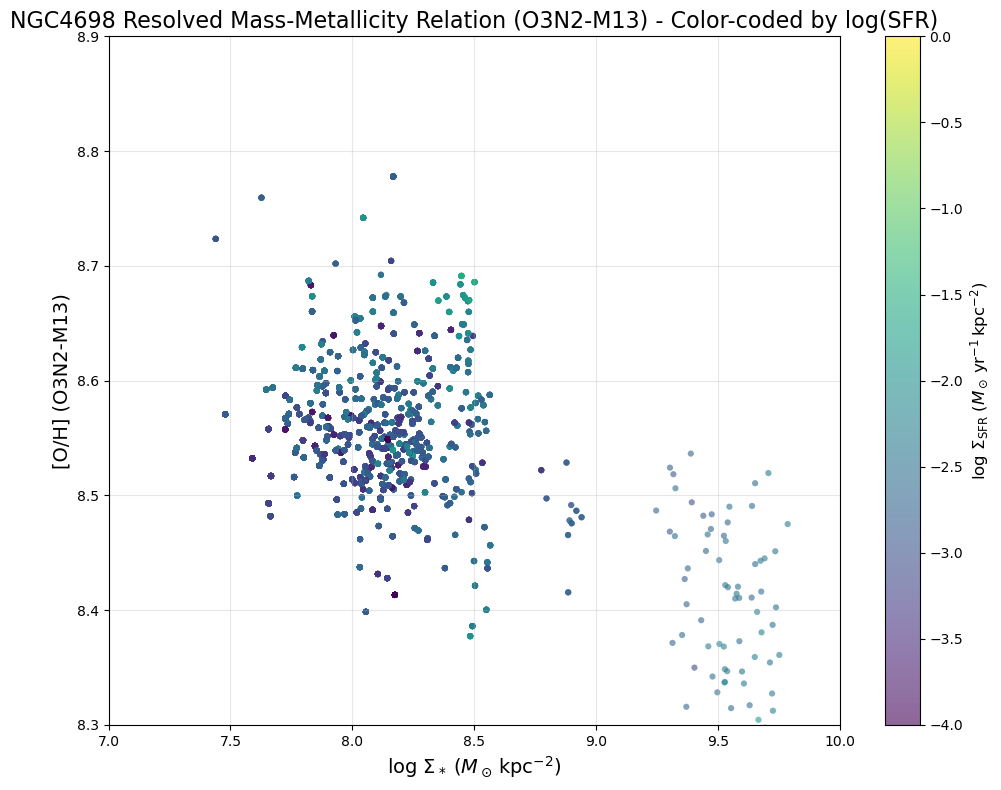

Successfully plotted spatially-resolved MZR for NGC4698 with O3N2-M13 metallicity and log(SFR) color-coding


In [3]:
# Update from PG16 to O3N2-M13 metallicity
def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and O3N2-M13 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data  # Changed from PG16 to O3N2-M13
    return sigM, sigSFR_HII, oh_o3n2_m13

# Create new plot figure
fig, ax = plt.subplots(figsize=(10, 8))

if bin_file.exists() and gas_file.exists():
    # Load maps with O3N2-M13 metallicity
    logSigmaM, logSigmaSFR, oh_o3n2_m13 = load_maps(gal)
    
    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2_m13) & np.isfinite(logSigmaSFR)

    # Create scatter plot color-coded by log(SFR)
    scatter = ax.scatter(
        logSigmaM[good],
        oh_o3n2_m13[good],
        c=logSigmaSFR[good],
        s=20, 
        alpha=0.6,
        cmap='viridis',
        vmin=-4,
        vmax=0,
        edgecolors='none'
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', 
                   fontsize=12)
    
    print(f"Plotted {np.sum(good)} pixels for {gal}")
    print(f"log(SFR) range: {logSigmaSFR[good].min():.2f} to {logSigmaSFR[good].max():.2f}")
    
else:
    print(f"Data files not found for {gal}")

# Final cosmetics
ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
ax.set_ylabel(r'[O/H] (O3N2-M13)', fontsize=14)  # Updated label
ax.set_title(f'{gal} Resolved Mass-Metallicity Relation (O3N2-M13) - Color-coded by log(SFR)', fontsize=16)  # Updated title
ax.set_xlim(7, 10)
ax.set_ylim(8.3, 8.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Successfully plotted spatially-resolved MZR for {gal} with O3N2-M13 metallicity and log(SFR) color-coding")

Plotted 10181 pixels for NGC4698
log(SFR) range: -4.09 to -1.54


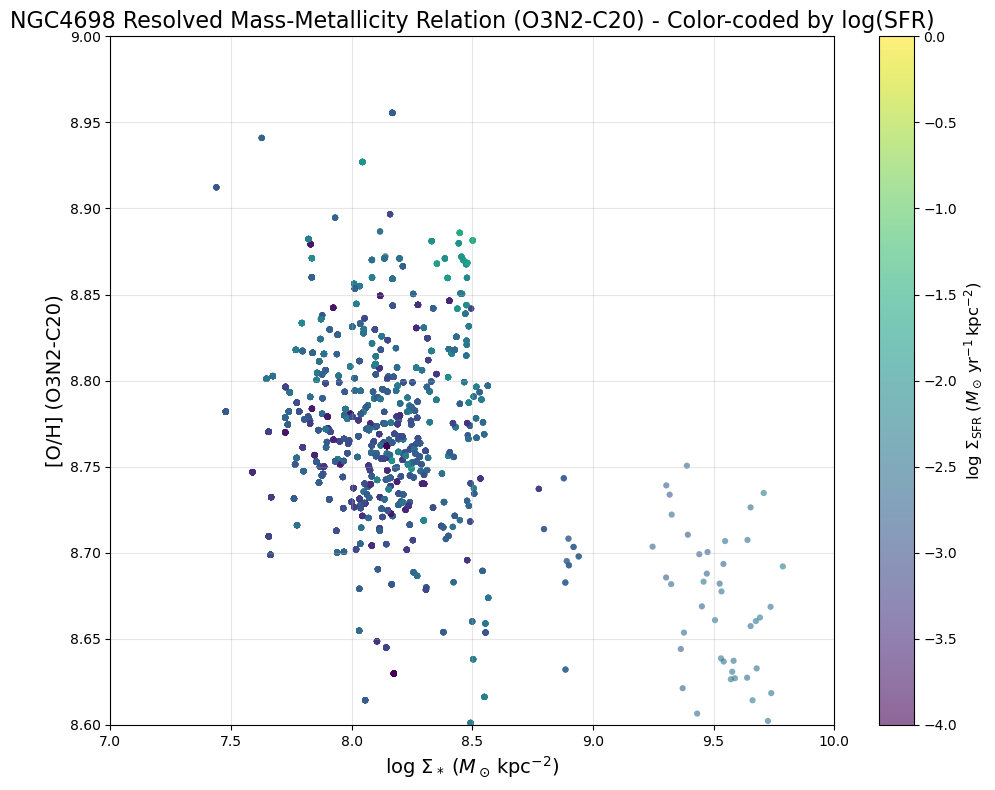

Successfully plotted spatially-resolved MZR for NGC4698 with O3N2-C20 metallicity and log(SFR) color-coding


In [4]:
# Update from O3N2-M13 to O3N2-C20 metallicity
def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and O3N2-C20 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data  # Changed from O3N2-M13 to O3N2-C20
    return sigM, sigSFR_HII, oh_o3n2_c20

# Create new plot figure
fig, ax = plt.subplots(figsize=(10, 8))

if bin_file.exists() and gas_file.exists():
    # Load maps with O3N2-C20 metallicity
    logSigmaM, logSigmaSFR, oh_o3n2_c20 = load_maps(gal)
    
    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2_c20) & np.isfinite(logSigmaSFR)

    # Create scatter plot color-coded by log(SFR)
    scatter = ax.scatter(
        logSigmaM[good],
        oh_o3n2_c20[good],
        c=logSigmaSFR[good],
        s=20, 
        alpha=0.6,
        cmap='viridis',
        vmin=-4,
        vmax=0,
        edgecolors='none'
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', 
                   fontsize=12)
    
    print(f"Plotted {np.sum(good)} pixels for {gal}")
    print(f"log(SFR) range: {logSigmaSFR[good].min():.2f} to {logSigmaSFR[good].max():.2f}")
    
else:
    print(f"Data files not found for {gal}")

# Final cosmetics
ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
ax.set_ylabel(r'[O/H] (O3N2-C20)', fontsize=14)  # Updated label
ax.set_title(f'{gal} Resolved Mass-Metallicity Relation (O3N2-C20) - Color-coded by log(SFR)', fontsize=16)  # Updated title
ax.set_xlim(7, 10)
ax.set_ylim(8.6, 9.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Successfully plotted spatially-resolved MZR for {gal} with O3N2-C20 metallicity and log(SFR) color-coding")

Total pixels: 722912
Common valid pixels across all calibrations: 10042
D16: Plotted 10042 pixels (common spaxels)
PG16: Plotted 10042 pixels (common spaxels)
O3N2-M13: Plotted 10042 pixels (common spaxels)
O3N2-C20: Plotted 10042 pixels (common spaxels)


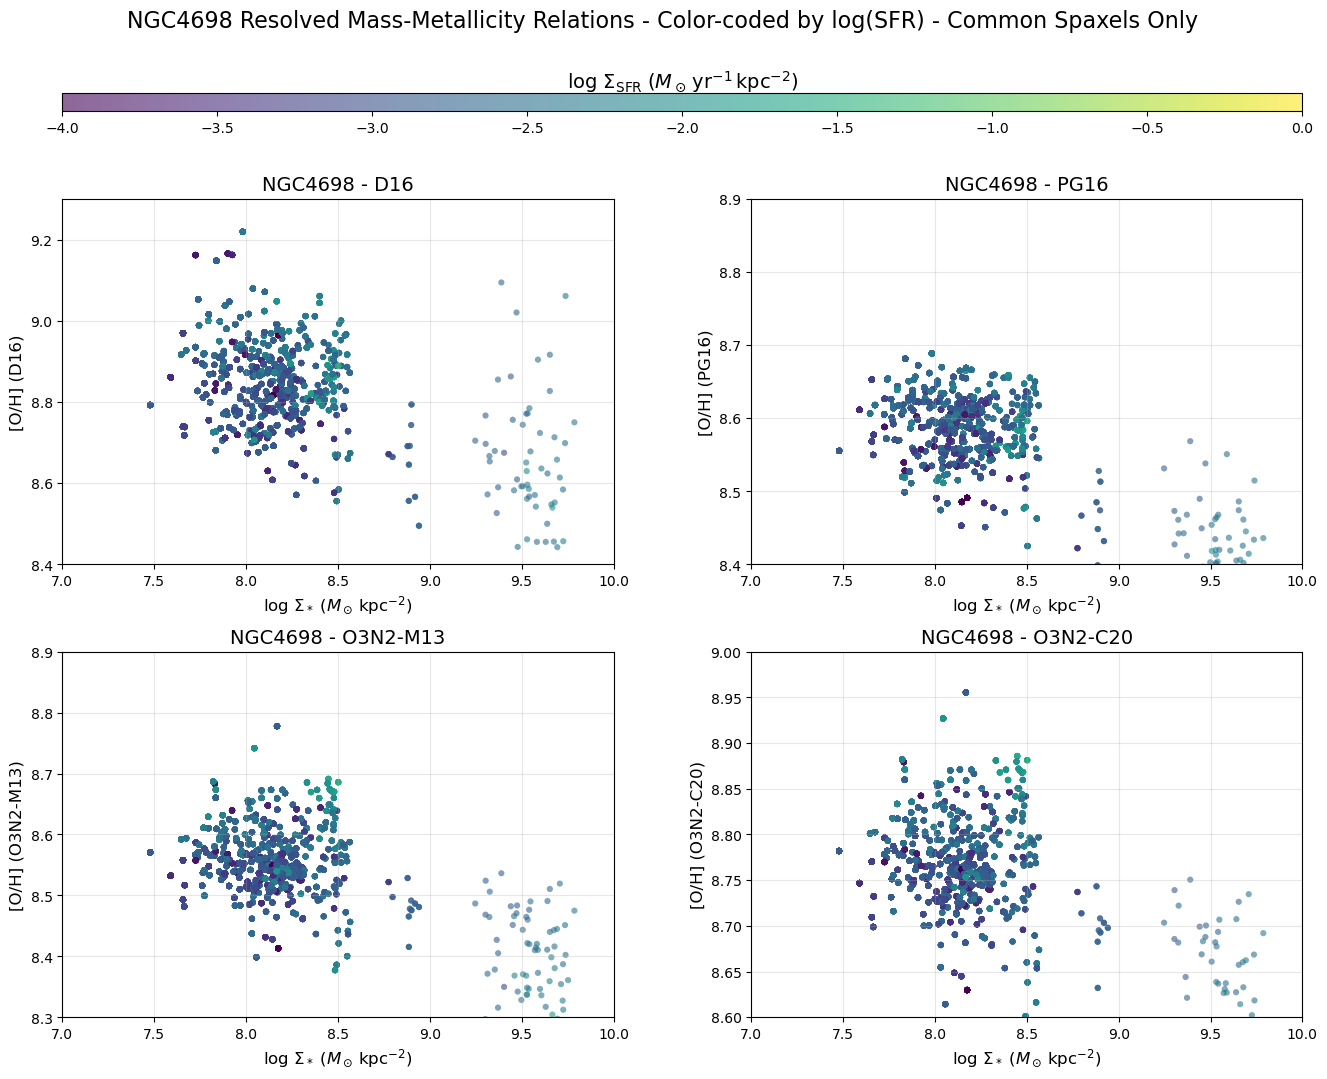


Successfully created combined plot with 4 metallicity calibrations for NGC4698 using common spaxels


In [5]:
# Combined plot with 4 metallicity calibrations
# 2x2 subplots with shared horizontal colorbar at top

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from astropy.io import fits

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for a galaxy"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
    return sigM, sigSFR_HII, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20

# Setup
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data
    logSigmaM, logSigmaSFR, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20 = load_maps_all_calibrations(gal)
    
    # Find common spaxels across ALL metallicity calibrations and other required data
    common_mask = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR) & 
                   np.isfinite(oh_d16) & np.isfinite(oh_pg16) & 
                   np.isfinite(oh_o3n2_m13) & np.isfinite(oh_o3n2_c20))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    
    # Create figure with 2x2 subplots and space for colorbar
    fig = plt.figure(figsize=(16, 12))
    
    # Create a grid layout: colorbar at top, then 2x2 subplots
    gs = fig.add_gridspec(3, 2, height_ratios=[0.05, 1, 1], hspace=0.35, wspace=0.25)
    
    # Colorbar axis (spans full width at top)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Subplot axes
    ax1 = fig.add_subplot(gs[1, 0])  # Top left - D16
    ax2 = fig.add_subplot(gs[1, 1])  # Top right - PG16
    ax3 = fig.add_subplot(gs[2, 0])  # Bottom left - O3N2-M13
    ax4 = fig.add_subplot(gs[2, 1])  # Bottom right - O3N2-C20
    
    # Data for each calibration
    calibrations = [
        (oh_d16, 'D16', (8.4, 9.3), ax1),
        (oh_pg16, 'PG16', (8.4, 8.9), ax2),
        (oh_o3n2_m13, 'O3N2-M13', (8.3, 8.9), ax3),
        (oh_o3n2_c20, 'O3N2-C20', (8.6, 9.0), ax4)
    ]
    
    # Create scatter plots for each calibration using common mask
    scatters = []
    for oh_data, calib_name, ylim, ax in calibrations:
        # Use common mask for all calibrations
        
        # Create scatter plot
        scatter = ax.scatter(
            logSigmaM[common_mask],
            oh_data[common_mask],
            c=logSigmaSFR[common_mask],
            s=20,
            alpha=0.6,
            cmap='viridis',
            vmin=-4,
            vmax=0,
            edgecolors='none'
        )
        scatters.append(scatter)
        
        # Formatting
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax.set_title(f'{gal} - {calib_name}', fontsize=14)
        ax.set_xlim(7, 10)
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3)
        
        print(f"{calib_name}: Plotted {np.sum(common_mask)} pixels (common spaxels)")
    
    # Add shared colorbar at the top
    cbar = fig.colorbar(scatters[0], cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', 
                   fontsize=14)
    cbar.ax.xaxis.set_label_position('top')
    
    # Add overall title
    fig.suptitle(f'{gal} Resolved Mass-Metallicity Relations - Color-coded by log(SFR) - Common Spaxels Only', 
                 fontsize=16, y=0.95)
    
    plt.show()
    
    print(f"\nSuccessfully created combined plot with 4 metallicity calibrations for {gal} using common spaxels")
    
else:
    print(f"Data files not found for {gal}")

Total pixels: 722912
Common valid pixels across all calibrations: 10042
D16: Plotted 10042 pixels in hexagonal bins (common spaxels)
PG16: Plotted 10042 pixels in hexagonal bins (common spaxels)
O3N2-M13: Plotted 10042 pixels in hexagonal bins (common spaxels)
O3N2-C20: Plotted 10042 pixels in hexagonal bins (common spaxels)


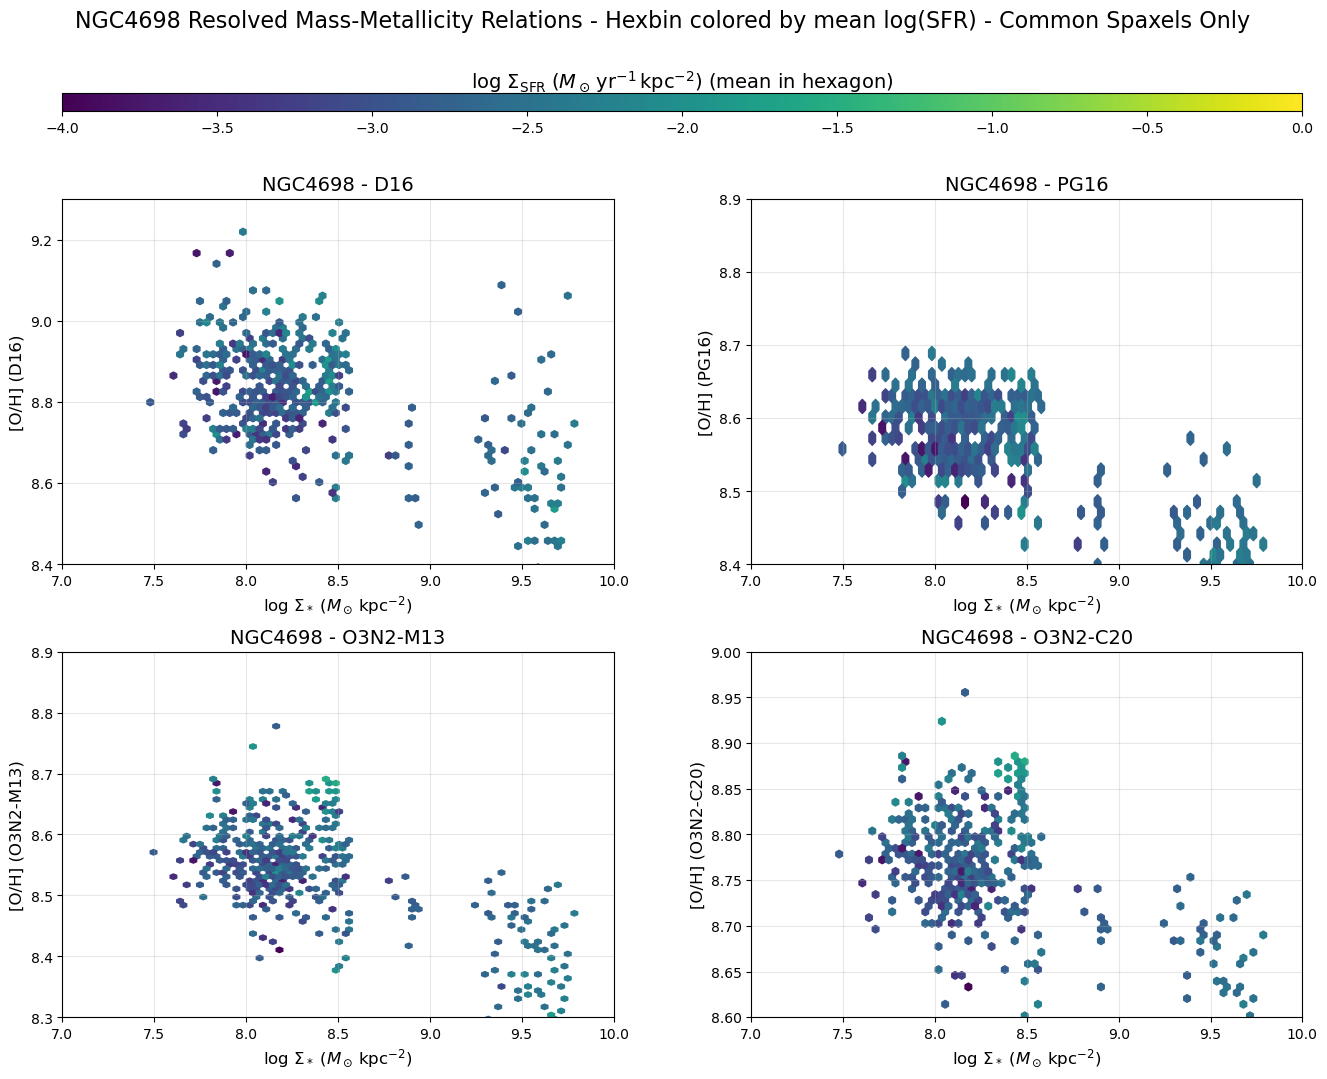


Successfully created combined hexbin plot with 4 metallicity calibrations for NGC4698 using common spaxels


In [6]:
# Combined plot with 4 metallicity calibrations using hexagon plots
# 2x2 subplots with shared horizontal colorbar at top

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from astropy.io import fits

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for a galaxy"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
    return sigM, sigSFR_HII, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20

# Setup
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data
    logSigmaM, logSigmaSFR, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20 = load_maps_all_calibrations(gal)
    
    # Find common spaxels across ALL metallicity calibrations and other required data
    common_mask = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR) & 
                   np.isfinite(oh_d16) & np.isfinite(oh_pg16) & 
                   np.isfinite(oh_o3n2_m13) & np.isfinite(oh_o3n2_c20))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    
    # Create figure with 2x2 subplots and space for colorbar
    fig = plt.figure(figsize=(16, 12))
    
    # Create a grid layout: colorbar at top, then 2x2 subplots
    gs = fig.add_gridspec(3, 2, height_ratios=[0.05, 1, 1], hspace=0.35, wspace=0.25)
    
    # Colorbar axis (spans full width at top)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Subplot axes
    ax1 = fig.add_subplot(gs[1, 0])  # Top left - D16
    ax2 = fig.add_subplot(gs[1, 1])  # Top right - PG16
    ax3 = fig.add_subplot(gs[2, 0])  # Bottom left - O3N2-M13
    ax4 = fig.add_subplot(gs[2, 1])  # Bottom right - O3N2-C20
    
    # Data for each calibration
    calibrations = [
        (oh_d16, 'D16', (8.4, 9.3), ax1),
        (oh_pg16, 'PG16', (8.4, 8.9), ax2),
        (oh_o3n2_m13, 'O3N2-M13', (8.3, 8.9), ax3),
        (oh_o3n2_c20, 'O3N2-C20', (8.6, 9.0), ax4)
    ]
    
    # Create hexagon plots for each calibration using common mask
    hexbins = []
    for oh_data, calib_name, ylim, ax in calibrations:
        # Use common mask for all calibrations
        
        # Create hexbin plot with SFR as color (using reduce_C_function='mean' for average SFR in each hexagon)
        hexbin = ax.hexbin(
            logSigmaM[common_mask],
            oh_data[common_mask],
            C=logSigmaSFR[common_mask],
            gridsize=64,
            cmap='viridis',
            vmin=-4,
            vmax=0,
            reduce_C_function=np.mean,
            mincnt=1  # Only show hexagons with at least 1 data point
        )
        hexbins.append(hexbin)
        
        # Formatting
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax.set_title(f'{gal} - {calib_name}', fontsize=14)
        ax.set_xlim(7, 10)
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3)
        
        print(f"{calib_name}: Plotted {np.sum(common_mask)} pixels in hexagonal bins (common spaxels)")
    
    # Add shared colorbar at the top
    cbar = fig.colorbar(hexbins[0], cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$ (mean in hexagon)', 
                   fontsize=14)
    cbar.ax.xaxis.set_label_position('top')
    
    # Add overall title
    fig.suptitle(f'{gal} Resolved Mass-Metallicity Relations - Hexbin colored by mean log(SFR) - Common Spaxels Only', 
                 fontsize=16, y=0.95)
    
    plt.show()
    
    print(f"\nSuccessfully created combined hexbin plot with 4 metallicity calibrations for {gal} using common spaxels")
    
else:
    print(f"Data files not found for {gal}")

## 20250919 Divided into different $\Sigma_{\mathrm{SFR}}$ bin

Σ_SFR bins: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
Bin centers: [-3.75 -3.25 -2.75 -2.25 -1.75 -1.25 -0.75 -0.25]
Bin -4.0 to -3.5: N=610 pixels
Bin -3.5 to -3.0: N=2617 pixels
Bin -3.0 to -2.5: N=4655 pixels
Bin -2.5 to -2.0: N=1900 pixels
Bin -2.0 to -1.5: N=204 pixels
Bin -1.5 to -1.0: only 0 pixels, skipping
Bin -1.0 to -0.5: only 0 pixels, skipping
Bin -0.5 to 0.0: only 0 pixels, skipping


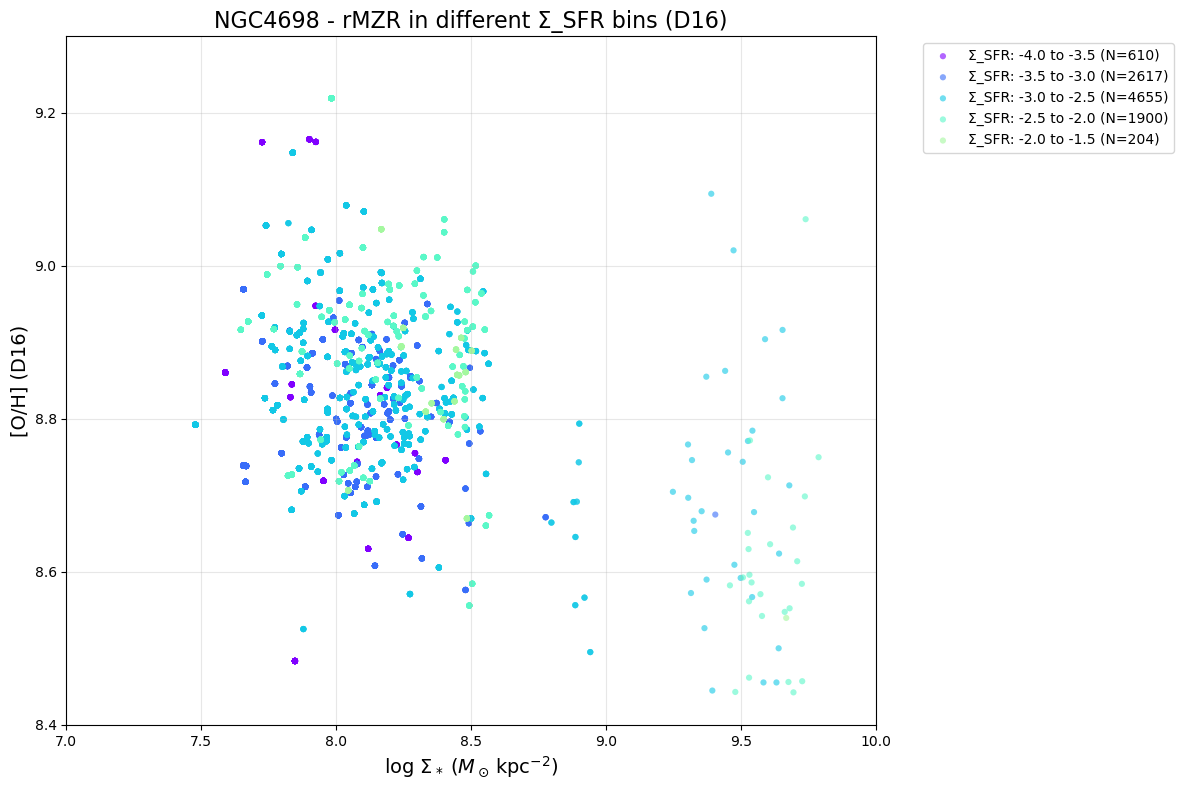


Analysis complete for NGC4698 rMZR behavior in Σ_SFR bins (D16 only)


In [7]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins (D16 only)
# Σ_SFR bins: -4 to 1 with 0.5 bin width
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and D16 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
    return sigM, sigSFR_HII, oh_d16

# Focus on NGC4698 only - D16 metallicity
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps
    logSigmaM, logSigmaSFR, oh_d16 = load_maps(gal)

    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_d16) & np.isfinite(logSigmaSFR)
    
    logSigmaSFR_good = logSigmaSFR[good]
    oh_d16_good = oh_d16[good]
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)  # Creates bins: [-4, -3.5], [-3.5, -3], etc.
    sfr_bin_centers = sfr_bin_edges[:-1] + 0.25  # Center of each bin
    n_bins = len(sfr_bin_centers)
    
    print(f"Σ_SFR bins: {sfr_bin_edges}")
    print(f"Bin centers: {sfr_bin_centers}")
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create single combined plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select pixels in this Σ_SFR bin
        in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
        n_pixels = np.sum(in_bin)
        
        if n_pixels < 10:  # Skip bins with too few pixels
            print(f"Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
            continue
            
        # Get data for this bin
        x_bin = logSigmaM[good][in_bin]
        y_bin = oh_d16_good[in_bin]
        
        # Add to plot
        ax.scatter(x_bin, y_bin, c=[colors[i]], s=20, alpha=0.6, 
                  label=f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                  edgecolors='none')
        
        print(f"Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
    
    # Plot formatting
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax.set_ylabel(r'[O/H] (D16)', fontsize=14)
    ax.set_title(f'{gal} - rMZR in different Σ_SFR bins (D16)', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(7, 10)
    ax.set_ylim(8.4, 9.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nAnalysis complete for {gal} rMZR behavior in Σ_SFR bins (D16 only)")

Σ_M bins: [ 7.   7.5  8.   8.5  9.   9.5 10. ]
Bin centers: [7.25 7.75 8.25 8.75 9.25 9.75]
Bin 7.0 to 7.5: N=116 pixels
Bin 7.5 to 8.0: N=3989 pixels
Bin 8.0 to 8.5: N=5712 pixels
Bin 8.5 to 9.0: N=244 pixels
Bin 9.0 to 9.5: N=25 pixels
Bin 9.5 to 10.0: N=43 pixels


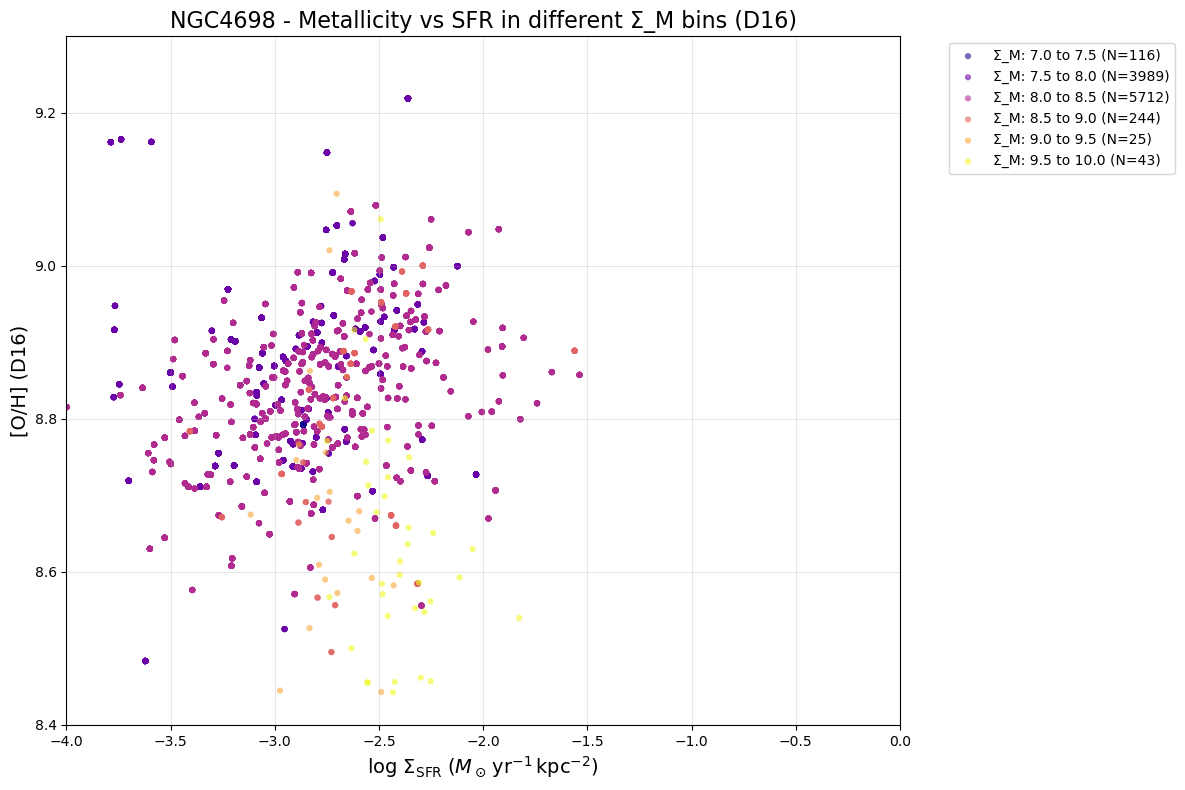


Analysis complete for NGC4698 metallicity vs SFR behavior in Σ_M bins (D16 only)


In [8]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in stellar mass surface density bins (D16 only)
# Mass bins: 7 to 10 with 0.5 bin width
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and D16 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
    return sigM, sigSFR_HII, oh_d16

# Focus on NGC4698 only - D16 metallicity
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps
    logSigmaM, logSigmaSFR, oh_d16 = load_maps(gal)

    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_d16) & np.isfinite(logSigmaSFR)
    
    logSigmaSFR_good = logSigmaSFR[good]
    oh_d16_good = oh_d16[good]
    
    # Define stellar mass surface density bins: 7 to 10 with 0.5 bin width
    mass_bin_edges = np.arange(7, 10.5, 0.5)  # Creates bins: [7, 7.5], [7.5, 8], etc.
    mass_bin_centers = mass_bin_edges[:-1] + 0.25  # Center of each bin
    n_bins = len(mass_bin_centers)
    
    print(f"Σ_M bins: {mass_bin_edges}")
    print(f"Bin centers: {mass_bin_centers}")
    
    # Colors for different bins
    colors = plt.cm.plasma(np.linspace(0, 1, n_bins))
    
    # Create single combined plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select pixels in this Σ_M bin
        in_bin = (logSigmaM[good] >= bin_start) & (logSigmaM[good] < bin_end)
        n_pixels = np.sum(in_bin)
        
        if n_pixels < 10:  # Skip bins with too few pixels
            print(f"Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
            continue
            
        # Get data for this bin
        x_bin = logSigmaSFR_good[in_bin]  # SFR on x-axis
        y_bin = oh_d16_good[in_bin]       # Metallicity on y-axis
        
        # Add to plot
        ax.scatter(x_bin, y_bin, c=[colors[i]], s=20, alpha=0.6, 
                  label=f'Σ_M: {bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                  edgecolors='none')
        
        print(f"Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
    
    # Plot formatting
    ax.set_xlabel(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax.set_ylabel(r'[O/H] (D16)', fontsize=14)
    ax.set_title(f'{gal} - Metallicity vs SFR in different Σ_M bins (D16)', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 0)
    ax.set_ylim(8.4, 9.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nAnalysis complete for {gal} metallicity vs SFR behavior in Σ_M bins (D16 only)")

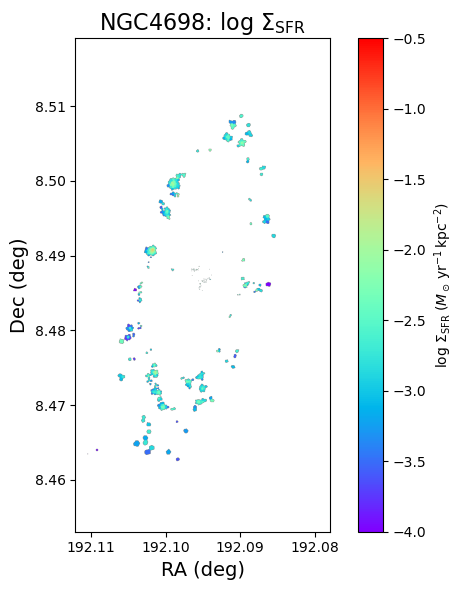

In [9]:
# ------------------------------------------------------------------
# 0.  List galaxies and pin one colour to each
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = ['NGC4698']        # auto-detect
cmap   = plt.get_cmap('tab20').colors                      # 20 hues
colour = {g: cmap[i % len(cmap)] for i, g in enumerate(galaxies)}

# ------------------------------------------------------------------
# 1.  Helper: read the two maps
# ------------------------------------------------------------------
def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
        mass_header = h['LOGMASS_SURFACE_DENSITY'].header
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR = h['LOGSFR_SURFACE_DENSITY_HII'].data
        gas_header = h['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, wcs, mass_header, gas_header

# Update the code to show only the middle panel (SFR map)
for gal in galaxies:
    sigM, sigSFR, wcs, mass_header, gas_header = load_maps(gal)
    good = np.isfinite(sigM) & np.isfinite(sigSFR)

    # Convert pixel area to physical area in pc²
    legacy_wcs2 = WCS(gas_header).celestial  # strip spectral axis
    
    # Get the extent from WCS for proper coordinate axes
    y_size, x_size = sigM.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    # Convert pixel coordinates to world coordinates
    ra, dec = legacy_wcs2.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]  # [left, right, bottom, top]

    fig = plt.figure(figsize=(8, 6))

    # --- Σ_SFR map only -----------------------------------------------
    ax = fig.add_subplot(1, 1, 1)
    im = ax.imshow(sigSFR, origin='lower', cmap='rainbow',extent=extent, vmin=-4, vmax=-0.5)
    ax.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    # Ensure RA axis increases from left to right
    # ax.invert_xaxis()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, 
                label=r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$')

    plt.tight_layout()
    plt.show()


Σ_SFR bins: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
Bin centers: [-3.75 -3.25 -2.75 -2.25 -1.75 -1.25 -0.75 -0.25]
Bin -4.0 to -3.5: N=610 pixels
Bin -3.5 to -3.0: N=2617 pixels
Bin -3.0 to -2.5: N=4655 pixels
Bin -2.5 to -2.0: N=1900 pixels
Bin -2.0 to -1.5: N=204 pixels
Bin -1.5 to -1.0: only 0 pixels, skipping
Bin -1.0 to -0.5: only 0 pixels, skipping
Bin -0.5 to 0.0: only 0 pixels, skipping


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17443/705998299.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')


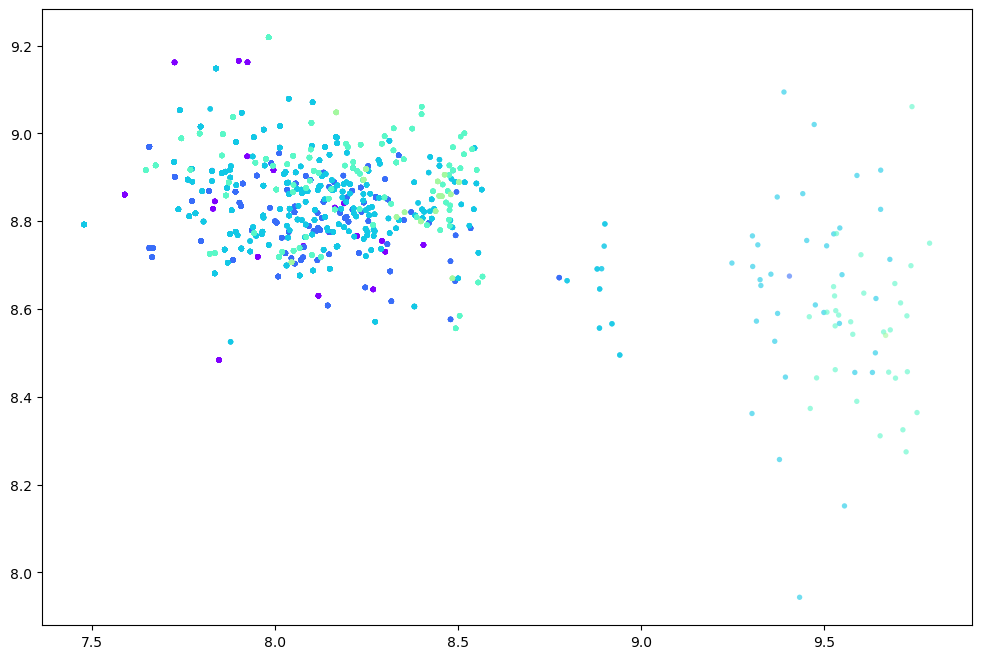

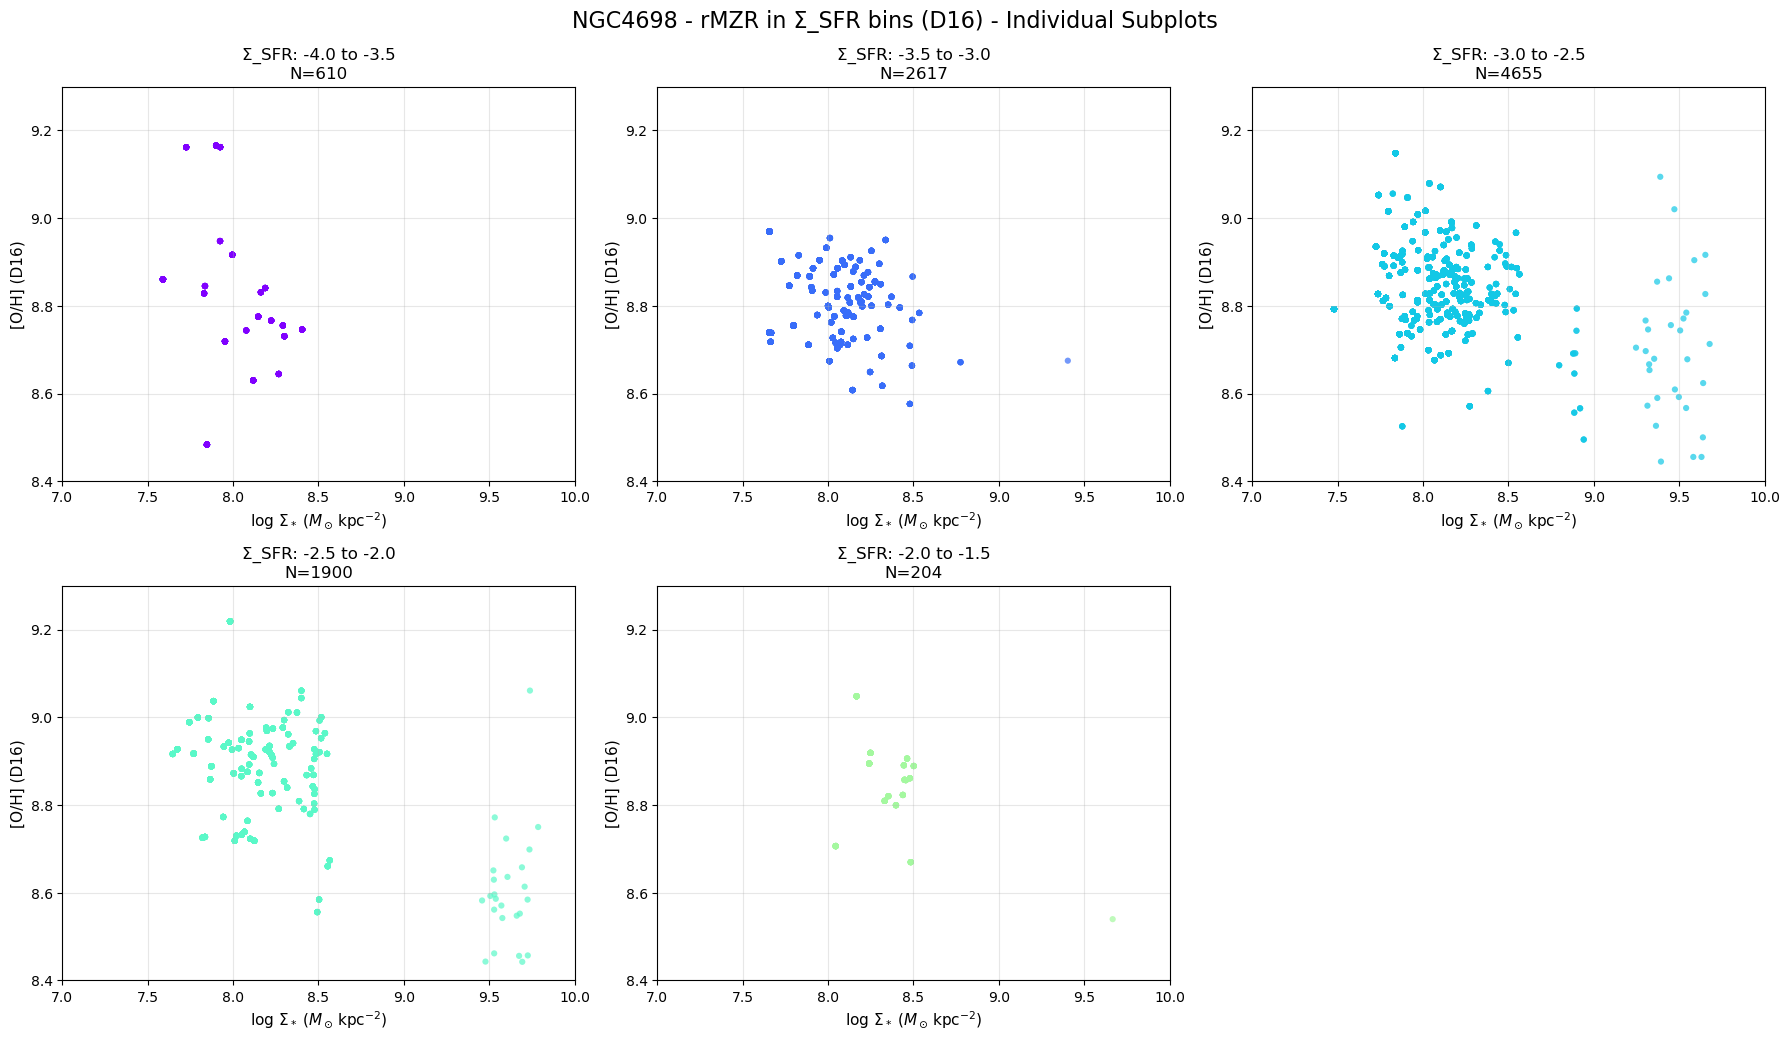

<Figure size 640x480 with 0 Axes>


Analysis complete for NGC4698 rMZR behavior in Σ_SFR bins with individual subplots (D16 only)


In [10]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins (D16 only) - Individual subplots
# Σ_SFR bins: -4 to 1 with 0.5 bin width, each bin in separate subplot
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and D16 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
    return sigM, sigSFR_HII, oh_d16

# Focus on NGC4698 only - D16 metallicity
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps
    logSigmaM, logSigmaSFR, oh_d16 = load_maps(gal)

    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_d16) & np.isfinite(logSigmaSFR)
    
    logSigmaSFR_good = logSigmaSFR[good]
    oh_d16_good = oh_d16[good]
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)  # Creates bins: [-4, -3.5], [-3.5, -3], etc.
    sfr_bin_centers = sfr_bin_edges[:-1] + 0.25  # Center of each bin
    n_bins = len(sfr_bin_centers)
    
    print(f"Σ_SFR bins: {sfr_bin_edges}")
    print(f"Bin centers: {sfr_bin_centers}")
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with subplots (3x3 grid to accommodate up to 9 bins)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    # Also create combined plot
    fig_combined, ax_combined = plt.subplots(figsize=(12, 8))
    
    valid_bins = 0  # Counter for valid bins
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select pixels in this Σ_SFR bin
        in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
        n_pixels = np.sum(in_bin)
        
        if n_pixels < 10:  # Skip bins with too few pixels
            print(f"Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
            continue
            
        # Get data for this bin
        x_bin = logSigmaM[good][in_bin]
        y_bin = oh_d16_good[in_bin]
        
        # Plot in individual subplot
        if valid_bins < len(axes):
            ax = axes[valid_bins]
            ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')
            
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
            ax.set_ylabel(r'[O/H] (D16)', fontsize=11)
            ax.set_title(f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f}\nN={n_pixels}', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(7, 10)
            ax.set_ylim(8.4, 9.3)
        
        # Add to combined plot
        ax_combined.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                          label=f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                          edgecolors='none')
        
        print(f"Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
        valid_bins += 1
    
    # Hide unused subplots
    for j in range(valid_bins, len(axes)):
        axes[j].set_visible(False)
    
    # Format subplot figure
    plt.figure(fig.number)
    plt.suptitle(f'{gal} - rMZR in Σ_SFR bins (D16) - Individual Subplots', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()
    
    # Format combined plot
    plt.figure(fig_combined.number)
    ax_combined.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax_combined.set_ylabel(r'[O/H] (D16)', fontsize=14)
    ax_combined.set_title(f'{gal} - rMZR in different Σ_SFR bins (D16) - Combined', fontsize=16)
    ax_combined.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_combined.grid(True, alpha=0.3)
    ax_combined.set_xlim(7, 10)
    ax_combined.set_ylim(8.4, 9.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nAnalysis complete for {gal} rMZR behavior in Σ_SFR bins with individual subplots (D16 only)")

Σ_SFR bins: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
Bin centers: [-3.75 -3.25 -2.75 -2.25 -1.75 -1.25 -0.75 -0.25]
Bin -4.0 to -3.5: N=581 pixels
Bin -3.5 to -3.0: N=2604 pixels
Bin -3.0 to -2.5: N=4633 pixels
Bin -2.5 to -2.0: N=1900 pixels
Bin -2.0 to -1.5: N=204 pixels
Bin -1.5 to -1.0: only 0 pixels, skipping
Bin -1.0 to -0.5: only 0 pixels, skipping
Bin -0.5 to 0.0: only 0 pixels, skipping


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17443/2191904742.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')


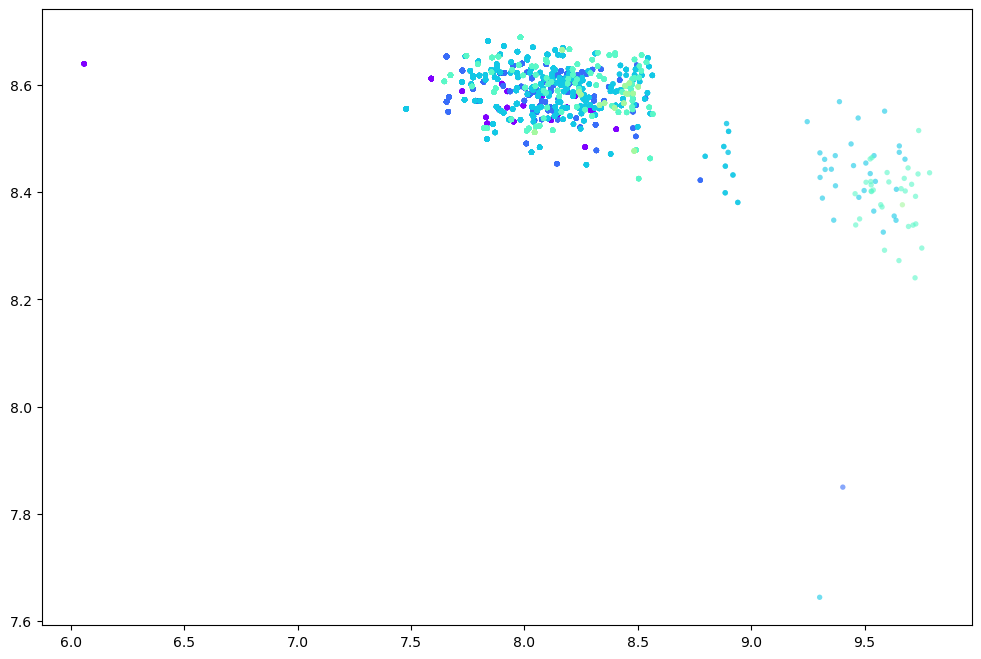

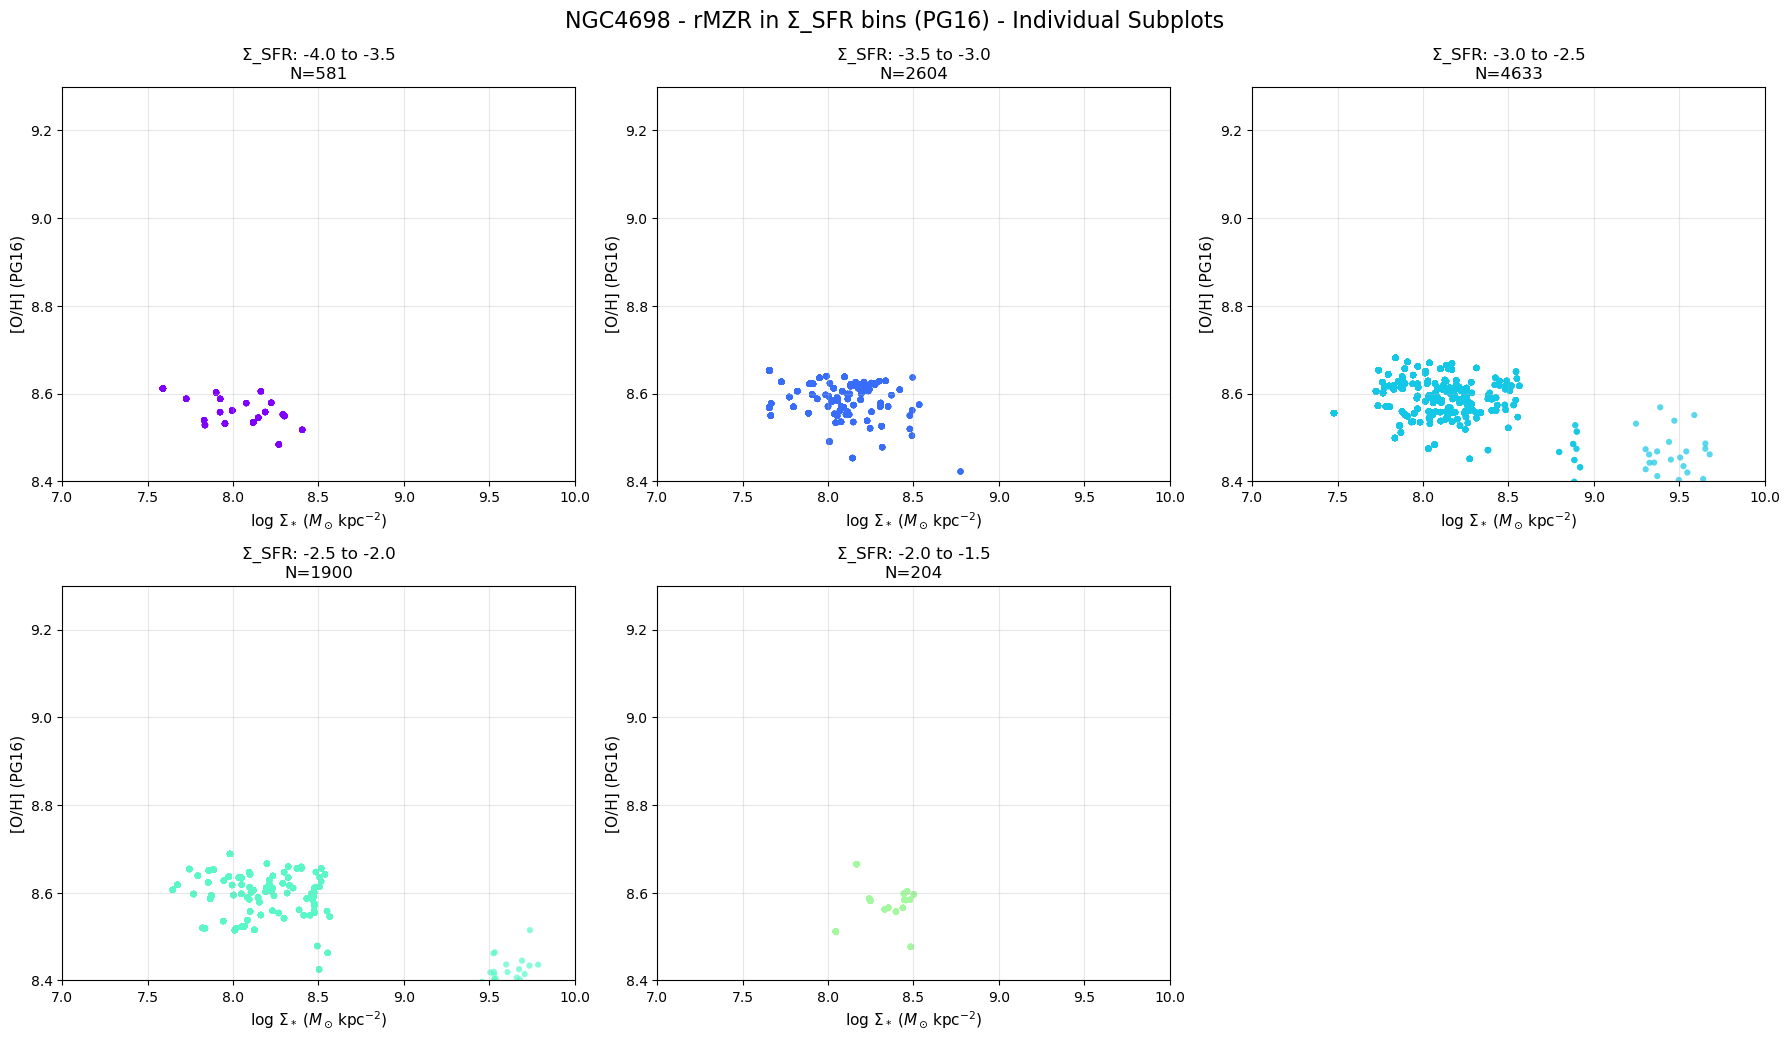

<Figure size 640x480 with 0 Axes>


Analysis complete for NGC4698 rMZR behavior in Σ_SFR bins with individual subplots (PG16 only)


In [11]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins (PG16 only) - Individual subplots
# Σ_SFR bins: -4 to 1 with 0.5 bin width, each bin in separate subplot
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and PG16 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
    return sigM, sigSFR_HII, oh_pg16

# Focus on NGC4698 only - PG16 metallicity
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps
    logSigmaM, logSigmaSFR, oh_pg16 = load_maps(gal)

    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_pg16) & np.isfinite(logSigmaSFR)
    
    logSigmaSFR_good = logSigmaSFR[good]
    oh_pg16_good = oh_pg16[good]
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)  # Creates bins: [-4, -3.5], [-3.5, -3], etc.
    sfr_bin_centers = sfr_bin_edges[:-1] + 0.25  # Center of each bin
    n_bins = len(sfr_bin_centers)
    
    print(f"Σ_SFR bins: {sfr_bin_edges}")
    print(f"Bin centers: {sfr_bin_centers}")
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with subplots (3x3 grid to accommodate up to 9 bins)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    # Also create combined plot
    fig_combined, ax_combined = plt.subplots(figsize=(12, 8))
    
    valid_bins = 0  # Counter for valid bins
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select pixels in this Σ_SFR bin
        in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
        n_pixels = np.sum(in_bin)
        
        if n_pixels < 10:  # Skip bins with too few pixels
            print(f"Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
            continue
            
        # Get data for this bin
        x_bin = logSigmaM[good][in_bin]
        y_bin = oh_pg16_good[in_bin]
        
        # Plot in individual subplot
        if valid_bins < len(axes):
            ax = axes[valid_bins]
            ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')
            
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
            ax.set_ylabel(r'[O/H] (PG16)', fontsize=11)
            ax.set_title(f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f}\nN={n_pixels}', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(7, 10)
            ax.set_ylim(8.4, 9.3)
        
        # Add to combined plot
        ax_combined.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                          label=f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                          edgecolors='none')
        
        print(f"Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
        valid_bins += 1
    
    # Hide unused subplots
    for j in range(valid_bins, len(axes)):
        axes[j].set_visible(False)
    
    # Format subplot figure
    plt.figure(fig.number)
    plt.suptitle(f'{gal} - rMZR in Σ_SFR bins (PG16) - Individual Subplots', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()
    
    # Format combined plot
    plt.figure(fig_combined.number)
    ax_combined.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax_combined.set_ylabel(r'[O/H] (PG16)', fontsize=14)
    ax_combined.set_title(f'{gal} - rMZR in different Σ_SFR bins (PG16) - Combined', fontsize=16)
    ax_combined.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_combined.grid(True, alpha=0.3)
    ax_combined.set_xlim(7, 10)
    ax_combined.set_ylim(8.4, 9.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nAnalysis complete for {gal} rMZR behavior in Σ_SFR bins with individual subplots (PG16 only)")

Σ_SFR bins: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
Bin centers: [-3.75 -3.25 -2.75 -2.25 -1.75 -1.25 -0.75 -0.25]
Bin -4.0 to -3.5: N=633 pixels
Bin -3.5 to -3.0: N=2625 pixels
Bin -3.0 to -2.5: N=4676 pixels
Bin -2.5 to -2.0: N=1900 pixels
Bin -2.0 to -1.5: N=204 pixels
Bin -1.5 to -1.0: only 0 pixels, skipping
Bin -1.0 to -0.5: only 0 pixels, skipping
Bin -0.5 to 0.0: only 0 pixels, skipping


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17443/2555162199.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')


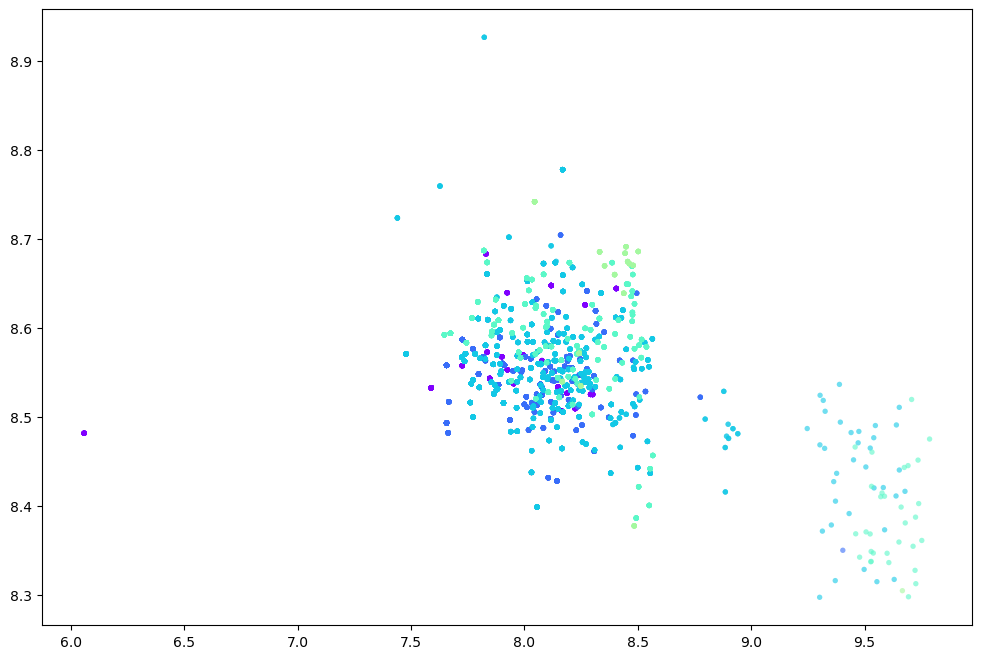

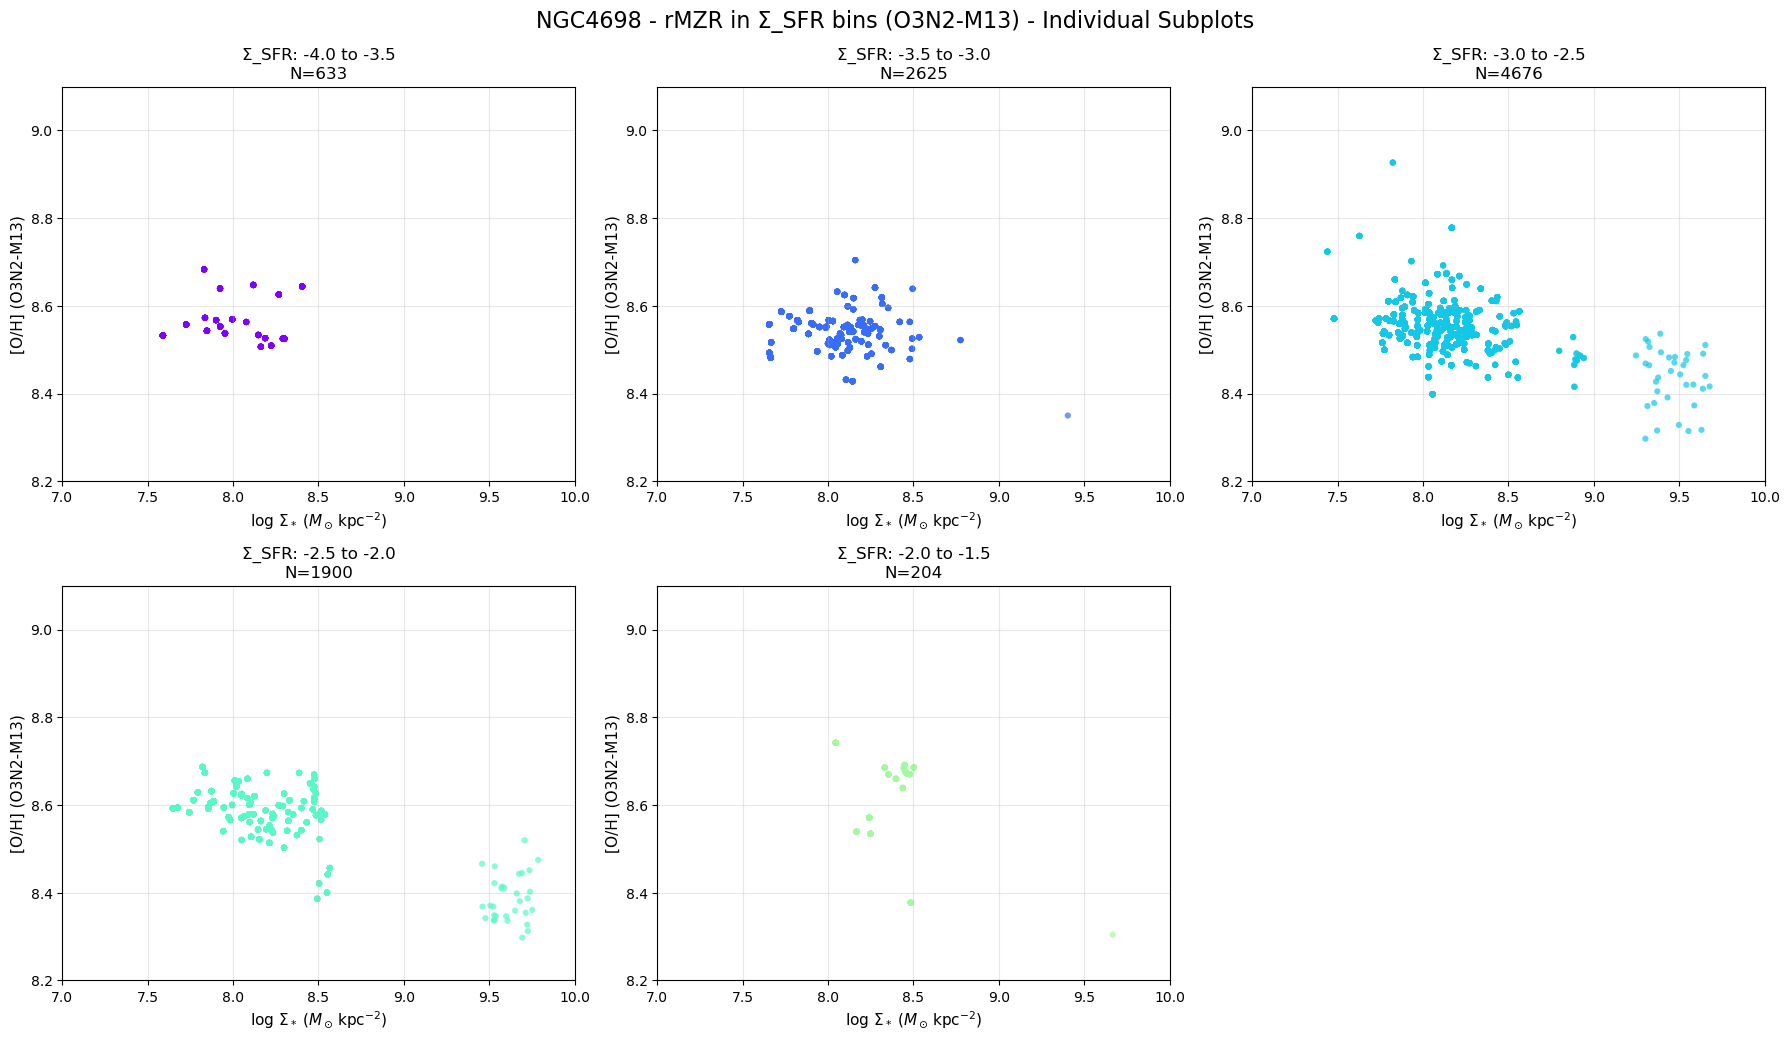

<Figure size 640x480 with 0 Axes>


Analysis complete for NGC4698 rMZR behavior in Σ_SFR bins with individual subplots (O3N2-M13 only)


In [12]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins (O3N2-M13 only) - Individual subplots
# Σ_SFR bins: -4 to 1 with 0.5 bin width, each bin in separate subplot
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and O3N2-M13 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
    return sigM, sigSFR_HII, oh_o3n2_m13

# Focus on NGC4698 only - O3N2-M13 metallicity
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps
    logSigmaM, logSigmaSFR, oh_o3n2_m13 = load_maps(gal)

    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2_m13) & np.isfinite(logSigmaSFR)
    
    logSigmaSFR_good = logSigmaSFR[good]
    oh_o3n2_m13_good = oh_o3n2_m13[good]
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)  # Creates bins: [-4, -3.5], [-3.5, -3], etc.
    sfr_bin_centers = sfr_bin_edges[:-1] + 0.25  # Center of each bin
    n_bins = len(sfr_bin_centers)
    
    print(f"Σ_SFR bins: {sfr_bin_edges}")
    print(f"Bin centers: {sfr_bin_centers}")
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with subplots (3x3 grid to accommodate up to 9 bins)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    # Also create combined plot
    fig_combined, ax_combined = plt.subplots(figsize=(12, 8))
    
    valid_bins = 0  # Counter for valid bins
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select pixels in this Σ_SFR bin
        in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
        n_pixels = np.sum(in_bin)
        
        if n_pixels < 10:  # Skip bins with too few pixels
            print(f"Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
            continue
            
        # Get data for this bin
        x_bin = logSigmaM[good][in_bin]
        y_bin = oh_o3n2_m13_good[in_bin]
        
        # Plot in individual subplot
        if valid_bins < len(axes):
            ax = axes[valid_bins]
            ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')
            
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
            ax.set_ylabel(r'[O/H] (O3N2-M13)', fontsize=11)
            ax.set_title(f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f}\nN={n_pixels}', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(7, 10)
            ax.set_ylim(8.2, 9.1)
        
        # Add to combined plot
        ax_combined.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                          label=f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                          edgecolors='none')
        
        print(f"Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
        valid_bins += 1
    
    # Hide unused subplots
    for j in range(valid_bins, len(axes)):
        axes[j].set_visible(False)
    
    # Format subplot figure
    plt.figure(fig.number)
    plt.suptitle(f'{gal} - rMZR in Σ_SFR bins (O3N2-M13) - Individual Subplots', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()
    
    # Format combined plot
    plt.figure(fig_combined.number)
    ax_combined.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax_combined.set_ylabel(r'[O/H] (O3N2-M13)', fontsize=14)
    ax_combined.set_title(f'{gal} - rMZR in different Σ_SFR bins (O3N2-M13) - Combined', fontsize=16)
    ax_combined.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_combined.grid(True, alpha=0.3)
    ax_combined.set_xlim(7, 10)
    ax_combined.set_ylim(8.2, 9.1)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nAnalysis complete for {gal} rMZR behavior in Σ_SFR bins with individual subplots (O3N2-M13 only)")

Σ_SFR bins: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
Bin centers: [-3.75 -3.25 -2.75 -2.25 -1.75 -1.25 -0.75 -0.25]
Bin -4.0 to -3.5: N=633 pixels
Bin -3.5 to -3.0: N=2625 pixels
Bin -3.0 to -2.5: N=4676 pixels
Bin -2.5 to -2.0: N=1900 pixels
Bin -2.0 to -1.5: N=204 pixels
Bin -1.5 to -1.0: only 0 pixels, skipping
Bin -1.0 to -0.5: only 0 pixels, skipping
Bin -0.5 to 0.0: only 0 pixels, skipping


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17443/4067005649.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')


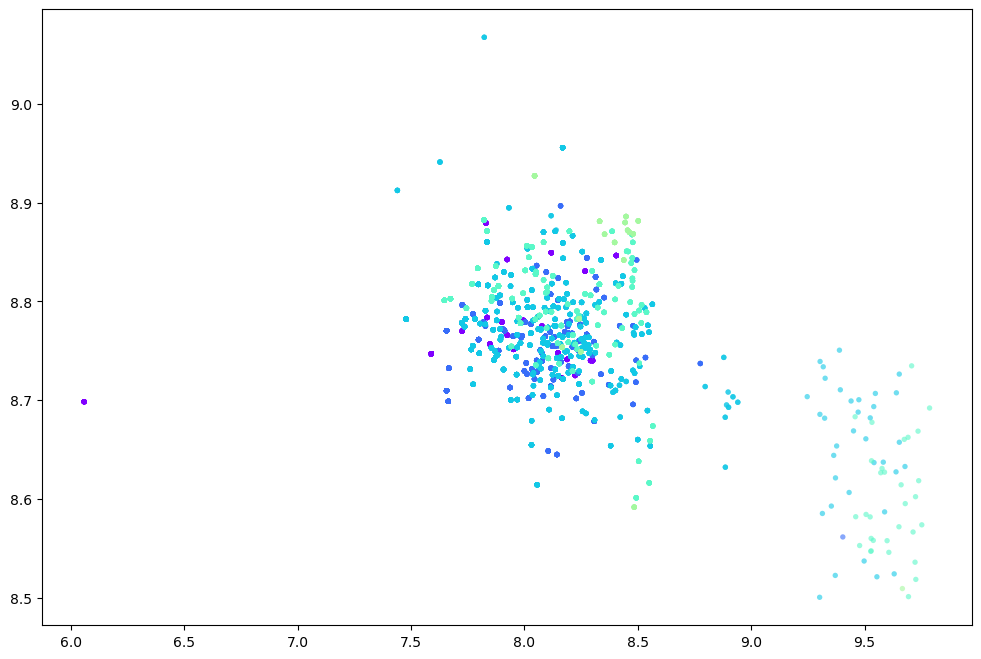

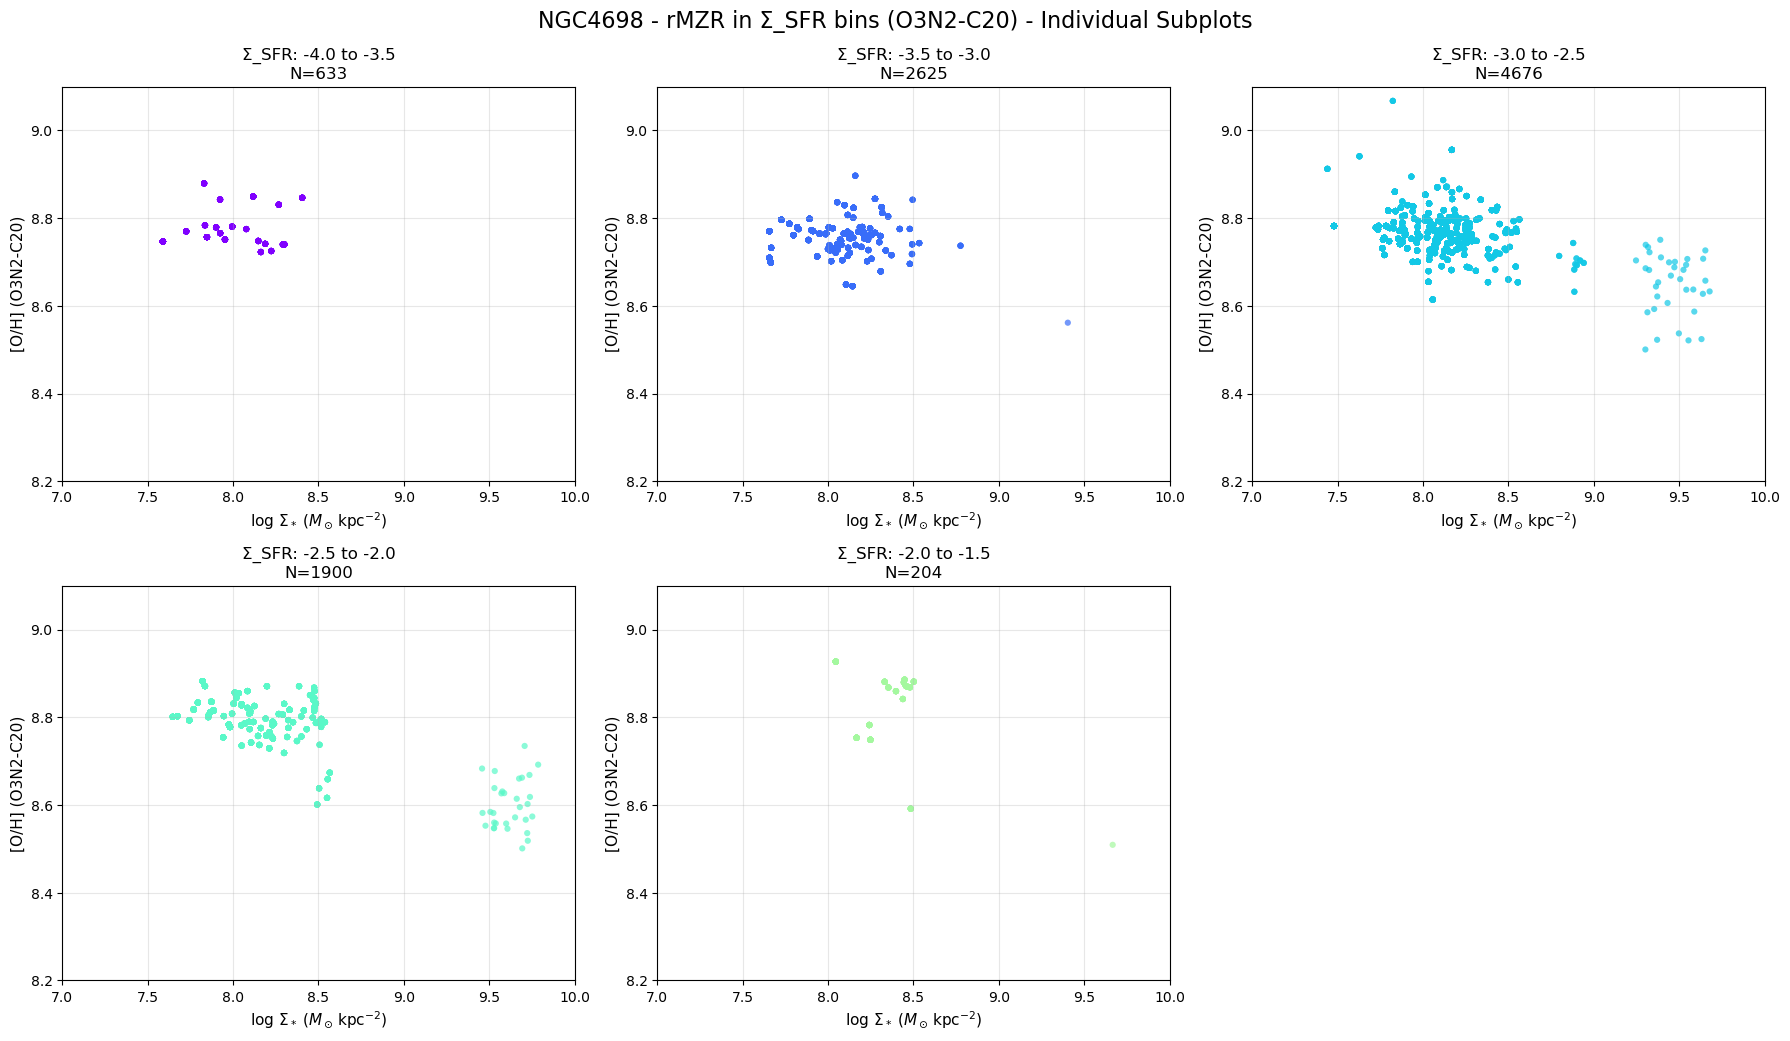

<Figure size 640x480 with 0 Axes>


Analysis complete for NGC4698 rMZR behavior in Σ_SFR bins with individual subplots (O3N2-C20 only)


In [13]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins (O3N2-C20 only) - Individual subplots
# Σ_SFR bins: -4 to 1 with 0.5 bin width, each bin in separate subplot
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps(gal):
    """Load stellar mass surface density, SFR surface density, and O3N2-C20 metallicity maps"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
    return sigM, sigSFR_HII, oh_o3n2_c20

# Focus on NGC4698 only - O3N2-C20 metallicity
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load maps
    logSigmaM, logSigmaSFR, oh_o3n2_c20 = load_maps(gal)

    # Mask bad pixels
    good = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2_c20) & np.isfinite(logSigmaSFR)
    
    logSigmaSFR_good = logSigmaSFR[good]
    oh_o3n2_c20_good = oh_o3n2_c20[good]
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)  # Creates bins: [-4, -3.5], [-3.5, -3], etc.
    sfr_bin_centers = sfr_bin_edges[:-1] + 0.25  # Center of each bin
    n_bins = len(sfr_bin_centers)
    
    print(f"Σ_SFR bins: {sfr_bin_edges}")
    print(f"Bin centers: {sfr_bin_centers}")
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with subplots (3x3 grid to accommodate up to 9 bins)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    # Also create combined plot
    fig_combined, ax_combined = plt.subplots(figsize=(12, 8))
    
    valid_bins = 0  # Counter for valid bins
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select pixels in this Σ_SFR bin
        in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
        n_pixels = np.sum(in_bin)
        
        if n_pixels < 10:  # Skip bins with too few pixels
            print(f"Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
            continue
            
        # Get data for this bin
        x_bin = logSigmaM[good][in_bin]
        y_bin = oh_o3n2_c20_good[in_bin]
        
        # Plot in individual subplot
        if valid_bins < len(axes):
            ax = axes[valid_bins]
            ax.scatter(x_bin, y_bin, c=colors[i], s=20, alpha=0.7, edgecolors='none')
            
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
            ax.set_ylabel(r'[O/H] (O3N2-C20)', fontsize=11)
            ax.set_title(f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f}\nN={n_pixels}', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(7, 10)
            ax.set_ylim(8.2, 9.1)
        
        # Add to combined plot
        ax_combined.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                          label=f'Σ_SFR: {bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                          edgecolors='none')
        
        print(f"Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
        valid_bins += 1
    
    # Hide unused subplots
    for j in range(valid_bins, len(axes)):
        axes[j].set_visible(False)
    
    # Format subplot figure
    plt.figure(fig.number)
    plt.suptitle(f'{gal} - rMZR in Σ_SFR bins (O3N2-C20) - Individual Subplots', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()
    
    # Format combined plot
    plt.figure(fig_combined.number)
    ax_combined.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax_combined.set_ylabel(r'[O/H] (O3N2-C20)', fontsize=14)
    ax_combined.set_title(f'{gal} - rMZR in different Σ_SFR bins (O3N2-C20) - Combined', fontsize=16)
    ax_combined.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_combined.grid(True, alpha=0.3)
    ax_combined.set_xlim(7, 10)
    ax_combined.set_ylim(8.2, 9.1)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nAnalysis complete for {gal} rMZR behavior in Σ_SFR bins with individual subplots (O3N2-C20 only)")

Total pixels: 722912
Common valid pixels across all calibrations: 10042

Processing D16 calibration:
  Bin -4.0 to -3.5: N=558 pixels
  Bin -3.5 to -3.0: N=2604 pixels
  Bin -3.0 to -2.5: N=4633 pixels
  Bin -2.5 to -2.0: N=1900 pixels
  Bin -2.0 to -1.5: N=204 pixels
  Bin -1.5 to -1.0: only 0 pixels, skipping
  Bin -1.0 to -0.5: only 0 pixels, skipping
  Bin -0.5 to 0.0: only 0 pixels, skipping
  Total valid bins for D16: 5

Processing PG16 calibration:
  Bin -4.0 to -3.5: N=558 pixels
  Bin -3.5 to -3.0: N=2604 pixels
  Bin -3.0 to -2.5: N=4633 pixels
  Bin -2.5 to -2.0: N=1900 pixels
  Bin -2.0 to -1.5: N=204 pixels
  Bin -1.5 to -1.0: only 0 pixels, skipping
  Bin -1.0 to -0.5: only 0 pixels, skipping
  Bin -0.5 to 0.0: only 0 pixels, skipping
  Total valid bins for PG16: 5

Processing O3N2-M13 calibration:
  Bin -4.0 to -3.5: N=558 pixels
  Bin -3.5 to -3.0: N=2604 pixels
  Bin -3.0 to -2.5: N=4633 pixels
  Bin -2.5 to -2.0: N=1900 pixels
  Bin -2.0 to -1.5: N=204 pixels
  Bin -1

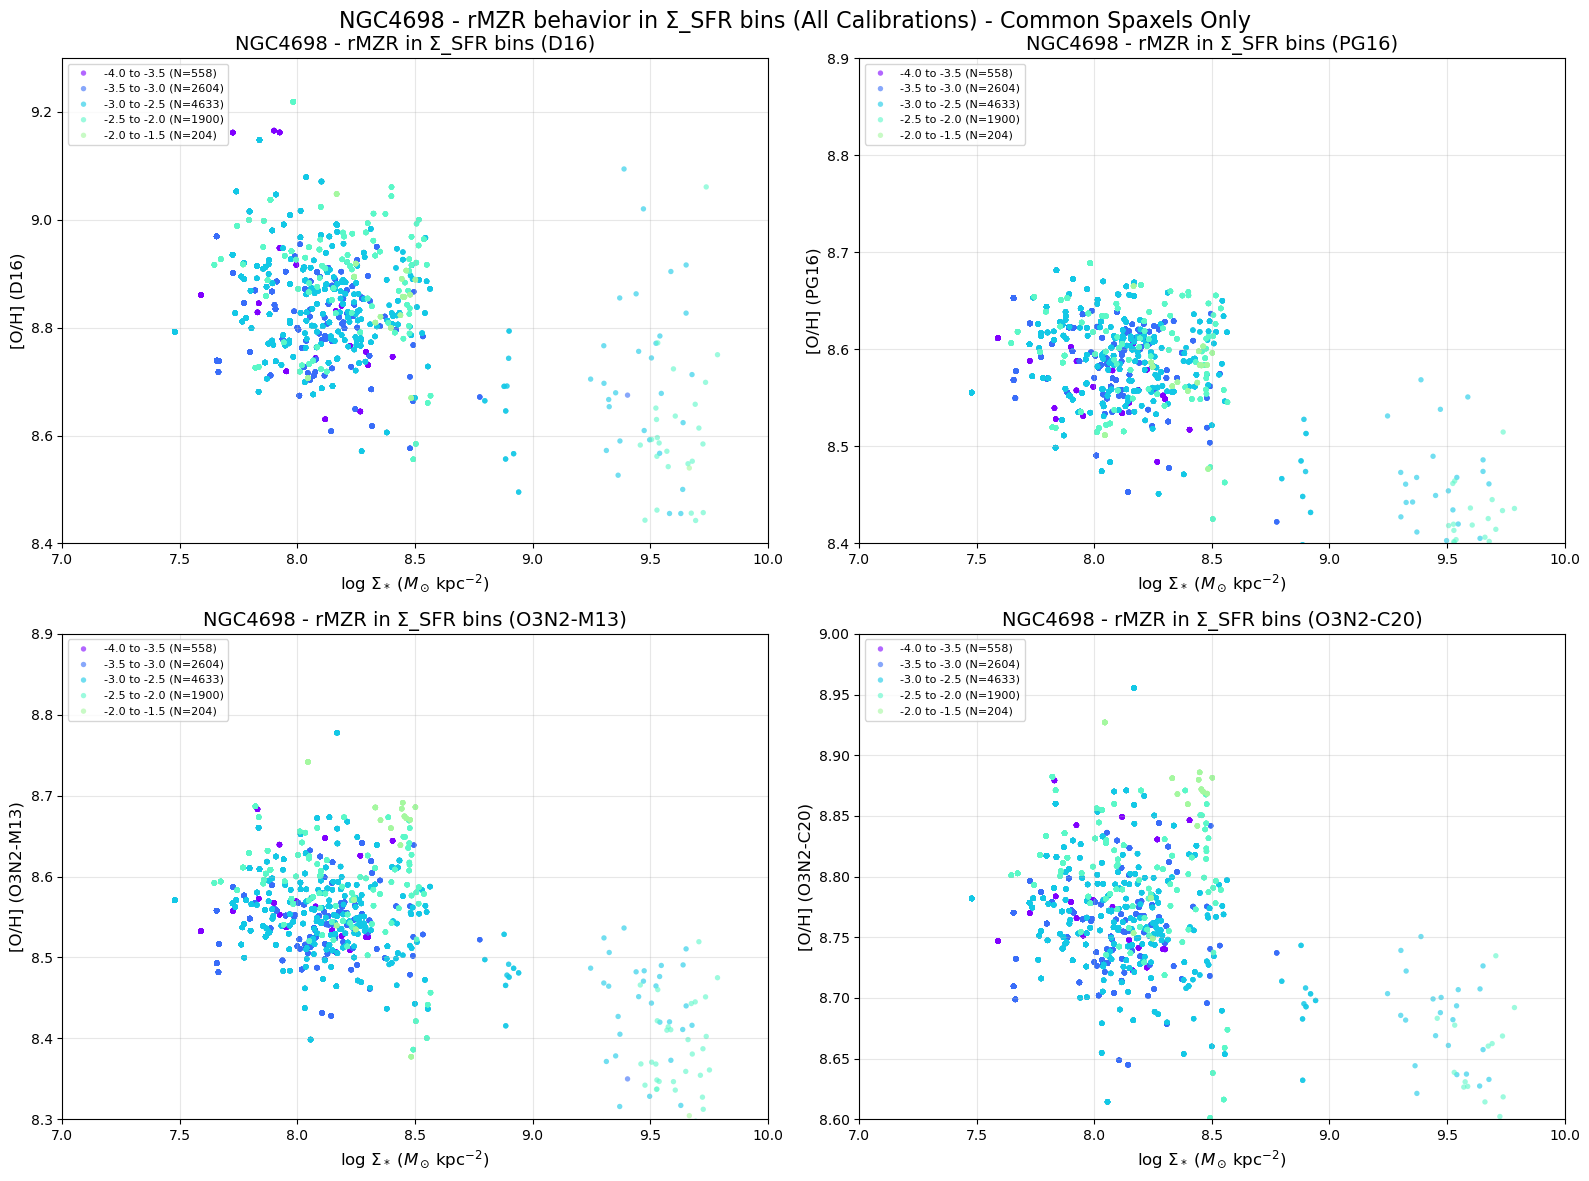


Successfully created combined 2x2 subplot figure showing rMZR behavior in Σ_SFR bins for all 4 metallicity calibrations using common spaxels


In [14]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - All 4 calibrations in single figure
# 2x2 subplots showing combined plots for each metallicity calibration
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for a galaxy"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
    return sigM, sigSFR_HII, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data
    logSigmaM, logSigmaSFR, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20 = load_maps_all_calibrations(gal)
    
    # Find common spaxels across ALL metallicity calibrations and other required data
    common_mask = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR) & 
                   np.isfinite(oh_d16) & np.isfinite(oh_pg16) & 
                   np.isfinite(oh_o3n2_m13) & np.isfinite(oh_o3n2_c20))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Data for each calibration
    calibrations = [
        (oh_d16, 'D16', (8.4, 9.3), axes[0]),
        (oh_pg16, 'PG16', (8.4, 8.9), axes[1]),
        (oh_o3n2_m13, 'O3N2-M13', (8.3, 8.9), axes[2]),
        (oh_o3n2_c20, 'O3N2-C20', (8.6, 9.0), axes[3])
    ]
    
    # Process each calibration
    for calib_idx, (oh_data, calib_name, ylim, ax) in enumerate(calibrations):
        print(f"\nProcessing {calib_name} calibration:")
        
        # Use common mask for all calibrations
        logSigmaSFR_good = logSigmaSFR[common_mask]
        logSigmaM_good = logSigmaM[common_mask]
        oh_good = oh_data[common_mask]
        
        # Plot each Σ_SFR bin
        valid_bins = 0
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # Select pixels in this Σ_SFR bin
            in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
            n_pixels = np.sum(in_bin)
            
            if n_pixels < 10:  # Skip bins with too few pixels
                print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
                continue
                
            # Get data for this bin
            x_bin = logSigmaM_good[in_bin]
            y_bin = oh_good[in_bin]
            
            # Add to plot
            ax.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                      label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                      edgecolors='none')
            
            print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
            valid_bins += 1
        
        # Format this subplot
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax.set_title(f'{gal} - rMZR in Σ_SFR bins ({calib_name})', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(7, 10)
        ax.set_ylim(ylim)
        
        # Add legend (smaller font to fit)
        ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        print(f"  Total valid bins for {calib_name}: {valid_bins}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins (All Calibrations) - Common Spaxels Only', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 2x2 subplot figure showing rMZR behavior in Σ_SFR bins for all 4 metallicity calibrations using common spaxels")

SFR bin edges: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5]
Number of bins: 7

SFR bin information for NGC4698:
  Bin 0: -4.0 to -3.5 - 633 pixels
  Bin 1: -3.5 to -3.0 - 2625 pixels
  Bin 2: -3.0 to -2.5 - 4676 pixels
  Bin 3: -2.5 to -2.0 - 1900 pixels
  Bin 4: -2.0 to -1.5 - 204 pixels
  Bin 5: -1.5 to -1.0 - 0 pixels
  Bin 6: -1.0 to -0.5 - 0 pixels


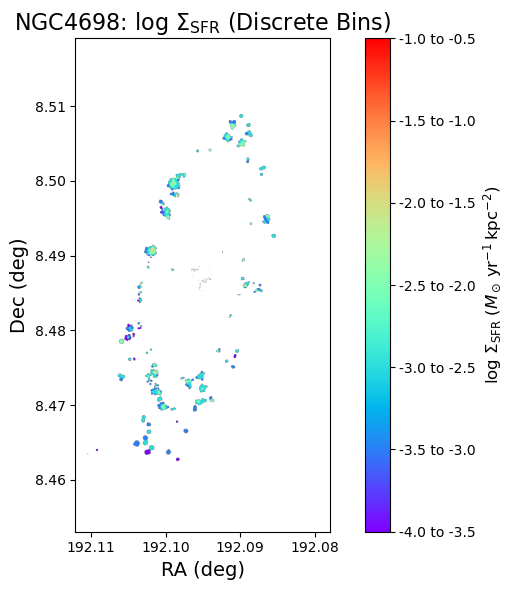

In [15]:
# ------------------------------------------------------------------
# 0.  List galaxies and pin one colour to each
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = ['NGC4698']        # auto-detect
cmap   = plt.get_cmap('tab20').colors                      # 20 hues
colour = {g: cmap[i % len(cmap)] for i, g in enumerate(galaxies)}

# ------------------------------------------------------------------
# 1.  Helper: read the two maps
# ------------------------------------------------------------------
def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
        mass_header = h['LOGMASS_SURFACE_DENSITY'].header
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR = h['LOGSFR_SURFACE_DENSITY_HII'].data
        gas_header = h['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, wcs, mass_header, gas_header

# Update the code to show only the middle panel (SFR map) with discrete bins
for gal in galaxies:
    sigM, sigSFR, wcs, mass_header, gas_header = load_maps(gal)
    good = np.isfinite(sigM) & np.isfinite(sigSFR)

    # Convert pixel area to physical area in pc²
    legacy_wcs2 = WCS(gas_header).celestial  # strip spectral axis
    
    # Get the extent from WCS for proper coordinate axes
    y_size, x_size = sigM.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    # Convert pixel coordinates to world coordinates
    ra, dec = legacy_wcs2.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]  # [left, right, bottom, top]

    # Define discrete SFR bins: -4 to -0.5 with 0.5 bin width (7 bins)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    print(f"SFR bin edges: {sfr_bin_edges}")
    print(f"Number of bins: {n_bins}")
    
    # Create discrete SFR map based on bins
    sfr_discrete = np.full_like(sigSFR, np.nan)
    
    # Assign each pixel to its corresponding bin
    for i in range(n_bins):
        bin_mask = (sigSFR >= sfr_bin_edges[i]) & (sigSFR < sfr_bin_edges[i+1])
        sfr_discrete[bin_mask] = i  # Assign bin index
    
    # Handle the last bin edge (include pixels exactly at -0.5)
    last_bin_mask = sigSFR >= sfr_bin_edges[-1]
    sfr_discrete[last_bin_mask] = n_bins - 1

    fig = plt.figure(figsize=(10, 6))

    # --- Discrete Σ_SFR map -----------------------------------------------
    ax = fig.add_subplot(1, 1, 1)
    
    # Use rainbow colormap for discrete bins
    cmap_rainbow = plt.cm.rainbow
    
    im = ax.imshow(sfr_discrete, origin='lower', cmap=cmap_rainbow, 
                   extent=extent, vmin=0, vmax=n_bins-1)
    ax.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (Discrete Bins)', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    
    # Ensure RA axis increases from left to right
    # ax.invert_xaxis()
    
    # Create custom colorbar with discrete bins and labels
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Set discrete ticks and labels for the colorbar
    tick_positions = np.arange(n_bins)
    tick_labels = [f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}' for i in range(n_bins)]
    cbar.set_ticks(tick_positions)
    cbar.set_ticklabels(tick_labels)
    
    # Print bin information
    print(f"\nSFR bin information for {gal}:")
    for i in range(n_bins):
        bin_mask = sfr_discrete == i
        n_pixels = np.sum(bin_mask)
        print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_discrete_SFR_map_bins.png', dpi=600)
    # plt.savefig(f'{gal}_discrete_SFR_map_bins.pdf')
    plt.show()

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17443/1180844613.py:35: RuntimeWarning: Mean of empty slice
  oh_combined_c20 = np.nanmean([oh_o3n2_c20, oh_RS32_c20, oh_r3_c20, oh_n2_c20], axis=0)


Total pixels: 722912
Common valid pixels across all calibrations: 8516

Processing D16 calibration:
  Bin -4.0 to -3.5: N=470 pixels
  Bin -3.5 to -3.0: N=1925 pixels
  Bin -3.0 to -2.5: N=4049 pixels
  Bin -2.5 to -2.0: N=1743 pixels
  Bin -2.0 to -1.5: N=186 pixels
  Bin -1.5 to -1.0: only 0 pixels, skipping
  Bin -1.0 to -0.5: only 0 pixels, skipping
  Bin -0.5 to 0.0: only 0 pixels, skipping
  Total valid bins for D16: 5

Processing PG16 calibration:
  Bin -4.0 to -3.5: N=470 pixels
  Bin -3.5 to -3.0: N=1925 pixels
  Bin -3.0 to -2.5: N=4049 pixels
  Bin -2.5 to -2.0: N=1743 pixels
  Bin -2.0 to -1.5: N=186 pixels
  Bin -1.5 to -1.0: only 0 pixels, skipping
  Bin -1.0 to -0.5: only 0 pixels, skipping
  Bin -0.5 to 0.0: only 0 pixels, skipping
  Total valid bins for PG16: 5

Processing O3N2-M13 calibration:
  Bin -4.0 to -3.5: N=470 pixels
  Bin -3.5 to -3.0: N=1925 pixels
  Bin -3.0 to -2.5: N=4049 pixels
  Bin -2.5 to -2.0: N=1743 pixels
  Bin -2.0 to -1.5: N=186 pixels
  Bin -1.

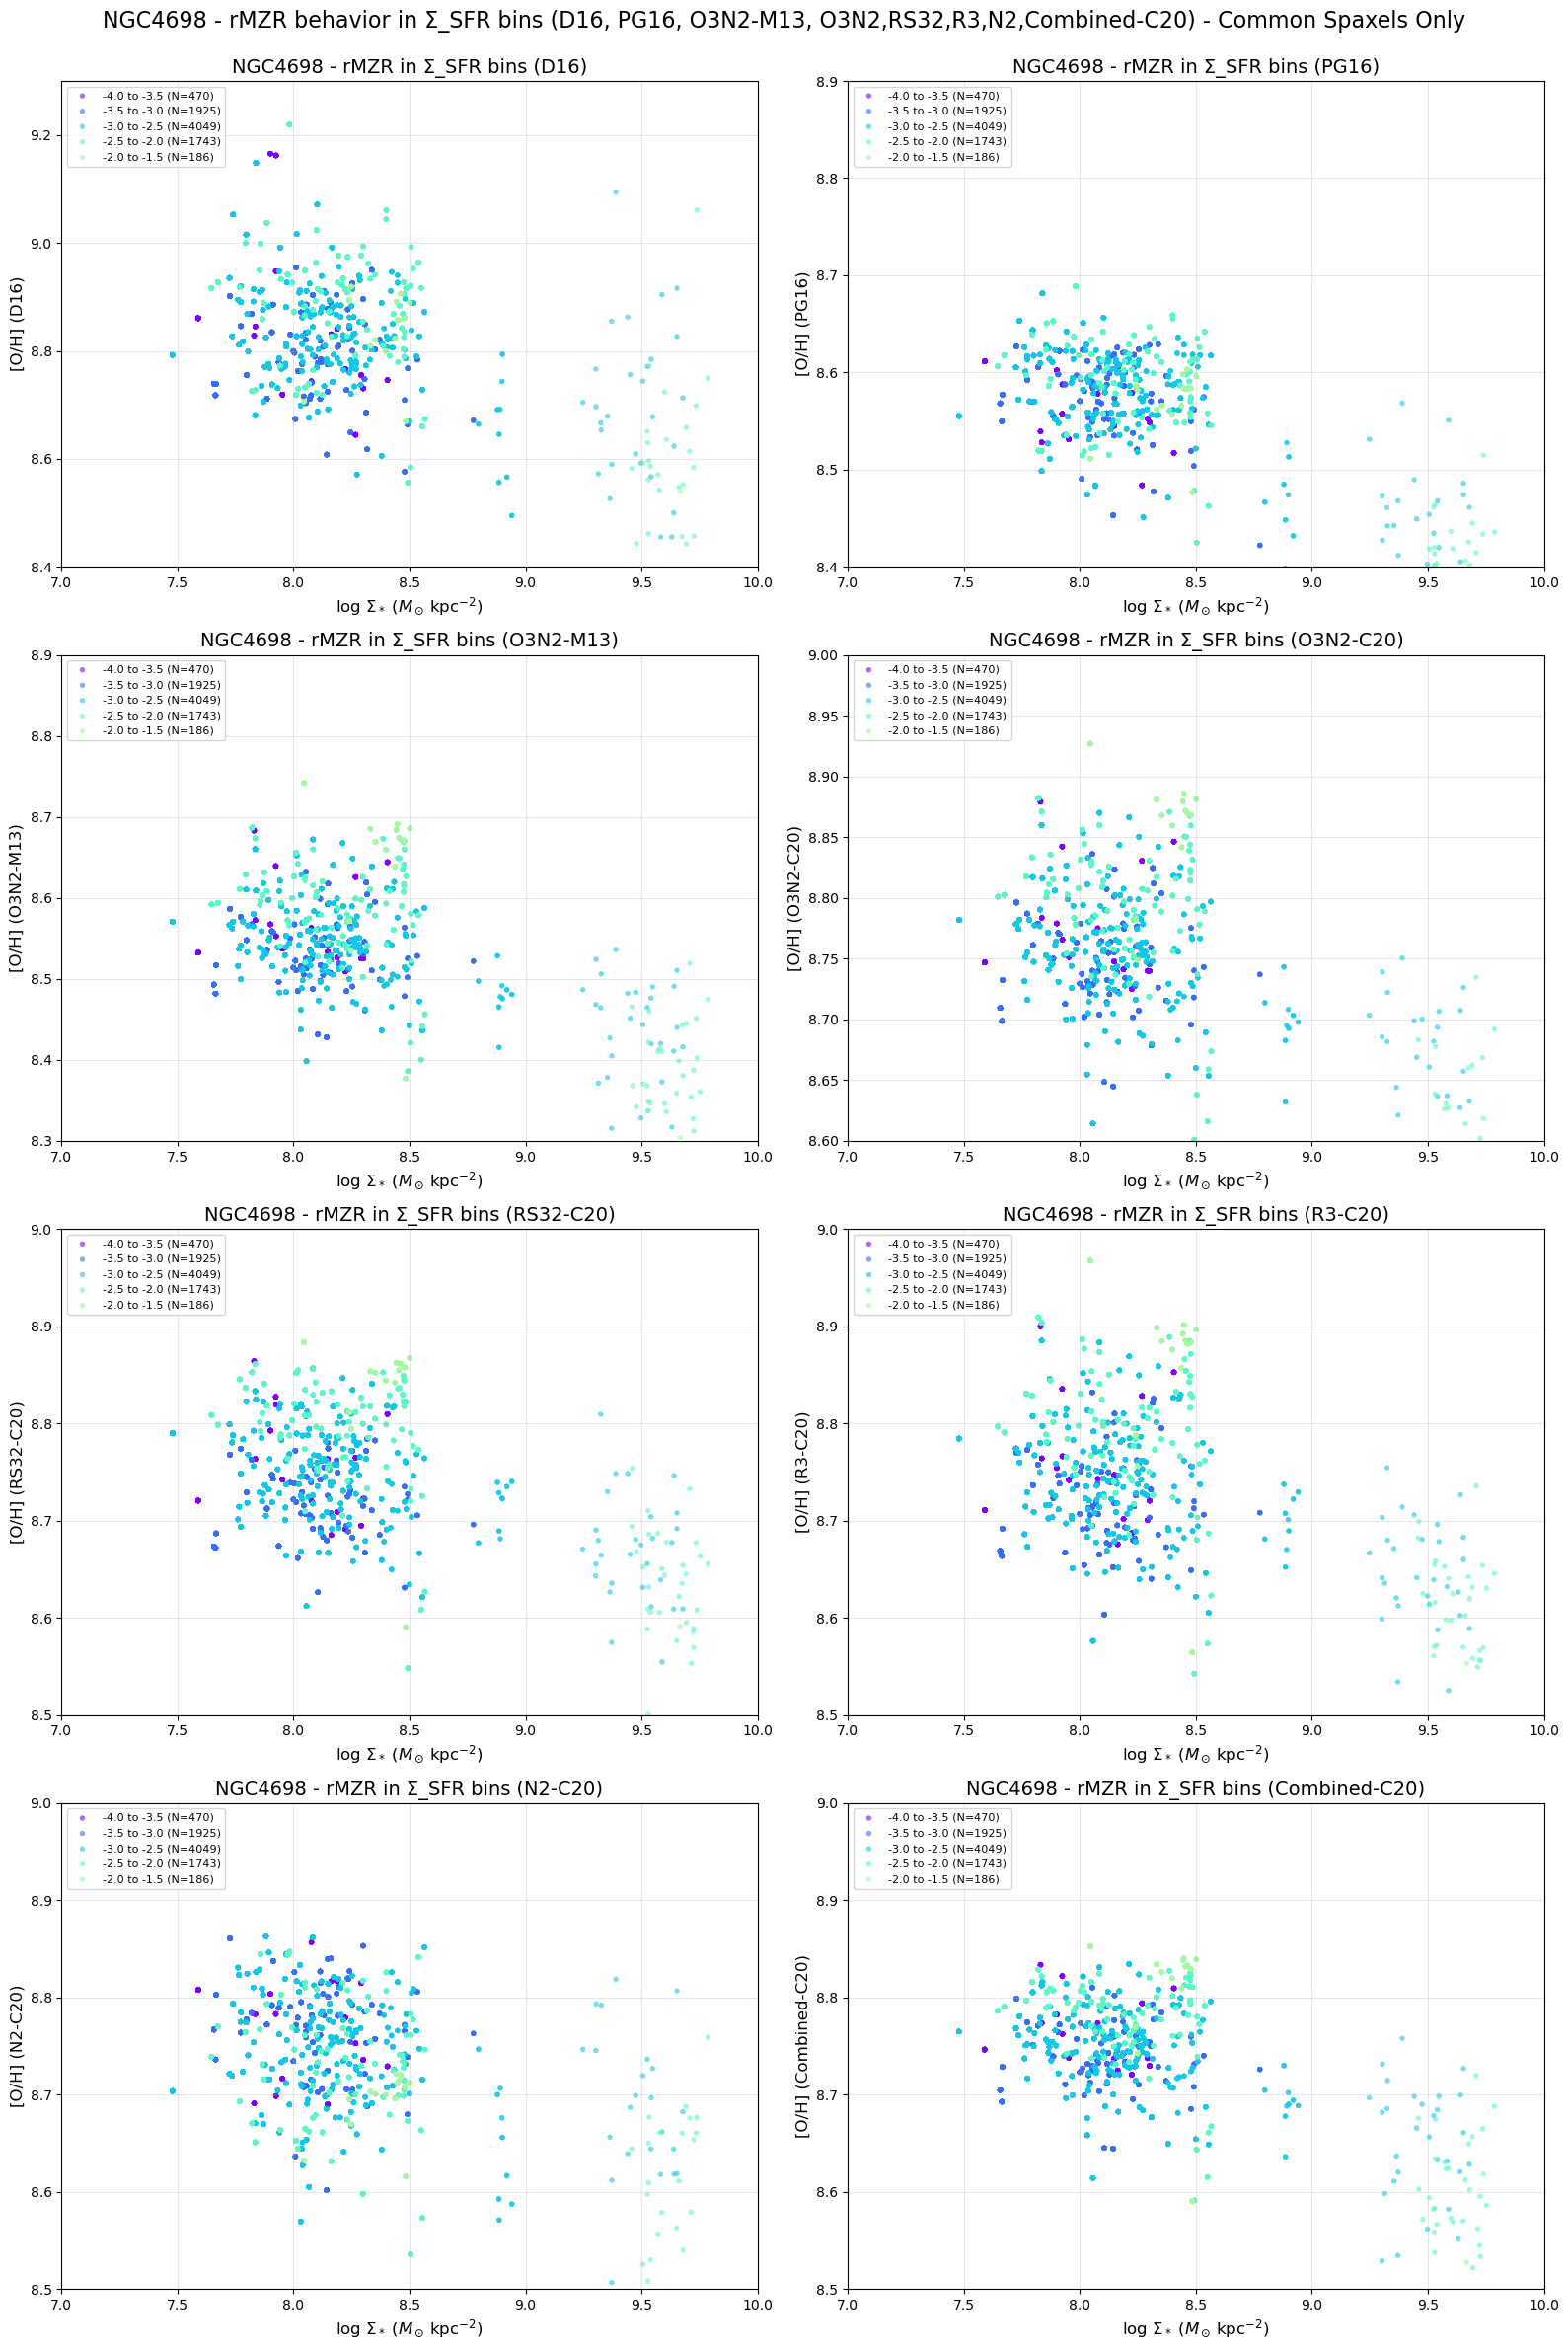


Successfully created extended 4x2 subplot figure showing rMZR behavior in Σ_SFR bins for all D16, PG16, O3N2-M13, O3N2,RS32,R3,N2,Combined-C20 metallicity calibrations using common spaxels


In [16]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - All calibrations + N2-C20 + Combined
# 4x2 subplots showing all metallicity calibrations plus N2-C20 and Combined-C20
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps_all_calibrations_extended(gal):
    """Load all metallicity calibrations for a galaxy including N2-C20"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
        oh_RS32_c20 = h['O_H_RS32_C20_HII'].data
        oh_r3_c20 = h['O_H_R3_C20_HII'].data
        oh_n2_c20 = h['O_H_N2_C20_HII'].data  # Add N2-C20
    return sigM, sigSFR_HII, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20, oh_RS32_c20, oh_r3_c20, oh_n2_c20

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data including N2-C20
    logSigmaM, logSigmaSFR, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20, oh_RS32_c20, oh_r3_c20, oh_n2_c20 = load_maps_all_calibrations_extended(gal)
    
    # Create combined C20 metallicity (average of C20 calibrations)
    oh_combined_c20 = np.nanmean([oh_o3n2_c20, oh_RS32_c20, oh_r3_c20, oh_n2_c20], axis=0)
    
    # Find common spaxels across ALL metallicity calibrations and other required data
    common_mask = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR) & 
                   np.isfinite(oh_d16) & np.isfinite(oh_pg16) & 
                   np.isfinite(oh_o3n2_m13) & np.isfinite(oh_o3n2_c20) &
                   np.isfinite(oh_RS32_c20) & np.isfinite(oh_r3_c20) & 
                   np.isfinite(oh_n2_c20) & np.isfinite(oh_combined_c20))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    
    # Define Σ_SFR bins: -4 to 1 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.5, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with 4x2 subplots
    fig, axes = plt.subplots(4, 2, figsize=(16, 24))
    axes = axes.flatten()
    
    # Data for each calibration
    calibrations = [
        (oh_d16, 'D16', (8.4, 9.3), axes[0]),
        (oh_pg16, 'PG16', (8.4, 8.9), axes[1]),
        (oh_o3n2_m13, 'O3N2-M13', (8.3, 8.9), axes[2]),
        (oh_o3n2_c20, 'O3N2-C20', (8.6, 9.0), axes[3]),
        (oh_RS32_c20, 'RS32-C20', (8.5, 9.0), axes[4]),
        (oh_r3_c20, 'R3-C20', (8.5, 9.0), axes[5]),
        (oh_n2_c20, 'N2-C20', (8.5, 9.0), axes[6]),
        (oh_combined_c20, 'Combined-C20', (8.5, 9.0), axes[7])
    ]
    
    # Process each calibration
    for calib_idx, (oh_data, calib_name, ylim, ax) in enumerate(calibrations):
        print(f"\nProcessing {calib_name} calibration:")
        
        # Use common mask for all calibrations
        logSigmaSFR_good = logSigmaSFR[common_mask]
        logSigmaM_good = logSigmaM[common_mask]
        oh_good = oh_data[common_mask]
        
        # Plot each Σ_SFR bin
        valid_bins = 0
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # Select pixels in this Σ_SFR bin
            in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
            n_pixels = np.sum(in_bin)
            
            if n_pixels < 10:  # Skip bins with too few pixels
                print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
                continue
                
            # Get data for this bin
            x_bin = logSigmaM_good[in_bin]
            y_bin = oh_good[in_bin]
            
            # Add to plot
            ax.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                      label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                      edgecolors='none')
            
            print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels")
            valid_bins += 1
        
        # Format this subplot
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax.set_title(f'{gal} - rMZR in Σ_SFR bins ({calib_name})', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(7, 10)
        ax.set_ylim(ylim)
        
        # Add legend (smaller font to fit)
        ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        print(f"  Total valid bins for {calib_name}: {valid_bins}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins (D16, PG16, O3N2-M13, O3N2,RS32,R3,N2,Combined-C20) - Common Spaxels Only', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)  # Make room for suptitle
    # plt.savefig(f'{gal}_rMZR_SigmaSFR_bins_8_calibrations_extended.png', dpi=300)
    # plt.savefig(f'{gal}_rMZR_SigmaSFR_bins_8_calibrations_extended.pdf')
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created extended 4x2 subplot figure showing rMZR behavior in Σ_SFR bins for all D16, PG16, O3N2-M13, O3N2,RS32,R3,N2,Combined-C20 metallicity calibrations using common spaxels")

Total pixels: 722912
Common valid pixels across all calibrations: 10042

Processing D16 calibration:
  Bin -4.0 to -3.5: N=558 pixels, 4 mass bins (min 50 per bin)
    Mass bin 7.7: median=8.860, std=0.109, N=176
    Mass bin 7.9: median=8.845, std=0.185, N=139
    Mass bin 8.1: median=8.803, std=0.101, N=136
    Mass bin 8.3: median=8.731, std=0.049, N=84
  Bin -3.5 to -3.0: N=2604 pixels, 5 mass bins (min 50 per bin)
    Mass bin 7.8: median=8.846, std=0.094, N=692
    Mass bin 8.0: median=8.830, std=0.075, N=776
    Mass bin 8.2: median=8.807, std=0.073, N=817
    Mass bin 8.4: median=8.821, std=0.090, N=262
    Mass bin 8.6: median=8.709, std=0.089, N=51
  Bin -3.0 to -2.5: N=4633 pixels, 6 mass bins (min 50 per bin)
    Mass bin 7.6: median=8.792, std=0.000, N=116
    Mass bin 7.8: median=8.899, std=0.109, N=1090
    Mass bin 8.0: median=8.864, std=0.097, N=1350
    Mass bin 8.2: median=8.844, std=0.087, N=1515
    Mass bin 8.4: median=8.822, std=0.078, N=356
    Mass bin 8.6: med

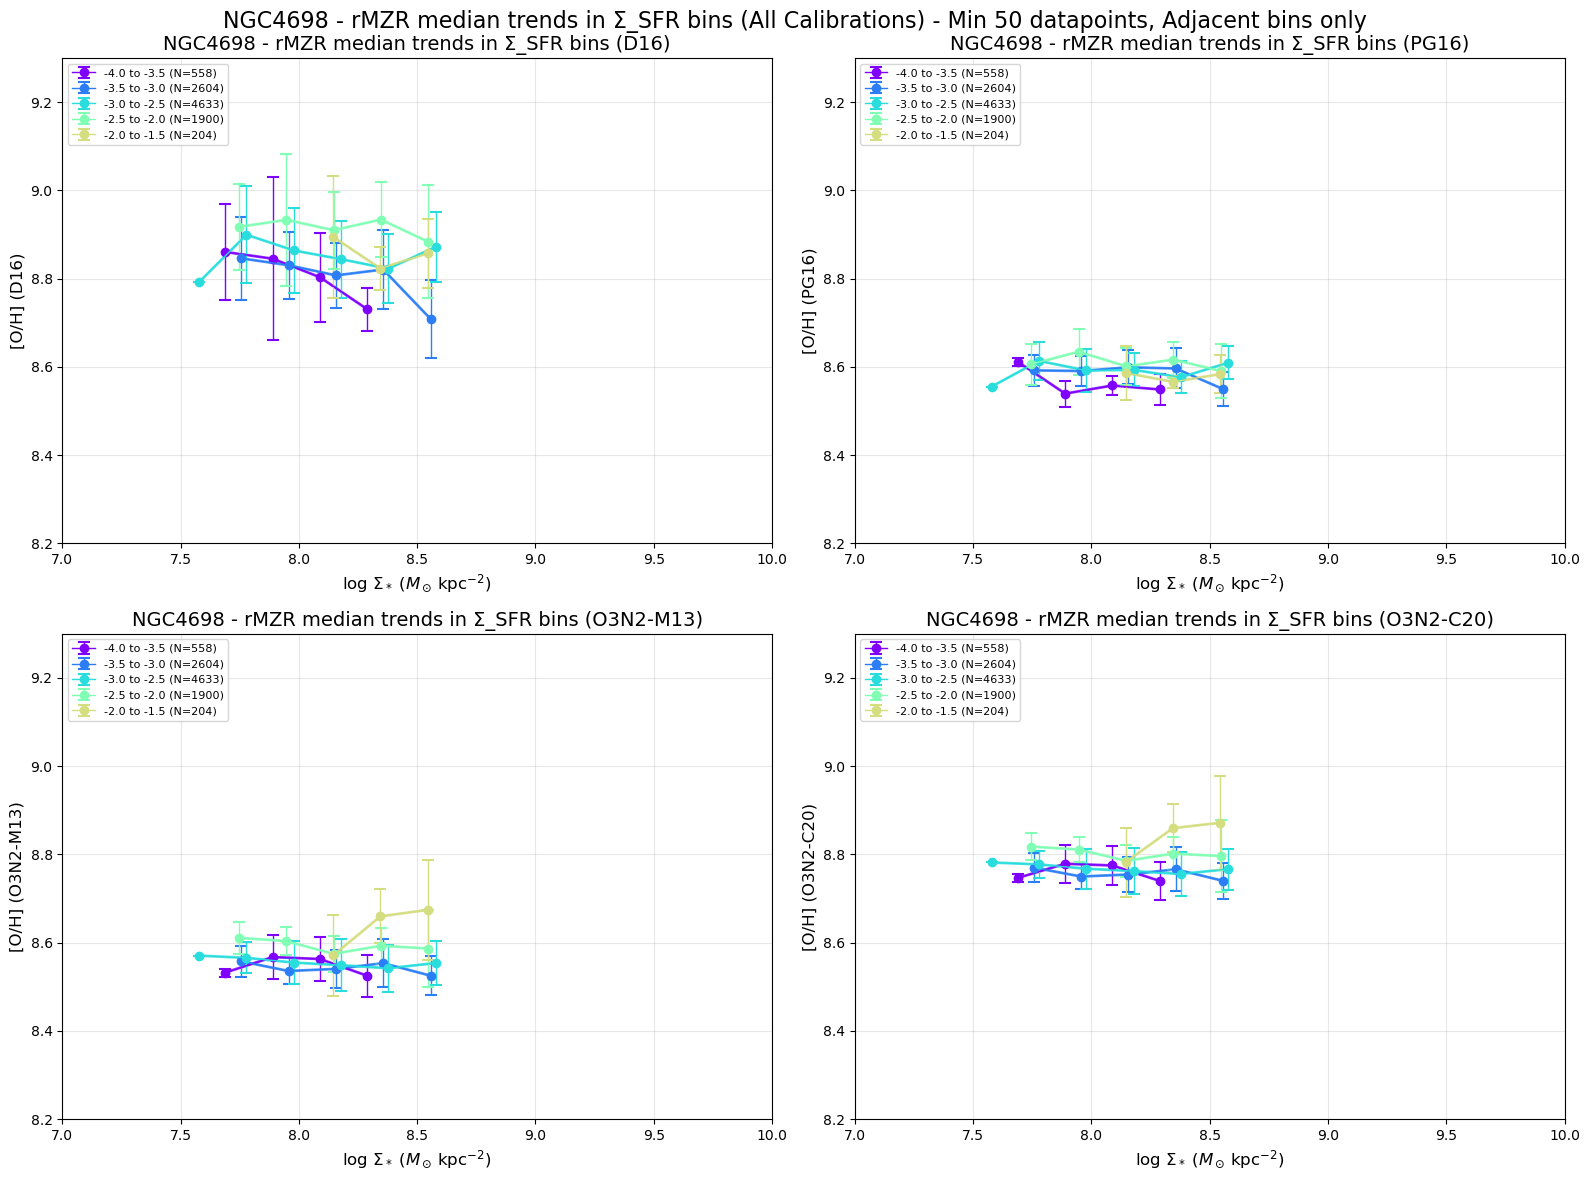


Successfully created combined 2x2 subplot figure showing rMZR median trends with adjacency check and min 50 datapoints per bin


In [17]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - All 4 calibrations with median trends
# 2x2 subplots showing median trends with std error bars for each metallicity calibration
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for a galaxy"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
    return sigM, sigSFR_HII, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.8)

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data
    logSigmaM, logSigmaSFR, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20 = load_maps_all_calibrations(gal)

    # Find common spaxels across ALL metallicity calibrations and other required data
    common_mask = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR) & 
                   np.isfinite(oh_d16) & np.isfinite(oh_pg16) & 
                   np.isfinite(oh_o3n2_m13) & np.isfinite(oh_o3n2_c20))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")

    # Define Σ_SFR bins: -4 to 0.0 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.0, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Create figure with 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Data for each calibration
    calibrations = [
        (oh_d16, 'D16', (8.2, 9.3), axes[0]),
        (oh_pg16, 'PG16', (8.2, 9.3), axes[1]),
        (oh_o3n2_m13, 'O3N2-M13', (8.2, 9.3), axes[2]),
        (oh_o3n2_c20, 'O3N2-C20', (8.2, 9.3), axes[3])
    ]
    
    # Process each calibration
    for calib_idx, (oh_data, calib_name, ylim, ax) in enumerate(calibrations):
        print(f"\nProcessing {calib_name} calibration:")
        
        # Use common mask for all calibrations
        logSigmaSFR_good = logSigmaSFR[common_mask]
        logSigmaM_good = logSigmaM[common_mask]
        oh_good = oh_data[common_mask]
        
        # Plot each Σ_SFR bin with median trends
        valid_bins = 0
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # Select pixels in this Σ_SFR bin
            in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
            n_pixels = np.sum(in_bin)
            
            if n_pixels < 10:  # Skip bins with too few pixels
                print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
                continue
                
            # Get data for this bin
            x_bin = logSigmaM_good[in_bin]
            y_bin = oh_good[in_bin]
            
            # Calculate binned statistics with 0.2 mass bin width and minimum 50 unique datapoints
            mass_centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats(
                x_bin, y_bin, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers) > 0:
                # Plot median trend with adjacency check for line connections
                plot_median_trend_with_adjacency(
                    ax, mass_centers, medians, stds, valid_bin_indices, colors[i],
                    f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels})')
                
                print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels, {len(mass_centers)} mass bins (min 50 per bin)")
                
                # Print mass bin details
                for j, (mc, med, std, cnt) in enumerate(zip(mass_centers, medians, stds, counts)):
                    print(f"    Mass bin {mc:.1f}: median={med:.3f}, std={std:.3f}, N={cnt}")
                
                valid_bins += 1
        
        # Format this subplot
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax.set_title(f'{gal} - rMZR median trends in Σ_SFR bins ({calib_name})', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(7, 10)
        ax.set_ylim(ylim)
        
        # Add legend (smaller font to fit)
        ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        print(f"  Total valid bins for {calib_name}: {valid_bins}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR median trends in Σ_SFR bins (All Calibrations) - Min 50 datapoints, Adjacent bins only', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 2x2 subplot figure showing rMZR median trends with adjacency check and min 50 datapoints per bin")

Total pixels: 722912
Common valid pixels across all calibrations: 10042
Using uniform y-axis range: 8.2 to 9.3

Processing D16 calibration:
  D16 range: 8.274 to 9.219
  Bin -4.0 to -3.5: N=558 pixels, 4 mass bins (min 50 per bin)
  Bin -3.5 to -3.0: N=2604 pixels, 5 mass bins (min 50 per bin)
  Bin -3.0 to -2.5: N=4633 pixels, 6 mass bins (min 50 per bin)
  Bin -2.5 to -2.0: N=1900 pixels, 5 mass bins (min 50 per bin)
  Bin -2.0 to -1.5: N=204 pixels, 3 mass bins (min 50 per bin)
  Bin -1.5 to -1.0: only 0 pixels, skipping
  Bin -1.0 to -0.5: only 0 pixels, skipping
  Total valid bins for D16: 5

Processing PG16 calibration:
  PG16 range: 7.645 to 8.689
  Bin -4.0 to -3.5: N=558 pixels, 4 mass bins (min 50 per bin)
  Bin -3.5 to -3.0: N=2604 pixels, 5 mass bins (min 50 per bin)
  Bin -3.0 to -2.5: N=4633 pixels, 6 mass bins (min 50 per bin)
  Bin -2.5 to -2.0: N=1900 pixels, 5 mass bins (min 50 per bin)
  Bin -2.0 to -1.5: N=204 pixels, 3 mass bins (min 50 per bin)
  Bin -1.5 to -1.0:

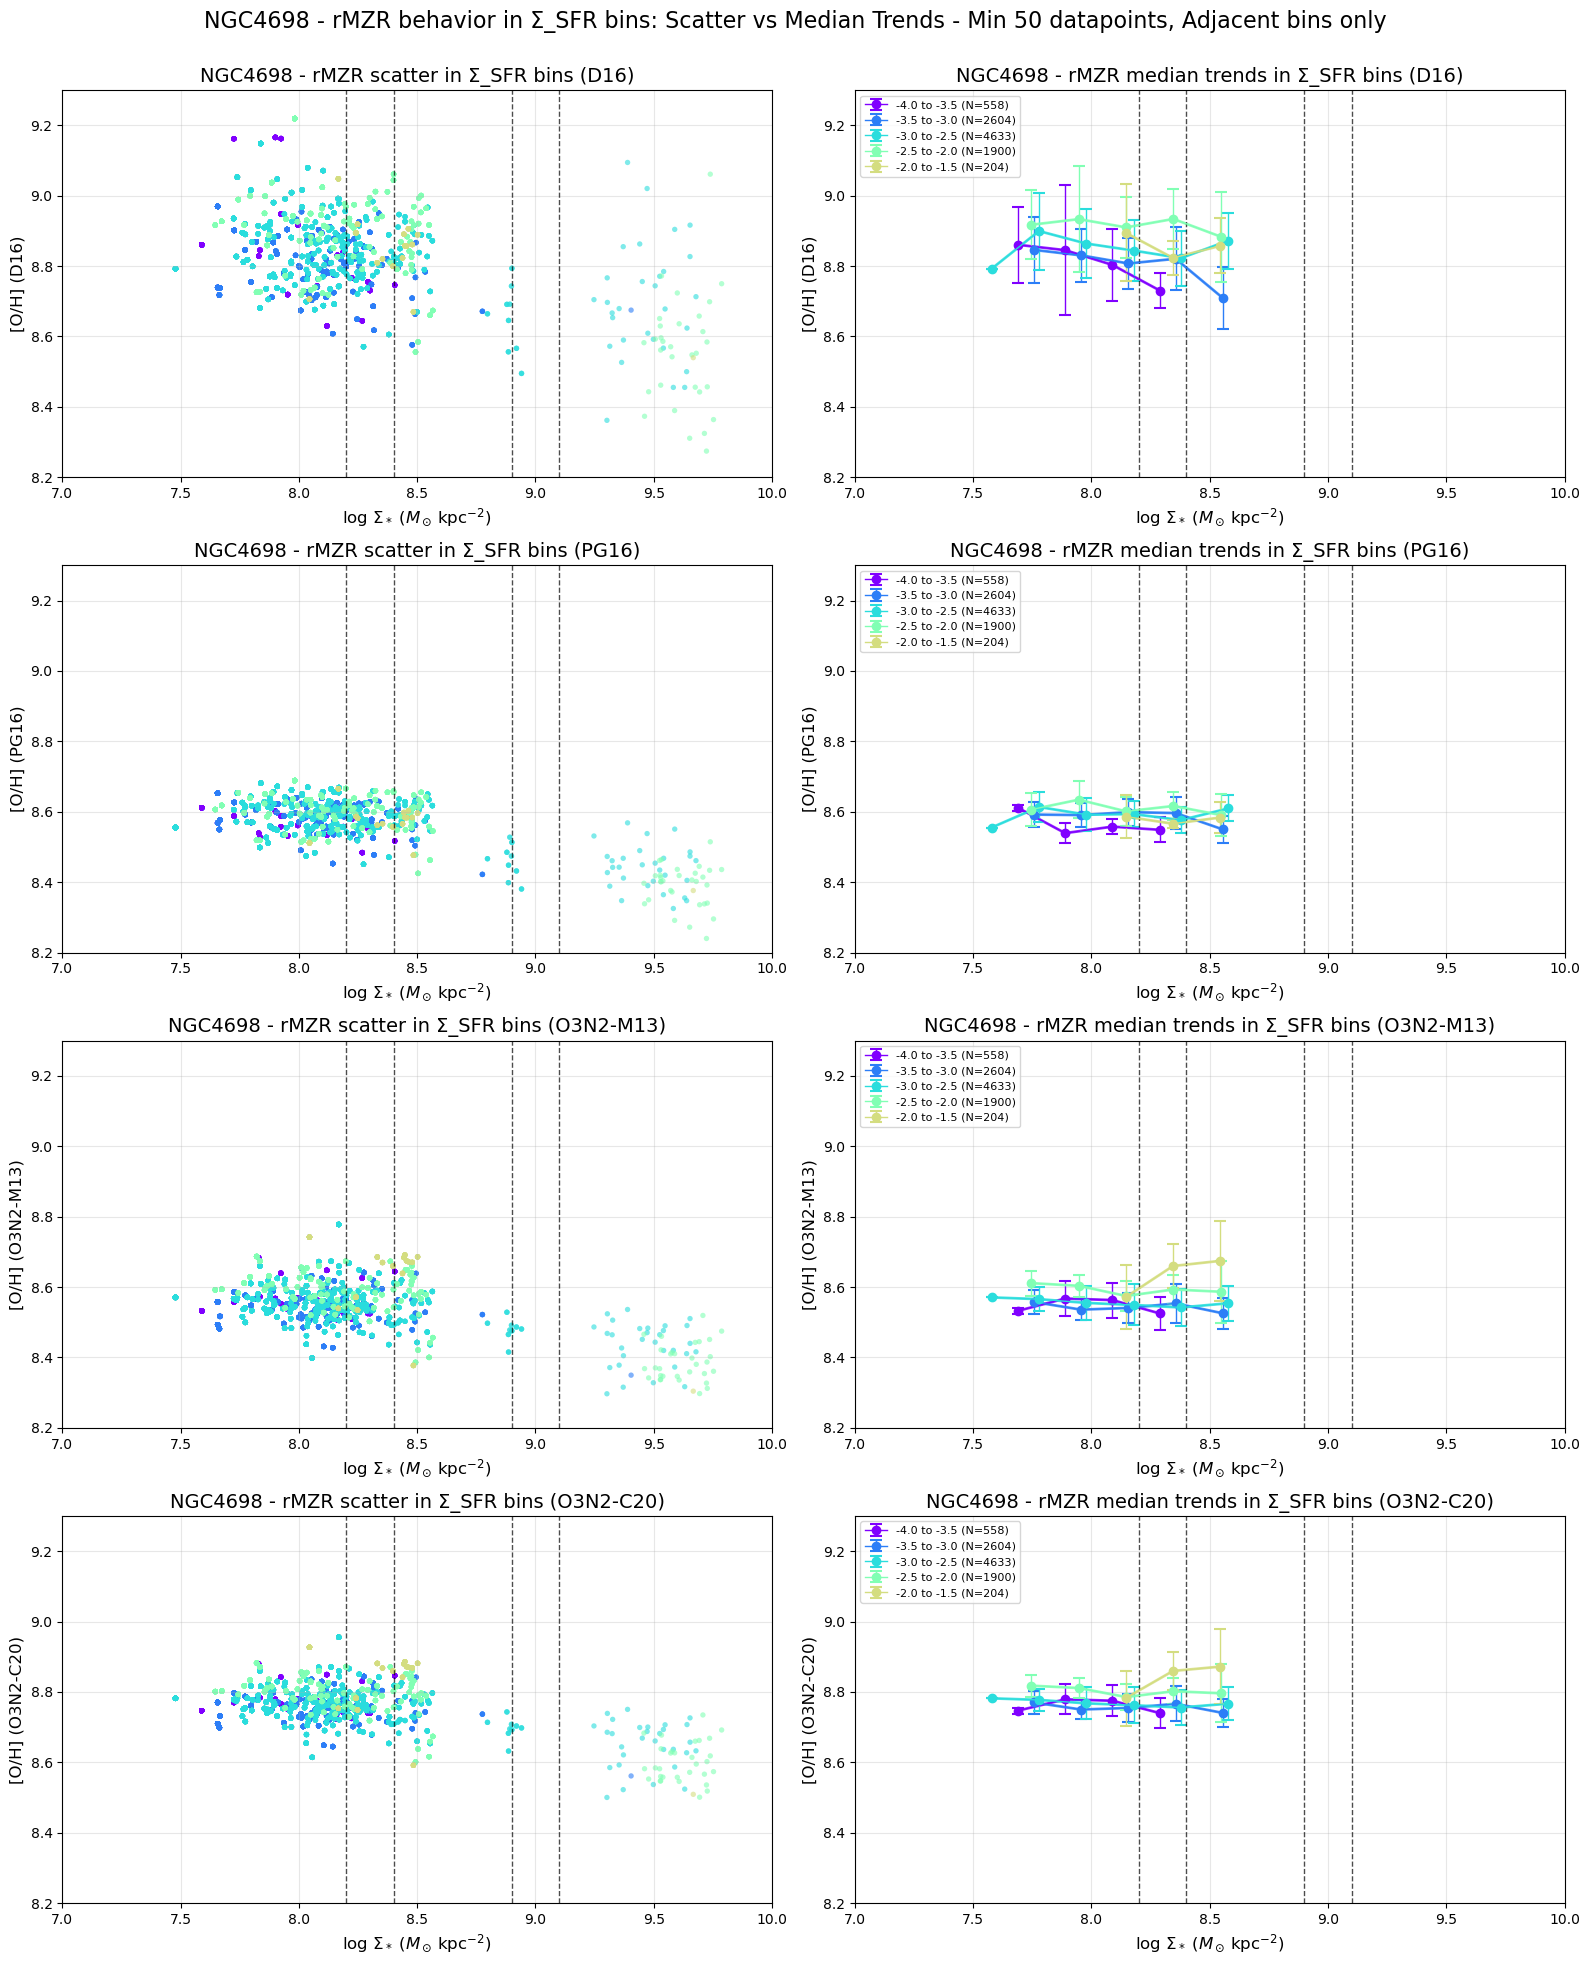


Successfully created combined 4x2 subplot figure showing both scatter plots and median trends for all 4 metallicity calibrations using common spaxels
Layout: Left column = scatter plots, Right column = median trends with error bars
Using uniform y-axis range: 8.2 to 9.3
Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins


In [18]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - Combined scatter plots and median trends
# 4 rows x 2 columns: LHS = scatter plots, RHS = median trends for each calibration
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for a galaxy"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16 = h['O_H_D16_HII'].data
        oh_pg16 = h['O_H_PG16_HII'].data
        oh_o3n2_m13 = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20 = h['O_H_O3N2_C20_HII'].data
    return sigM, sigSFR_HII, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.8)

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data
    logSigmaM, logSigmaSFR, oh_d16, oh_pg16, oh_o3n2_m13, oh_o3n2_c20 = load_maps_all_calibrations(gal)

    # Find common spaxels across ALL metallicity calibrations and other required data
    common_mask = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR) & 
                   np.isfinite(oh_d16) & np.isfinite(oh_pg16) & 
                   np.isfinite(oh_o3n2_m13) & np.isfinite(oh_o3n2_c20))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")

    # Define Σ_SFR bins: -4 to 0.0 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.0, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Set uniform y-axis range
    common_ylim = (8.2, 9.3)
    
    # Define vertical line positions
    vline_positions = [8.2, 8.4, 8.9, 9.1]
    
    print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
    
    # Create figure with 4 rows x 2 columns (scatter + median trends for each calibration)
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    
    # Data for each calibration
    calibrations = [
        (oh_d16, 'D16'),
        (oh_pg16, 'PG16'),
        (oh_o3n2_m13, 'O3N2-M13'),
        (oh_o3n2_c20, 'O3N2-C20')
    ]
    
    # Process each calibration (one row per calibration)
    for row_idx, (oh_data, calib_name) in enumerate(calibrations):
        print(f"\nProcessing {calib_name} calibration:")
        
        # Get axes for this row
        ax_scatter = axes[row_idx, 0]  # Left column: scatter plots
        ax_median = axes[row_idx, 1]   # Right column: median trends
        
        # Use common mask for all calibrations
        logSigmaSFR_good = logSigmaSFR[common_mask]
        logSigmaM_good = logSigmaM[common_mask]
        oh_good = oh_data[common_mask]
        
        print(f"  {calib_name} range: {np.min(oh_good):.3f} to {np.max(oh_good):.3f}")
        
        # Plot each Σ_SFR bin
        valid_bins = 0
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # Select pixels in this Σ_SFR bin
            in_bin = (logSigmaSFR_good >= bin_start) & (logSigmaSFR_good < bin_end)
            n_pixels = np.sum(in_bin)
            
            if n_pixels < 10:  # Skip bins with too few pixels
                print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: only {n_pixels} pixels, skipping")
                continue
                
            # Get data for this bin
            x_bin = logSigmaM_good[in_bin]
            y_bin = oh_good[in_bin]
            
            # Left plot: Scatter plot
            ax_scatter.scatter(x_bin, y_bin, c=[colors[i]], s=15, alpha=0.6, 
                             label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels})',
                             edgecolors='none')
            
            # Right plot: Median trends
            # Calculate binned statistics with 0.2 mass bin width and minimum 50 unique datapoints
            mass_centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats(
                x_bin, y_bin, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers) > 0:
                # Plot median trend with adjacency check for line connections
                plot_median_trend_with_adjacency(
                    ax_median, mass_centers, medians, stds, valid_bin_indices, colors[i],
                    f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels})')
                
                print(f"  Bin {bin_start:.1f} to {bin_end:.1f}: N={n_pixels} pixels, {len(mass_centers)} mass bins (min 50 per bin)")
                
                valid_bins += 1
        
        # Add vertical dashed lines to both scatter and median plots
        for vline_x in vline_positions:
            ax_scatter.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        
        # Format scatter plot (left column)
        ax_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax_scatter.set_title(f'{gal} - rMZR scatter in Σ_SFR bins ({calib_name})', fontsize=14)
        ax_scatter.grid(True, alpha=0.3)
        ax_scatter.set_xlim(7, 10)
        ax_scatter.set_ylim(common_ylim)
        # ax_scatter.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        # Format median trends plot (right column)
        ax_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
        ax_median.set_title(f'{gal} - rMZR median trends in Σ_SFR bins ({calib_name})', fontsize=14)
        ax_median.grid(True, alpha=0.3)
        ax_median.set_xlim(7, 10)
        ax_median.set_ylim(common_ylim)
        ax_median.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        print(f"  Total valid bins for {calib_name}: {valid_bins}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins: Scatter vs Median Trends - Min 50 datapoints, Adjacent bins only', 
                 fontsize=16, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 4x2 subplot figure showing both scatter plots and median trends for all 4 metallicity calibrations using common spaxels")
print(f"Layout: Left column = scatter plots, Right column = median trends with error bars")
print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
print(f"Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins")

## 20250922 8.0 to 8.5?
Notice that $\Sigma_*$ bins at 8.0 to 8.5 have the most deviaton

Filtering spaxels to stellar mass surface density range: 8.2 to 8.4

Total valid spaxels: 10181
Spaxels in mass range 8.2-8.4: 1578 (15.5%)
SFR bin edges: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5]
Number of bins: 7
Number of SFR pixels displayed: 1578

SFR bin information for NGC4698 (mass-filtered, 8.2-8.4):
  Bin 0: -4.0 to -3.5 - 84 pixels
    SFR range: -3.61 to -3.53
    Mass range: 8.22 to 8.30
  Bin 1: -3.5 to -3.0 - 432 pixels
    SFR range: -3.46 to -3.01
    Mass range: 8.20 to 8.37
  Bin 2: -3.0 to -2.5 - 673 pixels
    SFR range: -2.99 to -2.56
    Mass range: 8.20 to 8.39
  Bin 3: -2.5 to -2.0 - 310 pixels
    SFR range: -2.50 to -2.01
    Mass range: 8.21 to 8.40
  Bin 4: -2.0 to -1.5 - 79 pixels
    SFR range: -1.96 to -1.74
    Mass range: 8.24 to 8.40
  Bin 5: -1.5 to -1.0 - 0 pixels
  Bin 6: -1.0 to -0.5 - 0 pixels

Total pixels shown in filtered map: 1578
Gray contour shows the entire galaxy region (10181 total spaxels)


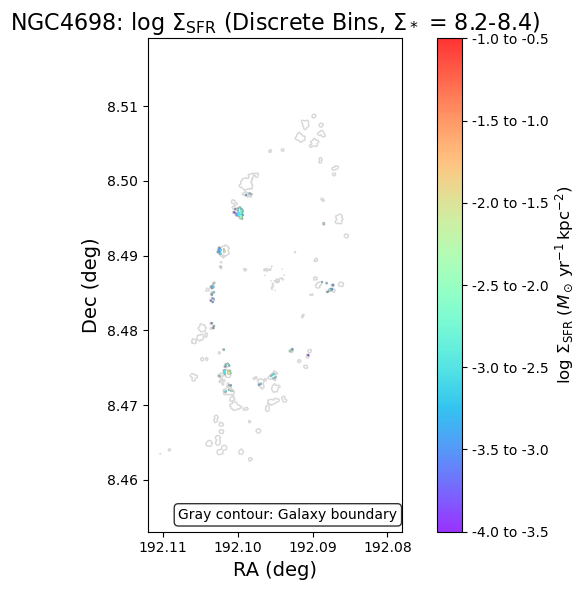

In [19]:
# ------------------------------------------------------------------
# 0.  List galaxies and pin one colour to each
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = ['NGC4698']        # auto-detect
cmap   = plt.get_cmap('tab20').colors                      # 20 hues
colour = {g: cmap[i % len(cmap)] for i, g in enumerate(galaxies)}

# ------------------------------------------------------------------
# 1.  Helper: read the two maps
# ------------------------------------------------------------------
def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
        mass_header = h['LOGMASS_SURFACE_DENSITY'].header
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR = h['LOGSFR_SURFACE_DENSITY_HII'].data
        gas_header = h['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, wcs, mass_header, gas_header

# Define stellar mass surface density range filter
mass_min, mass_max = 8.2, 8.4
print(f"Filtering spaxels to stellar mass surface density range: {mass_min} to {mass_max}")

# Update the code to show only the middle panel (SFR map) with discrete bins
for gal in galaxies:
    sigM, sigSFR, wcs, mass_header, gas_header = load_maps(gal)
    
    # Apply stellar mass surface density filter
    mass_filter = (sigM >= mass_min) & (sigM <= mass_max)
    good = np.isfinite(sigM) & np.isfinite(sigSFR) & mass_filter
    
    # Create galaxy outline mask (all valid pixels, not mass-filtered)
    galaxy_outline = np.isfinite(sigM) & np.isfinite(sigSFR)
    
    # Count total and filtered spaxels
    total_spaxels = np.sum(np.isfinite(sigM) & np.isfinite(sigSFR))
    filtered_spaxels = np.sum(good)
    print(f"\nTotal valid spaxels: {total_spaxels}")
    print(f"Spaxels in mass range {mass_min}-{mass_max}: {filtered_spaxels} ({filtered_spaxels/total_spaxels*100:.1f}%)")

    # Convert pixel area to physical area in pc²
    legacy_wcs2 = WCS(gas_header).celestial  # strip spectral axis
    
    # Get the extent from WCS for proper coordinate axes
    y_size, x_size = sigM.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    # Convert pixel coordinates to world coordinates
    ra, dec = legacy_wcs2.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]  # [left, right, bottom, top]

    # Define discrete SFR bins: -4 to -0.5 with 0.5 bin width (7 bins)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    print(f"SFR bin edges: {sfr_bin_edges}")
    print(f"Number of bins: {n_bins}")
    
    # Create discrete SFR map based on bins, but only for mass-filtered spaxels
    sfr_discrete = np.full_like(sigSFR, np.nan)
    
    # Assign each pixel to its corresponding bin, but only if it passes the mass filter
    for i in range(n_bins):
        bin_mask = (sigSFR >= sfr_bin_edges[i]) & (sigSFR < sfr_bin_edges[i+1]) & mass_filter
        sfr_discrete[bin_mask] = i  # Assign bin index
    
    # Handle the last bin edge (include pixels exactly at -0.5), but only if it passes the mass filter
    last_bin_mask = (sigSFR >= sfr_bin_edges[-1]) & mass_filter
    sfr_discrete[last_bin_mask] = n_bins - 1

    fig = plt.figure(figsize=(10, 6))

    # --- Discrete Σ_SFR map (mass-filtered) with galaxy outline -----------------------------------------------
    ax = fig.add_subplot(1, 1, 1)
    
    # Use rainbow colormap for discrete bins
    cmap_rainbow = plt.cm.rainbow
    
    # Plot the mass-filtered discrete SFR map
    im = ax.imshow(sfr_discrete, origin='lower', cmap=cmap_rainbow, 
                   extent=extent, vmin=0, vmax=n_bins-1, alpha=0.8)
    
    # Add galaxy outline contour
    # Create contour levels for the galaxy boundary
    contour_levels = [0.5]  # Single contour level to define the boundary
    
    # Convert galaxy_outline boolean to float for contouring
    galaxy_mask_float = galaxy_outline.astype(float)
    
    # Add gray contour to show the entire galaxy region
    # Use world coordinates (ra, dec) with proper origin='lower' to match imshow
    contours = ax.contour(ra, dec, galaxy_mask_float, levels=contour_levels, 
                         colors='gray', linewidths=1, linestyles='-', 
                         origin='lower', alpha=0.3)
    
    # Check if SFR map has any data to display
    n_sfr_pixels = np.sum(np.isfinite(sfr_discrete))
    print(f"Number of SFR pixels displayed: {n_sfr_pixels}")
    
    if n_sfr_pixels == 0:
        print("Warning: No SFR data to display - check mass filter range!")
        # Add a faint background to show the entire galaxy outline
        background_map = np.where(galaxy_outline, 0.1, np.nan)
        ax.imshow(background_map, origin='lower', cmap='gray', 
                 extent=extent, alpha=0.3, vmin=0, vmax=1)
    
    ax.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (Discrete Bins, $\Sigma_*$ = {mass_min}-{mass_max})', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    
    # Ensure RA axis increases from left to right
    # ax.invert_xaxis()  # This will make RA increase from left to right
    
    # Create custom colorbar with discrete bins and labels (only if there's data)
    if n_sfr_pixels > 0:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        
        # Set discrete ticks and labels for the colorbar
        tick_positions = np.arange(n_bins)
        tick_labels = [f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}' for i in range(n_bins)]
        cbar.set_ticks(tick_positions)
        cbar.set_ticklabels(tick_labels)
    
    # Add text annotation to explain the gray contour
    ax.text(0.98, 0.02, 'Gray contour: Galaxy boundary', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Print bin information (only for mass-filtered spaxels)
    print(f"\nSFR bin information for {gal} (mass-filtered, {mass_min}-{mass_max}):")
    total_filtered_pixels = 0
    for i in range(n_bins):
        bin_mask = (sfr_discrete == i) & np.isfinite(sfr_discrete)
        n_pixels = np.sum(bin_mask)
        total_filtered_pixels += n_pixels
        if n_pixels > 0:
            # Calculate statistics for this bin
            sfr_values = sigSFR[bin_mask]
            mass_values = sigM[bin_mask]
            print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")
            print(f"    SFR range: {np.min(sfr_values):.2f} to {np.max(sfr_values):.2f}")
            print(f"    Mass range: {np.min(mass_values):.2f} to {np.max(mass_values):.2f}")
        else:
            print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")
    
    print(f"\nTotal pixels shown in filtered map: {total_filtered_pixels}")
    print(f"Gray contour shows the entire galaxy region ({total_spaxels} total spaxels)")

    plt.tight_layout()
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_mass_filtered_{mass_min}_{mass_max}_with_outline.png', dpi=600)
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_mass_filtered_{mass_min}_{mass_max}_with_outline.pdf')
    plt.show()

Filtering spaxels to stellar mass surface density range: 8.9 to 9.1

Total valid spaxels: 10181
Spaxels in mass range 8.9-9.1: 9 (0.1%)
SFR bin edges: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5]
Number of bins: 7
Number of SFR pixels displayed: 9

SFR bin information for NGC4698 (mass-filtered, 8.9-9.1):
  Bin 0: -4.0 to -3.5 - 0 pixels
  Bin 1: -3.5 to -3.0 - 0 pixels
  Bin 2: -3.0 to -2.5 - 9 pixels
    SFR range: -2.79 to -2.73
    Mass range: 8.90 to 8.94
  Bin 3: -2.5 to -2.0 - 0 pixels
  Bin 4: -2.0 to -1.5 - 0 pixels
  Bin 5: -1.5 to -1.0 - 0 pixels
  Bin 6: -1.0 to -0.5 - 0 pixels

Total pixels shown in filtered map: 9
Gray contour shows the entire galaxy region (10181 total spaxels)


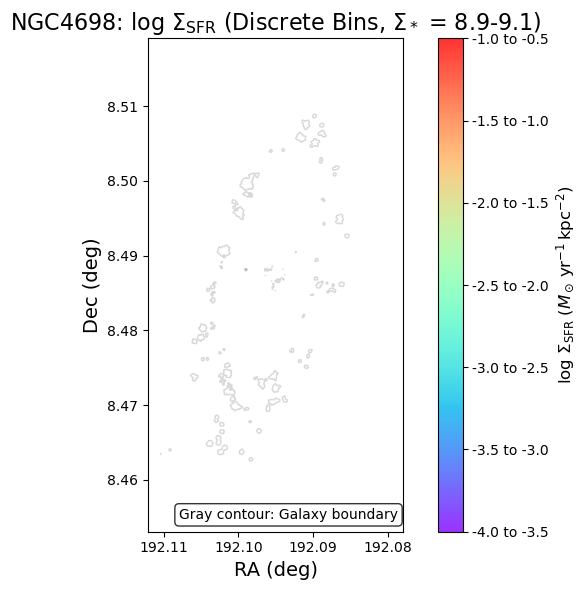

In [20]:
# ------------------------------------------------------------------
# 0.  List galaxies and pin one colour to each
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = ['NGC4698']        # auto-detect
cmap   = plt.get_cmap('tab20').colors                      # 20 hues
colour = {g: cmap[i % len(cmap)] for i, g in enumerate(galaxies)}

# ------------------------------------------------------------------
# 1.  Helper: read the two maps
# ------------------------------------------------------------------
def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
        mass_header = h['LOGMASS_SURFACE_DENSITY'].header
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR = h['LOGSFR_SURFACE_DENSITY_HII'].data
        gas_header = h['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, wcs, mass_header, gas_header

# Define stellar mass surface density range filter
mass_min, mass_max = 8.9, 9.1
print(f"Filtering spaxels to stellar mass surface density range: {mass_min} to {mass_max}")

# Update the code to show only the middle panel (SFR map) with discrete bins
for gal in galaxies:
    sigM, sigSFR, wcs, mass_header, gas_header = load_maps(gal)
    
    # Apply stellar mass surface density filter
    mass_filter = (sigM >= mass_min) & (sigM <= mass_max)
    good = np.isfinite(sigM) & np.isfinite(sigSFR) & mass_filter
    
    # Create galaxy outline mask (all valid pixels, not mass-filtered)
    galaxy_outline = np.isfinite(sigM) & np.isfinite(sigSFR)
    
    # Count total and filtered spaxels
    total_spaxels = np.sum(np.isfinite(sigM) & np.isfinite(sigSFR))
    filtered_spaxels = np.sum(good)
    print(f"\nTotal valid spaxels: {total_spaxels}")
    print(f"Spaxels in mass range {mass_min}-{mass_max}: {filtered_spaxels} ({filtered_spaxels/total_spaxels*100:.1f}%)")

    # Convert pixel area to physical area in pc²
    legacy_wcs2 = WCS(gas_header).celestial  # strip spectral axis
    
    # Get the extent from WCS for proper coordinate axes
    y_size, x_size = sigM.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    # Convert pixel coordinates to world coordinates
    ra, dec = legacy_wcs2.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]  # [left, right, bottom, top]

    # Define discrete SFR bins: -4 to -0.5 with 0.5 bin width (7 bins)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    print(f"SFR bin edges: {sfr_bin_edges}")
    print(f"Number of bins: {n_bins}")
    
    # Create discrete SFR map based on bins, but only for mass-filtered spaxels
    sfr_discrete = np.full_like(sigSFR, np.nan)
    
    # Assign each pixel to its corresponding bin, but only if it passes the mass filter
    for i in range(n_bins):
        bin_mask = (sigSFR >= sfr_bin_edges[i]) & (sigSFR < sfr_bin_edges[i+1]) & mass_filter
        sfr_discrete[bin_mask] = i  # Assign bin index
    
    # Handle the last bin edge (include pixels exactly at -0.5), but only if it passes the mass filter
    last_bin_mask = (sigSFR >= sfr_bin_edges[-1]) & mass_filter
    sfr_discrete[last_bin_mask] = n_bins - 1

    fig = plt.figure(figsize=(10, 6))

    # --- Discrete Σ_SFR map (mass-filtered) with galaxy outline -----------------------------------------------
    ax = fig.add_subplot(1, 1, 1)
    
    # Use rainbow colormap for discrete bins
    cmap_rainbow = plt.cm.rainbow
    
    # Plot the mass-filtered discrete SFR map
    im = ax.imshow(sfr_discrete, origin='lower', cmap=cmap_rainbow, 
                   extent=extent, vmin=0, vmax=n_bins-1, alpha=0.8)
    
    # Add galaxy outline contour
    # Create contour levels for the galaxy boundary
    contour_levels = [0.5]  # Single contour level to define the boundary
    
    # Convert galaxy_outline boolean to float for contouring
    galaxy_mask_float = galaxy_outline.astype(float)
    
    # Add gray contour to show the entire galaxy region
    # Use world coordinates (ra, dec) with proper origin='lower' to match imshow
    contours = ax.contour(ra, dec, galaxy_mask_float, levels=contour_levels, 
                         colors='gray', linewidths=1, linestyles='-', 
                         origin='lower', alpha=0.3)
    
    # Check if SFR map has any data to display
    n_sfr_pixels = np.sum(np.isfinite(sfr_discrete))
    print(f"Number of SFR pixels displayed: {n_sfr_pixels}")
    
    if n_sfr_pixels == 0:
        print("Warning: No SFR data to display - check mass filter range!")
        # Add a faint background to show the entire galaxy outline
        background_map = np.where(galaxy_outline, 0.1, np.nan)
        ax.imshow(background_map, origin='lower', cmap='gray', 
                 extent=extent, alpha=0.3, vmin=0, vmax=1)
    
    ax.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (Discrete Bins, $\Sigma_*$ = {mass_min}-{mass_max})', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    
    # Ensure RA axis increases from left to right
    # ax.invert_xaxis()  # This will make RA increase from left to right
    
    # Create custom colorbar with discrete bins and labels (only if there's data)
    if n_sfr_pixels > 0:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        
        # Set discrete ticks and labels for the colorbar
        tick_positions = np.arange(n_bins)
        tick_labels = [f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}' for i in range(n_bins)]
        cbar.set_ticks(tick_positions)
        cbar.set_ticklabels(tick_labels)
    
    # Add text annotation to explain the gray contour
    ax.text(0.98, 0.02, 'Gray contour: Galaxy boundary', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Print bin information (only for mass-filtered spaxels)
    print(f"\nSFR bin information for {gal} (mass-filtered, {mass_min}-{mass_max}):")
    total_filtered_pixels = 0
    for i in range(n_bins):
        bin_mask = (sfr_discrete == i) & np.isfinite(sfr_discrete)
        n_pixels = np.sum(bin_mask)
        total_filtered_pixels += n_pixels
        if n_pixels > 0:
            # Calculate statistics for this bin
            sfr_values = sigSFR[bin_mask]
            mass_values = sigM[bin_mask]
            print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")
            print(f"    SFR range: {np.min(sfr_values):.2f} to {np.max(sfr_values):.2f}")
            print(f"    Mass range: {np.min(mass_values):.2f} to {np.max(mass_values):.2f}")
        else:
            print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")
    
    print(f"\nTotal pixels shown in filtered map: {total_filtered_pixels}")
    print(f"Gray contour shows the entire galaxy region ({total_spaxels} total spaxels)")

    plt.tight_layout()
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_mass_filtered_{mass_min}_{mass_max}_with_outline.png', dpi=600)
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_mass_filtered_{mass_min}_{mass_max}_with_outline.pdf')
    plt.show()

## 20250923 BPT again

```python
#  N II BPT -----------------------------------------
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19
def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30                            

#  S II BPT -----------------------------------------
def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30                           
def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76  

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)
```

Total pixels: 722912
Common valid pixels across all calibrations: 10042


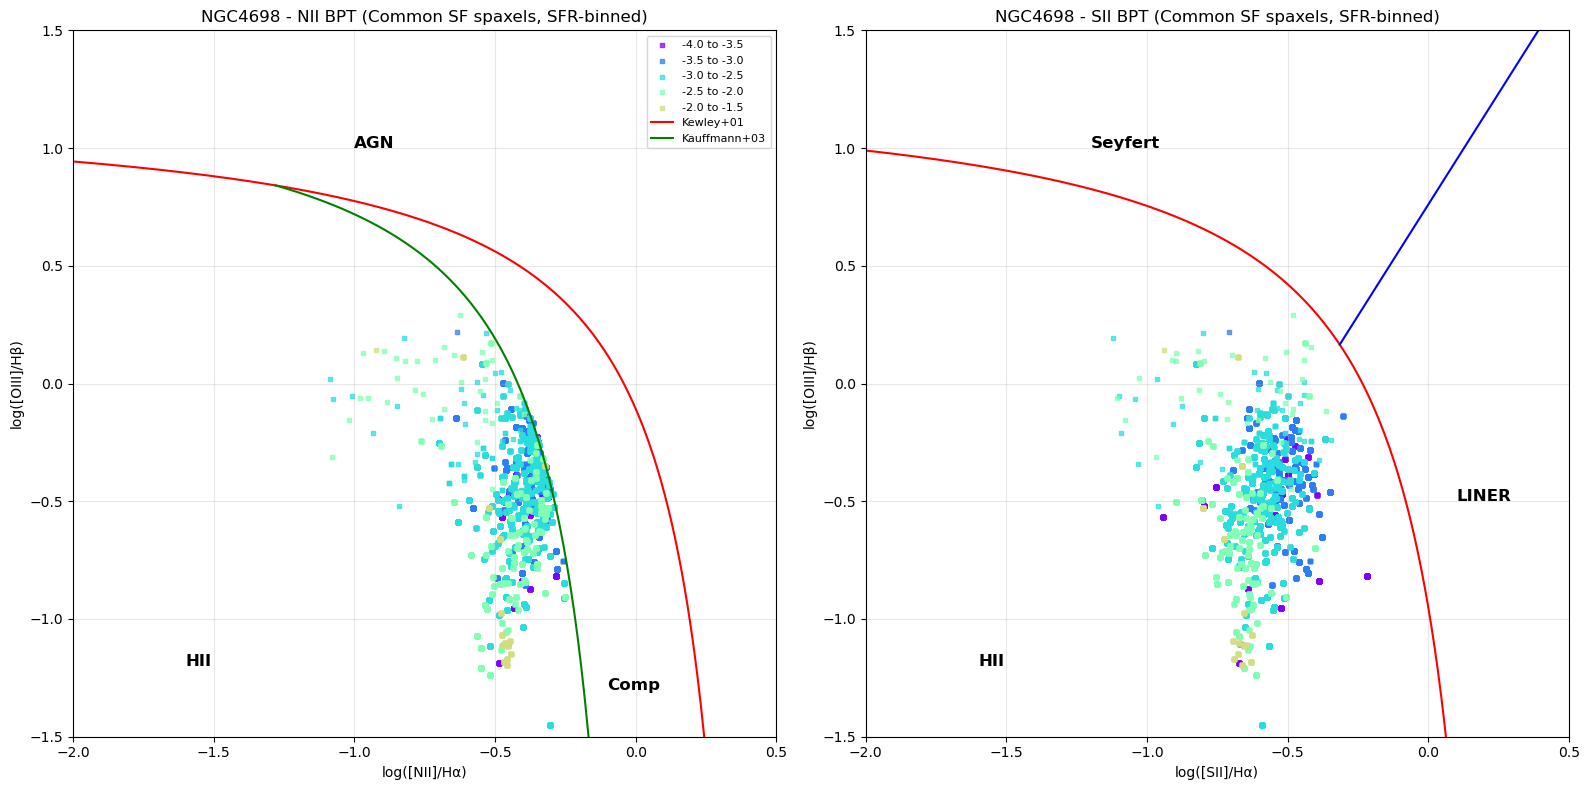


=== NGC4698 BPT Diagram Summary (Common SF spaxels only) ===
Common valid spaxels (all 4 metallicity calibrations): 10042

BPT classifications for common spaxels:
  N2 BPT - HII: 10042 (100.0%)
  N2 BPT - Comp: 0 (0.0%)
  N2 BPT - AGN: 0 (0.0%)
  N2 BPT - Total SF: 10042 (100.0%)
  S2 BPT - HII: 10042 (100.0%)
  S2 BPT - LINER: 0 (0.0%)
  S2 BPT - Seyfert: 0 (0.0%)
  S2 BPT - Total SF: 10042 (100.0%)

SFR bin breakdown for SF spaxels:
  Bin 0 (-4.0 to -3.5): N2_HII=558, S2_HII=558
  Bin 1 (-3.5 to -3.0): N2_HII=2604, S2_HII=2604
  Bin 2 (-3.0 to -2.5): N2_HII=4633, S2_HII=4633
  Bin 3 (-2.5 to -2.0): N2_HII=1900, S2_HII=1900
  Bin 4 (-2.0 to -1.5): N2_HII=204, S2_HII=204
  Bin 5 (-1.5 to -1.0): N2_HII=0, S2_HII=0
  Bin 6 (-1.0 to -0.5): N2_HII=0, S2_HII=0


In [21]:
# ------------------------------------------------------------------
# NGC4698 NII and SII BPT Diagrams for Common SF Spaxels Only
# Simple approach: Use corrected fluxes + common_mask for SF spaxels
# Color-coded by SFR bins
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Focus on NGC4698
gal = 'NGC4698'
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if gas_file.exists():
    # Load corrected emission line data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # Load corrected emission line fluxes
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    
    # Apply common_mask to corrected fluxes to get SF spaxels
    HB_common = HB4861_FLUX_corr[common_mask]
    HA_common = HA6562_FLUX_corr[common_mask]
    OIII_common = OIII5006_FLUX_corr[common_mask]
    NII_common = NII6583_FLUX_corr[common_mask]
    SII6716_common = SII6716_FLUX_corr[common_mask]
    SII6730_common = SII6730_FLUX_corr[common_mask]
    
    # Calculate line ratios for common SF spaxels
    logN2_common = np.log10(NII_common / HA_common)
    logO3_common = np.log10(OIII_common / HB_common)
    logS2_common = np.log10((SII6716_common + SII6730_common) / HA_common)
    
    # Get SFR values for common spaxels
    logSFR_common = logSigmaSFR[common_mask]
    
    # Create SFR bins for color coding (same as cell 22)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Assign SFR bin indices to common SF spaxels
    sfr_bin_indices_common = np.full_like(logSFR_common, -1, dtype=int)  # -1 for non-assigned
    
    for i in range(n_bins):
        bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common < sfr_bin_edges[i+1])
        if i == n_bins - 1:  # Last bin includes the upper edge
            bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common <= sfr_bin_edges[i+1])
        sfr_bin_indices_common[bin_mask] = i
    
    # Apply BPT classifications to common SF spaxels
    # N2 BPT classifications
    mask_N2_HII_common = logO3_common <= kauff03_N2(logN2_common)
    mask_N2_Comp_common = (logO3_common > kauff03_N2(logN2_common)) & (logO3_common <= kewley01_N2(logN2_common))
    mask_N2_AGN_common = logO3_common > kewley01_N2(logN2_common)
    
    # S2 BPT classifications  
    mask_S2_HII_common = logO3_common <= kewley01_S2(logS2_common)
    mask_S2_above_kewley_common = logO3_common > kewley01_S2(logS2_common)
    mask_S2_LINER_common = mask_S2_above_kewley_common & (logO3_common <= kewley06_Sy_LIN(logS2_common))
    mask_S2_Seyfert_common = mask_S2_above_kewley_common & (logO3_common > kewley06_Sy_LIN(logS2_common))
    
    # Define SF masks for common spaxels
    mask_HII_N2_common = mask_N2_HII_common | mask_N2_Comp_common
    mask_HII_S2_common = mask_S2_HII_common
    
    # Create BPT diagrams
    plt.figure(figsize=(16, 8))
    
    # Define colors for SFR bins (rainbow colormap)
    cmap_rainbow = plt.cm.rainbow
    colors = [cmap_rainbow(i / (n_bins - 1)) for i in range(n_bins)]
    
    # NII BPT Diagram
    plt.subplot(1, 2, 1)
    
    # Plot only SF spaxels from common mask, color-coded by SFR bins
    for i in range(n_bins):
        bin_sf_mask = mask_HII_N2_common & (sfr_bin_indices_common == i)
        if np.sum(bin_sf_mask) > 0:
            plt.scatter(logN2_common[bin_sf_mask], logO3_common[bin_sf_mask], 
                       color=colors[i], 
                       label=f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}', 
                       marker=',', s=8, alpha=0.7)
    
    # Plot reference lines
    plt.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
    plt.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')
    
    # Calculate statistics
    total_common = len(logN2_common)
    sf_count_N2 = np.sum(mask_HII_N2_common)
    sf_percent_N2 = sf_count_N2 / total_common * 100 if total_common > 0 else 0
       
    plt.xlabel('log([NII]/Hα)')
    plt.ylabel('log([OIII]/Hβ)')
    plt.xlim(-2.0, 0.5)
    plt.ylim(-1.5, 1.5)
    plt.title(f'{gal} - NII BPT (Common SF spaxels, SFR-binned)')
    plt.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
    plt.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
    plt.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # SII BPT Diagram
    plt.subplot(1, 2, 2)
    
    # Plot only SF spaxels from common mask, color-coded by SFR bins
    for i in range(n_bins):
        bin_sf_mask = mask_HII_S2_common & (sfr_bin_indices_common == i)
        if np.sum(bin_sf_mask) > 0:
            plt.scatter(logS2_common[bin_sf_mask], logO3_common[bin_sf_mask], 
                       color=colors[i], 
                       label=f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}', 
                       marker=',', s=8, alpha=0.7)
    
    # Plot reference lines
    plt.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5, label='Kewley+01')
    plt.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5, label='Kewley+06')
    
    # Calculate statistics
    sf_count_S2 = np.sum(mask_HII_S2_common)
    sf_percent_S2 = sf_count_S2 / total_common * 100 if total_common > 0 else 0
    
    plt.xlabel('log([SII]/Hα)')
    plt.ylabel('log([OIII]/Hβ)')
    plt.xlim(-2.0, 0.5)
    plt.ylim(-1.5, 1.5)
    plt.title(f'{gal} - SII BPT (Common SF spaxels, SFR-binned)')
    plt.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
    plt.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
    plt.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {gal} BPT Diagram Summary (Common SF spaxels only) ===")
    print(f"Common valid spaxels (all 4 metallicity calibrations): {total_common}")
    print(f"\nBPT classifications for common spaxels:")
    print(f"  N2 BPT - HII: {np.sum(mask_N2_HII_common)} ({np.sum(mask_N2_HII_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Comp: {np.sum(mask_N2_Comp_common)} ({np.sum(mask_N2_Comp_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - AGN: {np.sum(mask_N2_AGN_common)} ({np.sum(mask_N2_AGN_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Total SF: {sf_count_N2} ({sf_percent_N2:.1f}%)")
    print(f"  S2 BPT - HII: {np.sum(mask_S2_HII_common)} ({np.sum(mask_S2_HII_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - LINER: {np.sum(mask_S2_LINER_common)} ({np.sum(mask_S2_LINER_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Seyfert: {np.sum(mask_S2_Seyfert_common)} ({np.sum(mask_S2_Seyfert_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Total SF: {sf_count_S2} ({sf_percent_S2:.1f}%)")
    
    # Print SFR bin breakdown for SF spaxels
    print(f"\nSFR bin breakdown for SF spaxels:")
    for i in range(n_bins):
        bin_sf_n2 = np.sum(mask_HII_N2_common & (sfr_bin_indices_common == i))
        bin_sf_s2 = np.sum(mask_HII_S2_common & (sfr_bin_indices_common == i))
        print(f"  Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}): N2_HII={bin_sf_n2}, S2_HII={bin_sf_s2}")
    
else:
    print(f"Gas emission line file not found for {gal}")

Total pixels: 722912
Common valid pixels across all calibrations: 10042


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17443/3895280805.py:123: UserWarning: The following kwargs were not used by contour: 'label'
  contours = plt.contour(X, Y, H.T, levels=levels, colors=[colors[i]],


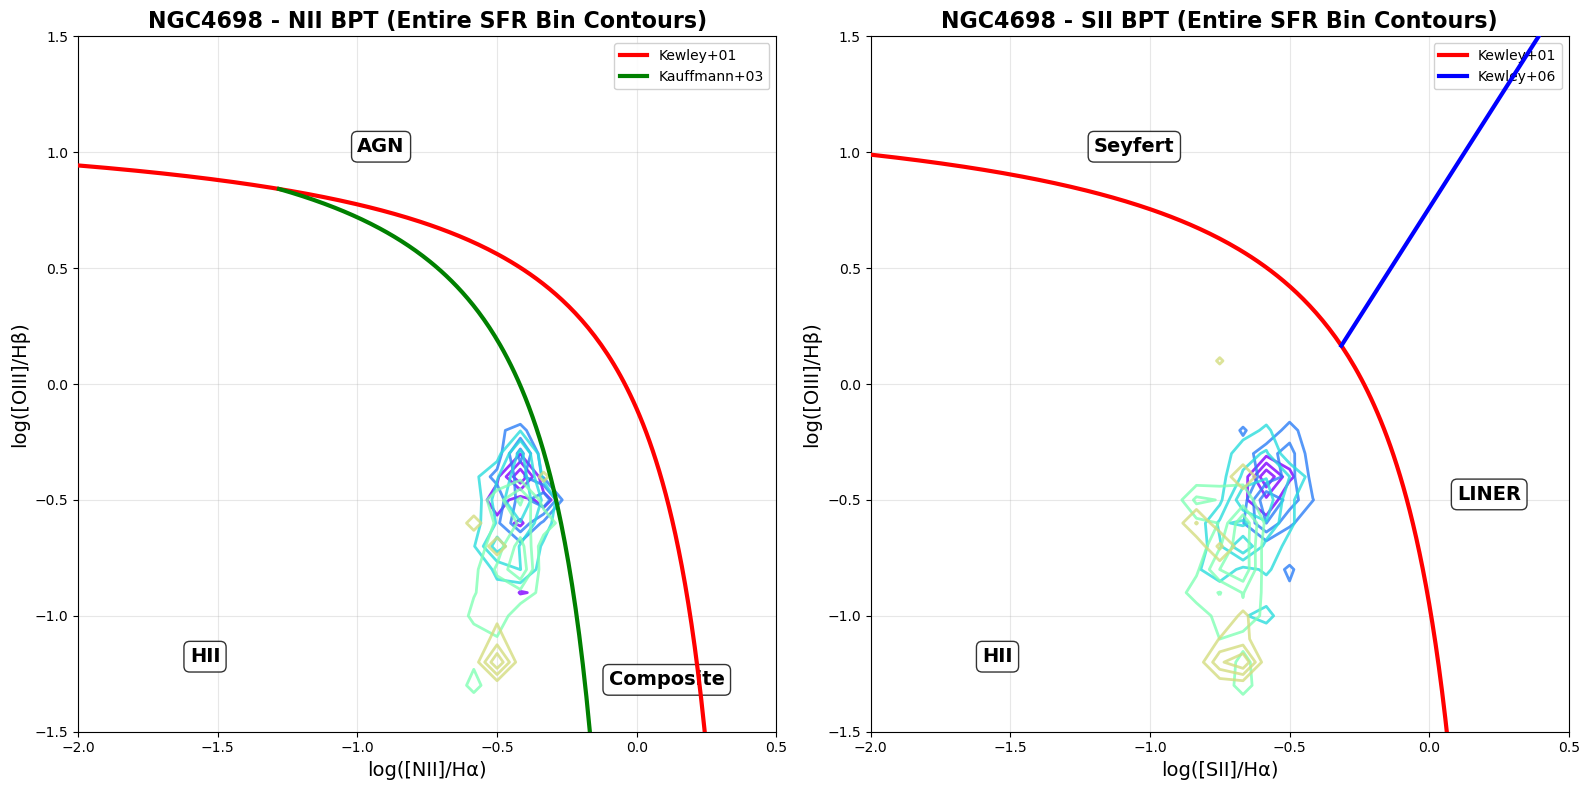


=== NGC4698 ENTIRE SFR BIN CONTOUR ANALYSIS ===
Total common valid spaxels: 10042

SFR bin distribution across ENTIRE BPT parameter space:
  Bin 0 (-4.0 to -3.5): 558 spaxels (5.6%)
  Bin 1 (-3.5 to -3.0): 2604 spaxels (25.9%)
  Bin 2 (-3.0 to -2.5): 4633 spaxels (46.1%)
  Bin 3 (-2.5 to -2.0): 1900 spaxels (18.9%)
  Bin 4 (-2.0 to -1.5): 204 spaxels (2.0%)
  Bin 5 (-1.5 to -1.0): 0 spaxels (0.0%)
  Bin 6 (-1.0 to -0.5): 0 spaxels (0.0%)

BPT region analysis for each SFR bin:

  SFR Bin 0 (-4.0 to -3.5) - 558 total spaxels:
    N2 BPT: HII=558 (100.0%), Comp=0 (0.0%), AGN=0 (0.0%)
    S2 BPT: HII=558 (100.0%), LINER=0 (0.0%), Seyfert=0 (0.0%)

  SFR Bin 1 (-3.5 to -3.0) - 2604 total spaxels:
    N2 BPT: HII=2604 (100.0%), Comp=0 (0.0%), AGN=0 (0.0%)
    S2 BPT: HII=2604 (100.0%), LINER=0 (0.0%), Seyfert=0 (0.0%)

  SFR Bin 2 (-3.0 to -2.5) - 4633 total spaxels:
    N2 BPT: HII=4633 (100.0%), Comp=0 (0.0%), AGN=0 (0.0%)
    S2 BPT: HII=4633 (100.0%), LINER=0 (0.0%), Seyfert=0 (0.0%)

 

In [22]:
# ------------------------------------------------------------------
# NGC4698 NII and SII BPT Diagrams - CONTOURS FOR ENTIRE SFR BINS
# Show contours for all spaxels in each SFR bin (not just SF regions)
# Each SFR bin gets its own colored contour across the entire BPT space
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from scipy.stats import gaussian_kde
from scipy import stats

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Focus on NGC4698
gal = 'NGC4698'
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if gas_file.exists():
    # Load corrected emission line data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # Load corrected emission line fluxes
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    
    # Apply common_mask to corrected fluxes to get all valid spaxels
    HB_common = HB4861_FLUX_corr[common_mask]
    HA_common = HA6562_FLUX_corr[common_mask]
    OIII_common = OIII5006_FLUX_corr[common_mask]
    NII_common = NII6583_FLUX_corr[common_mask]
    SII6716_common = SII6716_FLUX_corr[common_mask]
    SII6730_common = SII6730_FLUX_corr[common_mask]
    
    # Calculate line ratios for ALL common spaxels (not just SF)
    logN2_common = np.log10(NII_common / HA_common)
    logO3_common = np.log10(OIII_common / HB_common)
    logS2_common = np.log10((SII6716_common + SII6730_common) / HA_common)
    
    # Get SFR values for common spaxels
    logSFR_common = logSigmaSFR[common_mask]
    
    # Create SFR bins for color coding
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # 7 bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Assign SFR bin indices to ALL common spaxels
    sfr_bin_indices_common = np.full_like(logSFR_common, -1, dtype=int)  # -1 for non-assigned
    
    for i in range(n_bins):
        bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common < sfr_bin_edges[i+1])
        if i == n_bins - 1:  # Last bin includes the upper edge
            bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common <= sfr_bin_edges[i+1])
        sfr_bin_indices_common[bin_mask] = i
    
    # Create BPT diagrams with contours for each entire SFR bin
    plt.figure(figsize=(16, 8))
    
    # Define colors for SFR bins (rainbow colormap)
    cmap_rainbow = plt.cm.rainbow
    colors = [cmap_rainbow(i / (n_bins - 1)) for i in range(n_bins)]
    
    # Define BPT ranges for better visualization
    N2_range = [-2.0, 0.5]
    O3_range = [-1.5, 1.5]
    S2_range = [-2.0, 0.5]
    
    # NII BPT Diagram - Show contours for ENTIRE SFR bins
    plt.subplot(1, 2, 1)
    
    # Plot contours for each ENTIRE SFR bin
    for i in range(n_bins):
        # Get ALL spaxels in this SFR bin (not just SF)
        bin_mask = (sfr_bin_indices_common == i)
        
        if np.sum(bin_mask) > 10:  # Need sufficient points for contours
            x_bin = logN2_common[bin_mask]
            y_bin = logO3_common[bin_mask]
            
            # Filter out extreme outliers for better contour visualization
            x_valid = (x_bin >= N2_range[0]) & (x_bin <= N2_range[1])
            y_valid = (y_bin >= O3_range[0]) & (y_bin <= O3_range[1])
            valid_mask = x_valid & y_valid
            
            if np.sum(valid_mask) > 10:
                x_plot = x_bin[valid_mask]
                y_plot = y_bin[valid_mask]
                
                # Create 2D histogram for contours with higher resolution
                H, xedges, yedges = np.histogram2d(x_plot, y_plot, bins=30, 
                                                  range=[N2_range, O3_range])
                
                # Only plot if there's significant density
                if H.max() > 0:
                    # Create meshgrid for contour plotting
                    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
                    
                    # Plot contours for this entire SFR bin
                    levels = np.linspace(H.max()*0.2, H.max(), 4)  # 4 contour levels
                    contours = plt.contour(X, Y, H.T, levels=levels, colors=[colors[i]], 
                                         alpha=0.8, linewidths=2.0,
                                         label=f'SFR {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}')
    
    # Plot reference lines
    plt.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)
    plt.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)
    
    plt.xlabel('log([NII]/Hα)', fontsize=14)
    plt.ylabel('log([OIII]/Hβ)', fontsize=14)
    plt.xlim(N2_range)
    plt.ylim(O3_range)
    plt.title(f'{gal} - NII BPT (Entire SFR Bin Contours)', fontsize=16, fontweight='bold')
    
    # Add region labels
    plt.text(-1.6, -1.2, 'HII', fontsize=14, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    plt.text(-0.1, -1.3, 'Composite', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    plt.text(-1.0, 1.0, 'AGN', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Legend for SFR bins
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    
    # SII BPT Diagram - Show contours for ENTIRE SFR bins
    plt.subplot(1, 2, 2)
    
    # Plot contours for each ENTIRE SFR bin
    for i in range(n_bins):
        # Get ALL spaxels in this SFR bin (not just SF)
        bin_mask = (sfr_bin_indices_common == i)
        
        if np.sum(bin_mask) > 10:  # Need sufficient points for contours
            x_bin = logS2_common[bin_mask]
            y_bin = logO3_common[bin_mask]
            
            # Filter out extreme outliers for better contour visualization
            x_valid = (x_bin >= S2_range[0]) & (x_bin <= S2_range[1])
            y_valid = (y_bin >= O3_range[0]) & (y_bin <= O3_range[1])
            valid_mask = x_valid & y_valid
            
            if np.sum(valid_mask) > 10:
                x_plot = x_bin[valid_mask]
                y_plot = y_bin[valid_mask]
                
                # Create 2D histogram for contours with higher resolution
                H, xedges, yedges = np.histogram2d(x_plot, y_plot, bins=30, 
                                                  range=[S2_range, O3_range])
                
                # Only plot if there's significant density
                if H.max() > 0:
                    # Create meshgrid for contour plotting
                    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
                    
                    # Plot contours for this entire SFR bin
                    levels = np.linspace(H.max()*0.2, H.max(), 4)  # 4 contour levels
                    contours = plt.contour(X, Y, H.T, levels=levels, colors=[colors[i]], 
                                         alpha=0.8, linewidths=2.0)
    
    # Plot reference lines
    plt.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)
    plt.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)
    
    plt.xlabel('log([SII]/Hα)', fontsize=14)
    plt.ylabel('log([OIII]/Hβ)', fontsize=14)
    plt.xlim(S2_range)
    plt.ylim(O3_range)
    plt.title(f'{gal} - SII BPT (Entire SFR Bin Contours)', fontsize=16, fontweight='bold')
    
    # Add region labels
    plt.text(-1.6, -1.2, 'HII', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    plt.text(-1.2, 1.0, 'Seyfert', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    plt.text(0.1, -0.5, 'LINER', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive statistics for entire SFR bins
    print(f"\n=== {gal} ENTIRE SFR BIN CONTOUR ANALYSIS ===")
    print(f"Total common valid spaxels: {len(logN2_common)}")
    
    print(f"\nSFR bin distribution across ENTIRE BPT parameter space:")
    for i in range(n_bins):
        bin_count = np.sum(sfr_bin_indices_common == i)
        bin_percent = bin_count / len(logN2_common) * 100 if len(logN2_common) > 0 else 0
        print(f"  Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}): {bin_count} spaxels ({bin_percent:.1f}%)")
    
    # Calculate how SFR bins are distributed across BPT regions
    print(f"\nBPT region analysis for each SFR bin:")
    
    # N2 BPT classifications for ALL spaxels
    mask_N2_HII_all = logO3_common <= kauff03_N2(logN2_common)
    mask_N2_Comp_all = (logO3_common > kauff03_N2(logN2_common)) & (logO3_common <= kewley01_N2(logN2_common))
    mask_N2_AGN_all = logO3_common > kewley01_N2(logN2_common)
    
    # S2 BPT classifications for ALL spaxels
    mask_S2_HII_all = logO3_common <= kewley01_S2(logS2_common)
    mask_S2_above_kewley_all = logO3_common > kewley01_S2(logS2_common)
    mask_S2_LINER_all = mask_S2_above_kewley_all & (logO3_common <= kewley06_Sy_LIN(logS2_common))
    mask_S2_Seyfert_all = mask_S2_above_kewley_all & (logO3_common > kewley06_Sy_LIN(logS2_common))
    
    for i in range(n_bins):
        bin_mask = (sfr_bin_indices_common == i)
        bin_count = np.sum(bin_mask)
        
        if bin_count > 0:
            # N2 BPT breakdown for this SFR bin
            n2_hii = np.sum(bin_mask & mask_N2_HII_all)
            n2_comp = np.sum(bin_mask & mask_N2_Comp_all)
            n2_agn = np.sum(bin_mask & mask_N2_AGN_all)
            
            # S2 BPT breakdown for this SFR bin
            s2_hii = np.sum(bin_mask & mask_S2_HII_all)
            s2_liner = np.sum(bin_mask & mask_S2_LINER_all)
            s2_seyfert = np.sum(bin_mask & mask_S2_Seyfert_all)
            
            print(f"\n  SFR Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}) - {bin_count} total spaxels:")
            print(f"    N2 BPT: HII={n2_hii} ({n2_hii/bin_count*100:.1f}%), Comp={n2_comp} ({n2_comp/bin_count*100:.1f}%), AGN={n2_agn} ({n2_agn/bin_count*100:.1f}%)")
            print(f"    S2 BPT: HII={s2_hii} ({s2_hii/bin_count*100:.1f}%), LINER={s2_liner} ({s2_liner/bin_count*100:.1f}%), Seyfert={s2_seyfert} ({s2_seyfert/bin_count*100:.1f}%)")
    
else:
    print(f"Gas emission line file not found for {gal}")

Filtering spaxels to stellar mass surface density range: 8.2 to 8.4
Total pixels: 722912
Common valid pixels across all calibrations: 10042
Common valid pixels with mass filter (8.2-8.4): 1578


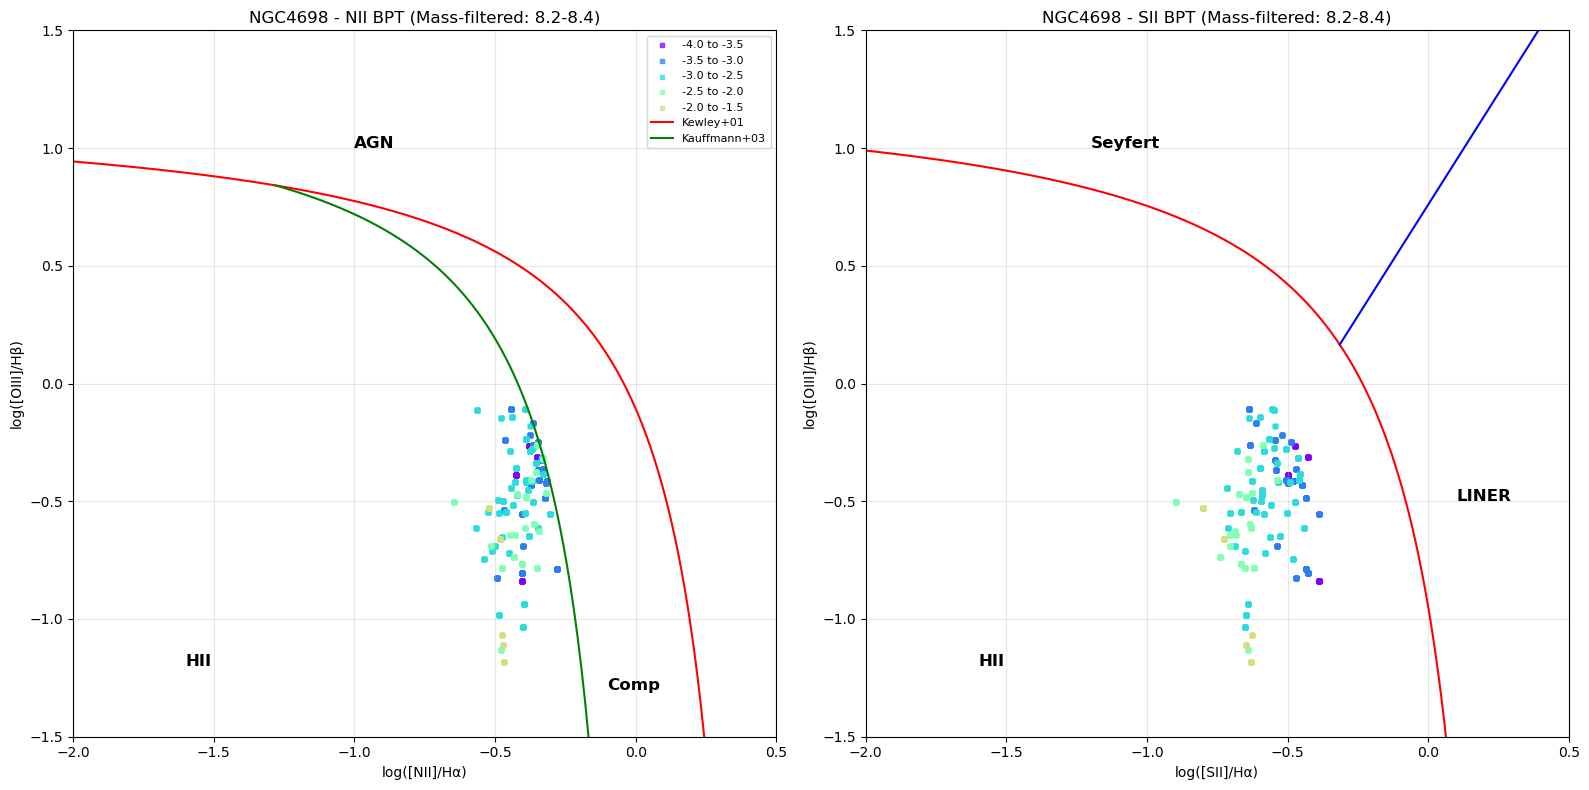


=== NGC4698 BPT Diagram Summary (Mass-filtered: 8.2-8.4) ===
Common valid spaxels (all 4 metallicity calibrations): 10042
Mass-filtered common spaxels: 1578
Mass filter efficiency: 15.7%

BPT classifications for mass-filtered common spaxels:
  N2 BPT - HII: 1578 (100.0%)
  N2 BPT - Comp: 0 (0.0%)
  N2 BPT - AGN: 0 (0.0%)
  N2 BPT - Total SF: 1578 (100.0%)
  S2 BPT - HII: 1578 (100.0%)
  S2 BPT - LINER: 0 (0.0%)
  S2 BPT - Seyfert: 0 (0.0%)
  S2 BPT - Total SF: 1578 (100.0%)

SFR bin breakdown for mass-filtered SF spaxels:
  Bin 0 (-4.0 to -3.5): N2_HII=84, S2_HII=84
  Bin 1 (-3.5 to -3.0): N2_HII=432, S2_HII=432
  Bin 2 (-3.0 to -2.5): N2_HII=673, S2_HII=673
  Bin 3 (-2.5 to -2.0): N2_HII=310, S2_HII=310
  Bin 4 (-2.0 to -1.5): N2_HII=79, S2_HII=79
  Bin 5 (-1.5 to -1.0): N2_HII=0, S2_HII=0
  Bin 6 (-1.0 to -0.5): N2_HII=0, S2_HII=0


In [23]:
# ------------------------------------------------------------------
# NGC4698 NII and SII BPT Diagrams for Common SF Spaxels Only (Mass-Filtered)
# Simple approach: Use corrected fluxes + common_mask + mass filter for SF spaxels
# Color-coded by SFR bins
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Define stellar mass surface density range filter
mass_min, mass_max = 8.2, 8.4
print(f"Filtering spaxels to stellar mass surface density range: {mass_min} to {mass_max}")

# Focus on NGC4698
gal = 'NGC4698'
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if gas_file.exists():
    # Load corrected emission line data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # Load corrected emission line fluxes
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    
    # Apply stellar mass surface density filter
    mass_filter = (logSigmaM >= mass_min) & (logSigmaM <= mass_max)
    
    # Combine common_mask with mass filter
    common_mass_mask = common_mask & mass_filter
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    print(f"Common valid pixels with mass filter ({mass_min}-{mass_max}): {np.sum(common_mass_mask)}")
    
    # Apply combined mask to corrected fluxes to get SF spaxels
    HB_common = HB4861_FLUX_corr[common_mass_mask]
    HA_common = HA6562_FLUX_corr[common_mass_mask]
    OIII_common = OIII5006_FLUX_corr[common_mass_mask]
    NII_common = NII6583_FLUX_corr[common_mass_mask]
    SII6716_common = SII6716_FLUX_corr[common_mass_mask]
    SII6730_common = SII6730_FLUX_corr[common_mass_mask]
    
    # Calculate line ratios for common mass-filtered SF spaxels
    logN2_common = np.log10(NII_common / HA_common)
    logO3_common = np.log10(OIII_common / HB_common)
    logS2_common = np.log10((SII6716_common + SII6730_common) / HA_common)
    
    # Get SFR values for common mass-filtered spaxels
    logSFR_common = logSigmaSFR[common_mass_mask]
    
    # Create SFR bins for color coding (same as cell 22)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Assign SFR bin indices to common mass-filtered SF spaxels
    sfr_bin_indices_common = np.full_like(logSFR_common, -1, dtype=int)  # -1 for non-assigned
    
    for i in range(n_bins):
        bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common < sfr_bin_edges[i+1])
        if i == n_bins - 1:  # Last bin includes the upper edge
            bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common <= sfr_bin_edges[i+1])
        sfr_bin_indices_common[bin_mask] = i
    
    # Apply BPT classifications to common mass-filtered SF spaxels
    # N2 BPT classifications
    mask_N2_HII_common = logO3_common <= kauff03_N2(logN2_common)
    mask_N2_Comp_common = (logO3_common > kauff03_N2(logN2_common)) & (logO3_common <= kewley01_N2(logN2_common))
    mask_N2_AGN_common = logO3_common > kewley01_N2(logN2_common)
    
    # S2 BPT classifications  
    mask_S2_HII_common = logO3_common <= kewley01_S2(logS2_common)
    mask_S2_above_kewley_common = logO3_common > kewley01_S2(logS2_common)
    mask_S2_LINER_common = mask_S2_above_kewley_common & (logO3_common <= kewley06_Sy_LIN(logS2_common))
    mask_S2_Seyfert_common = mask_S2_above_kewley_common & (logO3_common > kewley06_Sy_LIN(logS2_common))
    
    # Define SF masks for common mass-filtered spaxels
    mask_HII_N2_common = mask_N2_HII_common | mask_N2_Comp_common
    mask_HII_S2_common = mask_S2_HII_common
    
    # Create BPT diagrams
    plt.figure(figsize=(16, 8))
    
    # Define colors for SFR bins (rainbow colormap)
    cmap_rainbow = plt.cm.rainbow
    colors = [cmap_rainbow(i / (n_bins - 1)) for i in range(n_bins)]
    
    # NII BPT Diagram
    plt.subplot(1, 2, 1)
    
    # Plot only SF spaxels from common mass-filtered mask, color-coded by SFR bins
    for i in range(n_bins):
        bin_sf_mask = mask_HII_N2_common & (sfr_bin_indices_common == i)
        if np.sum(bin_sf_mask) > 0:
            plt.scatter(logN2_common[bin_sf_mask], logO3_common[bin_sf_mask], 
                       color=colors[i], 
                       label=f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}', 
                       marker=',', s=8, alpha=0.7)
    
    # Plot reference lines
    plt.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
    plt.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')
    
    # Calculate statistics
    total_common = len(logN2_common)
    sf_count_N2 = np.sum(mask_HII_N2_common)
    sf_percent_N2 = sf_count_N2 / total_common * 100 if total_common > 0 else 0
       
    plt.xlabel('log([NII]/Hα)')
    plt.ylabel('log([OIII]/Hβ)')
    plt.xlim(-2.0, 0.5)
    plt.ylim(-1.5, 1.5)
    plt.title(f'{gal} - NII BPT (Mass-filtered: {mass_min}-{mass_max})')
    plt.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
    plt.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
    plt.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # SII BPT Diagram
    plt.subplot(1, 2, 2)
    
    # Plot only SF spaxels from common mass-filtered mask, color-coded by SFR bins
    for i in range(n_bins):
        bin_sf_mask = mask_HII_S2_common & (sfr_bin_indices_common == i)
        if np.sum(bin_sf_mask) > 0:
            plt.scatter(logS2_common[bin_sf_mask], logO3_common[bin_sf_mask], 
                       color=colors[i], 
                       label=f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}', 
                       marker=',', s=8, alpha=0.7)
    
    # Plot reference lines
    plt.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5, label='Kewley+01')
    plt.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5, label='Kewley+06')
    
    # Calculate statistics
    sf_count_S2 = np.sum(mask_HII_S2_common)
    sf_percent_S2 = sf_count_S2 / total_common * 100 if total_common > 0 else 0
    
    plt.xlabel('log([SII]/Hα)')
    plt.ylabel('log([OIII]/Hβ)')
    plt.xlim(-2.0, 0.5)
    plt.ylim(-1.5, 1.5)
    plt.title(f'{gal} - SII BPT (Mass-filtered: {mass_min}-{mass_max})')
    plt.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
    plt.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
    plt.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {gal} BPT Diagram Summary (Mass-filtered: {mass_min}-{mass_max}) ===")
    print(f"Common valid spaxels (all 4 metallicity calibrations): {np.sum(common_mask)}")
    print(f"Mass-filtered common spaxels: {total_common}")
    print(f"Mass filter efficiency: {total_common/np.sum(common_mask)*100:.1f}%")
    print(f"\nBPT classifications for mass-filtered common spaxels:")
    print(f"  N2 BPT - HII: {np.sum(mask_N2_HII_common)} ({np.sum(mask_N2_HII_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Comp: {np.sum(mask_N2_Comp_common)} ({np.sum(mask_N2_Comp_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - AGN: {np.sum(mask_N2_AGN_common)} ({np.sum(mask_N2_AGN_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Total SF: {sf_count_N2} ({sf_percent_N2:.1f}%)")
    print(f"  S2 BPT - HII: {np.sum(mask_S2_HII_common)} ({np.sum(mask_S2_HII_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - LINER: {np.sum(mask_S2_LINER_common)} ({np.sum(mask_S2_LINER_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Seyfert: {np.sum(mask_S2_Seyfert_common)} ({np.sum(mask_S2_Seyfert_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Total SF: {sf_count_S2} ({sf_percent_S2:.1f}%)")
    
    # Print SFR bin breakdown for SF spaxels
    print(f"\nSFR bin breakdown for mass-filtered SF spaxels:")
    for i in range(n_bins):
        bin_sf_n2 = np.sum(mask_HII_N2_common & (sfr_bin_indices_common == i))
        bin_sf_s2 = np.sum(mask_HII_S2_common & (sfr_bin_indices_common == i))
        print(f"  Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}): N2_HII={bin_sf_n2}, S2_HII={bin_sf_s2}")
    
else:
    print(f"Gas emission line file not found for {gal}")

Filtering spaxels to stellar mass surface density range: 8.9 to 9.1
Total pixels: 722912
Common valid pixels across all calibrations: 10042
Common valid pixels with mass filter (8.9-9.1): 9


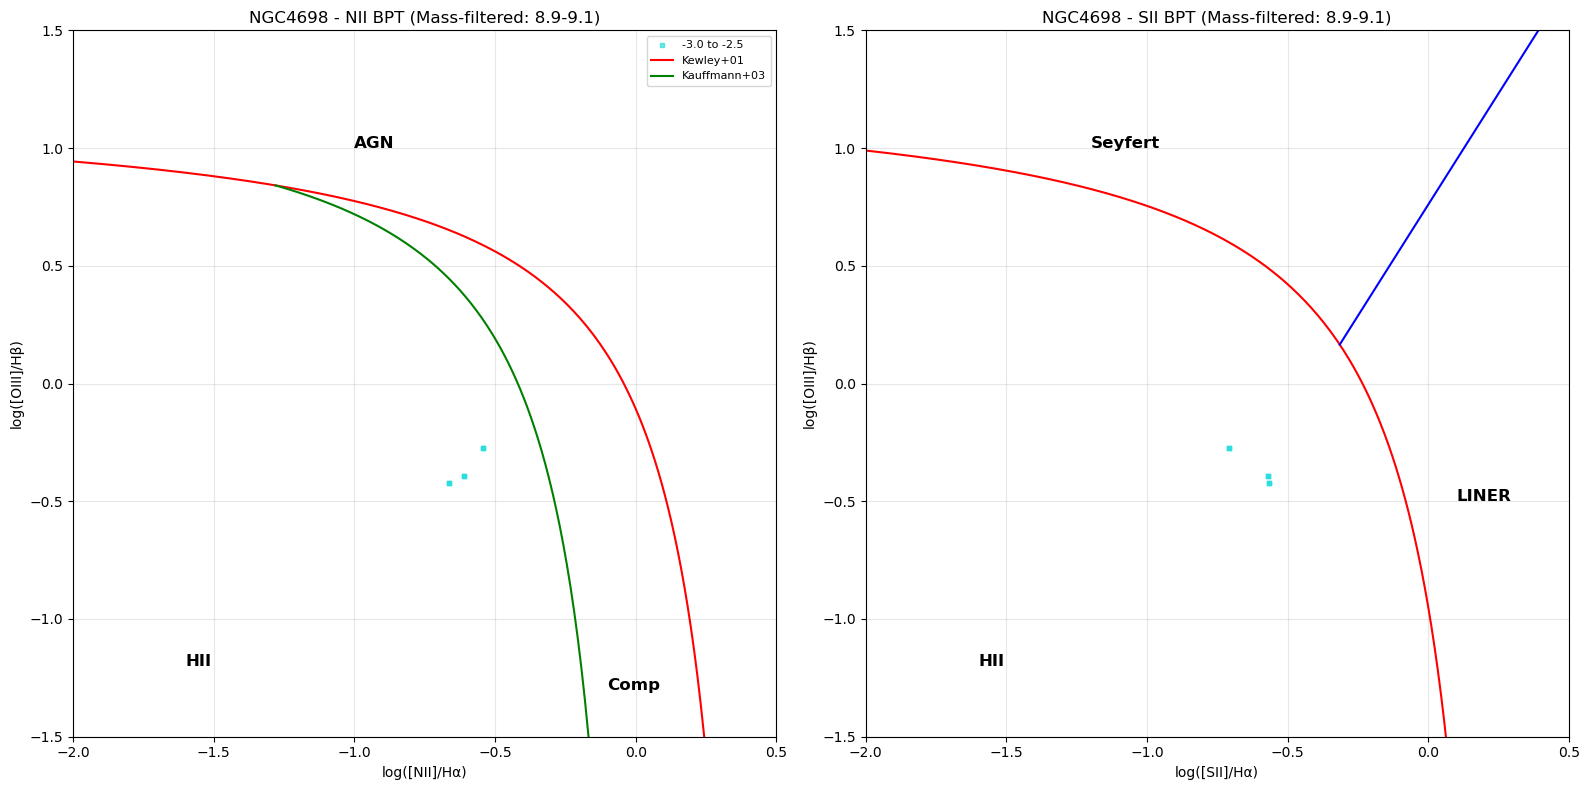


=== NGC4698 BPT Diagram Summary (Mass-filtered: 8.9-9.1) ===
Common valid spaxels (all 4 metallicity calibrations): 10042
Mass-filtered common spaxels: 9
Mass filter efficiency: 0.1%

BPT classifications for mass-filtered common spaxels:
  N2 BPT - HII: 9 (100.0%)
  N2 BPT - Comp: 0 (0.0%)
  N2 BPT - AGN: 0 (0.0%)
  N2 BPT - Total SF: 9 (100.0%)
  S2 BPT - HII: 9 (100.0%)
  S2 BPT - LINER: 0 (0.0%)
  S2 BPT - Seyfert: 0 (0.0%)
  S2 BPT - Total SF: 9 (100.0%)

SFR bin breakdown for mass-filtered SF spaxels:
  Bin 0 (-4.0 to -3.5): N2_HII=0, S2_HII=0
  Bin 1 (-3.5 to -3.0): N2_HII=0, S2_HII=0
  Bin 2 (-3.0 to -2.5): N2_HII=9, S2_HII=9
  Bin 3 (-2.5 to -2.0): N2_HII=0, S2_HII=0
  Bin 4 (-2.0 to -1.5): N2_HII=0, S2_HII=0
  Bin 5 (-1.5 to -1.0): N2_HII=0, S2_HII=0
  Bin 6 (-1.0 to -0.5): N2_HII=0, S2_HII=0


In [24]:
# ------------------------------------------------------------------
# NGC4698 NII and SII BPT Diagrams for Common SF Spaxels Only (Mass-Filtered)
# Simple approach: Use corrected fluxes + common_mask + mass filter for SF spaxels
# Color-coded by SFR bins
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Define stellar mass surface density range filter
mass_min, mass_max = 8.9, 9.1
print(f"Filtering spaxels to stellar mass surface density range: {mass_min} to {mass_max}")

# Focus on NGC4698
gal = 'NGC4698'
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if gas_file.exists():
    # Load corrected emission line data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # Load corrected emission line fluxes
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    
    # Apply stellar mass surface density filter
    mass_filter = (logSigmaM >= mass_min) & (logSigmaM <= mass_max)
    
    # Combine common_mask with mass filter
    common_mass_mask = common_mask & mass_filter
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid pixels across all calibrations: {np.sum(common_mask)}")
    print(f"Common valid pixels with mass filter ({mass_min}-{mass_max}): {np.sum(common_mass_mask)}")
    
    # Apply combined mask to corrected fluxes to get SF spaxels
    HB_common = HB4861_FLUX_corr[common_mass_mask]
    HA_common = HA6562_FLUX_corr[common_mass_mask]
    OIII_common = OIII5006_FLUX_corr[common_mass_mask]
    NII_common = NII6583_FLUX_corr[common_mass_mask]
    SII6716_common = SII6716_FLUX_corr[common_mass_mask]
    SII6730_common = SII6730_FLUX_corr[common_mass_mask]
    
    # Calculate line ratios for common mass-filtered SF spaxels
    logN2_common = np.log10(NII_common / HA_common)
    logO3_common = np.log10(OIII_common / HB_common)
    logS2_common = np.log10((SII6716_common + SII6730_common) / HA_common)
    
    # Get SFR values for common mass-filtered spaxels
    logSFR_common = logSigmaSFR[common_mass_mask]
    
    # Create SFR bins for color coding (same as cell 22)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Assign SFR bin indices to common mass-filtered SF spaxels
    sfr_bin_indices_common = np.full_like(logSFR_common, -1, dtype=int)  # -1 for non-assigned
    
    for i in range(n_bins):
        bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common < sfr_bin_edges[i+1])
        if i == n_bins - 1:  # Last bin includes the upper edge
            bin_mask = (logSFR_common >= sfr_bin_edges[i]) & (logSFR_common <= sfr_bin_edges[i+1])
        sfr_bin_indices_common[bin_mask] = i
    
    # Apply BPT classifications to common mass-filtered SF spaxels
    # N2 BPT classifications
    mask_N2_HII_common = logO3_common <= kauff03_N2(logN2_common)
    mask_N2_Comp_common = (logO3_common > kauff03_N2(logN2_common)) & (logO3_common <= kewley01_N2(logN2_common))
    mask_N2_AGN_common = logO3_common > kewley01_N2(logN2_common)
    
    # S2 BPT classifications  
    mask_S2_HII_common = logO3_common <= kewley01_S2(logS2_common)
    mask_S2_above_kewley_common = logO3_common > kewley01_S2(logS2_common)
    mask_S2_LINER_common = mask_S2_above_kewley_common & (logO3_common <= kewley06_Sy_LIN(logS2_common))
    mask_S2_Seyfert_common = mask_S2_above_kewley_common & (logO3_common > kewley06_Sy_LIN(logS2_common))
    
    # Define SF masks for common mass-filtered spaxels
    mask_HII_N2_common = mask_N2_HII_common | mask_N2_Comp_common
    mask_HII_S2_common = mask_S2_HII_common
    
    # Create BPT diagrams
    plt.figure(figsize=(16, 8))
    
    # Define colors for SFR bins (rainbow colormap)
    cmap_rainbow = plt.cm.rainbow
    colors = [cmap_rainbow(i / (n_bins - 1)) for i in range(n_bins)]
    
    # NII BPT Diagram
    plt.subplot(1, 2, 1)
    
    # Plot only SF spaxels from common mass-filtered mask, color-coded by SFR bins
    for i in range(n_bins):
        bin_sf_mask = mask_HII_N2_common & (sfr_bin_indices_common == i)
        if np.sum(bin_sf_mask) > 0:
            plt.scatter(logN2_common[bin_sf_mask], logO3_common[bin_sf_mask], 
                       color=colors[i], 
                       label=f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}', 
                       marker=',', s=8, alpha=0.7)
    
    # Plot reference lines
    plt.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
    plt.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')
    
    # Calculate statistics
    total_common = len(logN2_common)
    sf_count_N2 = np.sum(mask_HII_N2_common)
    sf_percent_N2 = sf_count_N2 / total_common * 100 if total_common > 0 else 0
       
    plt.xlabel('log([NII]/Hα)')
    plt.ylabel('log([OIII]/Hβ)')
    plt.xlim(-2.0, 0.5)
    plt.ylim(-1.5, 1.5)
    plt.title(f'{gal} - NII BPT (Mass-filtered: {mass_min}-{mass_max})')
    plt.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
    plt.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
    plt.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # SII BPT Diagram
    plt.subplot(1, 2, 2)
    
    # Plot only SF spaxels from common mass-filtered mask, color-coded by SFR bins
    for i in range(n_bins):
        bin_sf_mask = mask_HII_S2_common & (sfr_bin_indices_common == i)
        if np.sum(bin_sf_mask) > 0:
            plt.scatter(logS2_common[bin_sf_mask], logO3_common[bin_sf_mask], 
                       color=colors[i], 
                       label=f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}', 
                       marker=',', s=8, alpha=0.7)
    
    # Plot reference lines
    plt.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5, label='Kewley+01')
    plt.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5, label='Kewley+06')
    
    # Calculate statistics
    sf_count_S2 = np.sum(mask_HII_S2_common)
    sf_percent_S2 = sf_count_S2 / total_common * 100 if total_common > 0 else 0
    
    plt.xlabel('log([SII]/Hα)')
    plt.ylabel('log([OIII]/Hβ)')
    plt.xlim(-2.0, 0.5)
    plt.ylim(-1.5, 1.5)
    plt.title(f'{gal} - SII BPT (Mass-filtered: {mass_min}-{mass_max})')
    plt.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
    plt.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
    plt.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {gal} BPT Diagram Summary (Mass-filtered: {mass_min}-{mass_max}) ===")
    print(f"Common valid spaxels (all 4 metallicity calibrations): {np.sum(common_mask)}")
    print(f"Mass-filtered common spaxels: {total_common}")
    print(f"Mass filter efficiency: {total_common/np.sum(common_mask)*100:.1f}%")
    print(f"\nBPT classifications for mass-filtered common spaxels:")
    print(f"  N2 BPT - HII: {np.sum(mask_N2_HII_common)} ({np.sum(mask_N2_HII_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Comp: {np.sum(mask_N2_Comp_common)} ({np.sum(mask_N2_Comp_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - AGN: {np.sum(mask_N2_AGN_common)} ({np.sum(mask_N2_AGN_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Total SF: {sf_count_N2} ({sf_percent_N2:.1f}%)")
    print(f"  S2 BPT - HII: {np.sum(mask_S2_HII_common)} ({np.sum(mask_S2_HII_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - LINER: {np.sum(mask_S2_LINER_common)} ({np.sum(mask_S2_LINER_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Seyfert: {np.sum(mask_S2_Seyfert_common)} ({np.sum(mask_S2_Seyfert_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Total SF: {sf_count_S2} ({sf_percent_S2:.1f}%)")
    
    # Print SFR bin breakdown for SF spaxels
    print(f"\nSFR bin breakdown for mass-filtered SF spaxels:")
    for i in range(n_bins):
        bin_sf_n2 = np.sum(mask_HII_N2_common & (sfr_bin_indices_common == i))
        bin_sf_s2 = np.sum(mask_HII_S2_common & (sfr_bin_indices_common == i))
        print(f"  Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}): N2_HII={bin_sf_n2}, S2_HII={bin_sf_s2}")
    
else:
    print(f"Gas emission line file not found for {gal}")

## 20250924 Comparison of SF regions and HII regions

SFR bin edges: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5]
Number of bins: 7

Total SF region spaxels: 34620
HII region spaxels shown: 10038 (29.0%)

SFR bin information for NGC4698 (HII regions only):
  Bin 0: -4.0 to -3.5 - 633 pixels
  Bin 1: -3.5 to -3.0 - 2625 pixels
  Bin 2: -3.0 to -2.5 - 4676 pixels
  Bin 3: -2.5 to -2.0 - 1900 pixels
  Bin 4: -2.0 to -1.5 - 204 pixels
  Bin 5: -1.5 to -1.0 - 0 pixels
  Bin 6: -1.0 to -0.5 - 0 pixels


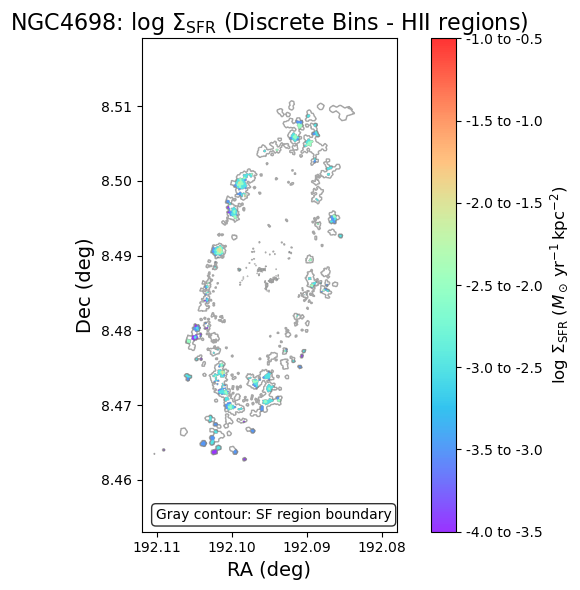

In [25]:
# ------------------------------------------------------------------
# 0.  List galaxies and pin one colour to each
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = ['NGC4698']        # auto-detect
cmap   = plt.get_cmap('tab20').colors                      # 20 hues
colour = {g: cmap[i % len(cmap)] for i, g in enumerate(galaxies)}

# ------------------------------------------------------------------
# 1.  Helper: read the two maps
# ------------------------------------------------------------------
def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
        mass_header = h['LOGMASS_SURFACE_DENSITY'].header
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data  # For HII regions (colored map)
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data    # For SF regions (contour)
        gas_header = h['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR_HII, sigSFR_SF, wcs, mass_header, gas_header

# Update the code to show only the middle panel (SFR map) with discrete bins
for gal in galaxies:
    sigM, sigSFR_HII, sigSFR_SF, wcs, mass_header, gas_header = load_maps(gal)
    good = np.isfinite(sigM) & np.isfinite(sigSFR_HII)
    
    # Create galaxy outline mask for SF regions (using SF data, not HII data!)
    galaxy_outline_SF = np.isfinite(sigM) & np.isfinite(sigSFR_SF)

    # Convert pixel area to physical area in pc²
    legacy_wcs2 = WCS(gas_header).celestial  # strip spectral axis
    
    # Get the extent from WCS for proper coordinate axes
    y_size, x_size = sigM.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    # Convert pixel coordinates to world coordinates
    ra, dec = legacy_wcs2.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]  # [left, right, bottom, top]

    # Define discrete SFR bins: -4 to -0.5 with 0.5 bin width (7 bins)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    print(f"SFR bin edges: {sfr_bin_edges}")
    print(f"Number of bins: {n_bins}")
    
    # Create discrete SFR map based on HII region bins
    sfr_discrete = np.full_like(sigSFR_HII, np.nan)
    
    # Assign each pixel to its corresponding bin (using HII data)
    for i in range(n_bins):
        bin_mask = (sigSFR_HII >= sfr_bin_edges[i]) & (sigSFR_HII < sfr_bin_edges[i+1])
        sfr_discrete[bin_mask] = i  # Assign bin index
    
    # Handle the last bin edge (include pixels exactly at -0.5)
    last_bin_mask = sigSFR_HII >= sfr_bin_edges[-1]
    sfr_discrete[last_bin_mask] = n_bins - 1

    fig = plt.figure(figsize=(10, 6))

    # --- Discrete Σ_SFR map with SF region outline -----------------------------------------------
    ax = fig.add_subplot(1, 1, 1)
    
    # Use rainbow colormap for discrete bins
    cmap_rainbow = plt.cm.rainbow
    
    im = ax.imshow(sfr_discrete, origin='lower', cmap=cmap_rainbow, 
                   extent=extent, vmin=0, vmax=n_bins-1, alpha=0.8)
    
    # Add SF region outline contour (using SF data, not HII!)
    # Create contour levels for the SF region boundary
    contour_levels = [0.5]  # Single contour level to define the boundary
    
    # Convert SF region outline boolean to float for contouring
    galaxy_mask_SF_float = galaxy_outline_SF.astype(float)
    
    # Add gray contour to show the entire SF region
    # Use world coordinates (ra, dec) with proper origin='lower' to match imshow
    contours = ax.contour(ra, dec, galaxy_mask_SF_float, levels=contour_levels, 
                         colors='gray', linewidths=1, linestyles='-', 
                         origin='lower', alpha=0.7)
    
    ax.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (Discrete Bins - HII regions)', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    
    # Ensure RA axis increases from left to right
    # ax.invert_xaxis()
    
    # Create custom colorbar with discrete bins and labels
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Set discrete ticks and labels for the colorbar
    tick_positions = np.arange(n_bins)
    tick_labels = [f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}' for i in range(n_bins)]
    cbar.set_ticks(tick_positions)
    cbar.set_ticklabels(tick_labels)
    
    # Add text annotation to explain the gray contour
    ax.text(0.98, 0.02, 'Gray contour: SF region boundary', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Count total spaxels for comparison
    total_SF_spaxels = np.sum(galaxy_outline_SF)
    hii_spaxels = np.sum(np.isfinite(sfr_discrete))
    print(f"\nTotal SF region spaxels: {total_SF_spaxels}")
    print(f"HII region spaxels shown: {hii_spaxels} ({hii_spaxels/total_SF_spaxels*100:.1f}%)")
    
    # Print bin information
    print(f"\nSFR bin information for {gal} (HII regions only):")
    for i in range(n_bins):
        bin_mask = sfr_discrete == i
        n_pixels = np.sum(bin_mask)
        print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_HII_with_SF_contour.png', dpi=600)
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_HII_with_SF_contour.pdf')
    plt.show()

SFR bin edges: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5]
Number of bins: 7

Total SF region spaxels: 34620
SF region spaxels shown: 34426 (99.4%)
Total HII region spaxels (contour): 10181

SFR bin information for NGC4698 (SF regions shown as discrete bins):
  Bin 0: -4.0 to -3.5 - 7970 pixels
  Bin 1: -3.5 to -3.0 - 14734 pixels
  Bin 2: -3.0 to -2.5 - 9394 pixels
  Bin 3: -2.5 to -2.0 - 2124 pixels
  Bin 4: -2.0 to -1.5 - 204 pixels
  Bin 5: -1.5 to -1.0 - 0 pixels
  Bin 6: -1.0 to -0.5 - 0 pixels


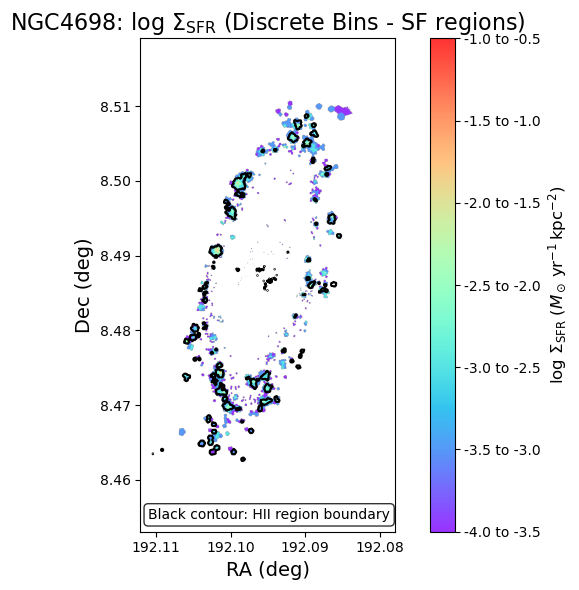

In [26]:
# ------------------------------------------------------------------
# 0.  List galaxies and pin one colour to each
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = ['NGC4698']        # auto-detect
cmap   = plt.get_cmap('tab20').colors                      # 20 hue
colour = {g: cmap[i % len(cmap)] for i, g in enumerate(galaxies)}

# ------------------------------------------------------------------
# 1.  Helper: read the two maps (same as before)
# ------------------------------------------------------------------
def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
        mass_header = h['LOGMASS_SURFACE_DENSITY'].header
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data  # For HII regions (contour this time)
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data    # For SF regions (colored map this time)
        gas_header = h['LOGSFR_SURFACE_DENSITY_SF'].header  # Use SF header this time
    return sigM, sigSFR_HII, sigSFR_SF, wcs, mass_header, gas_header

# OPPOSITE of previous cell: Show SF regions with discrete bins and HII regions as black contours
for gal in galaxies:
    sigM, sigSFR_HII, sigSFR_SF, wcs, mass_header, gas_header = load_maps(gal)
    good_SF = np.isfinite(sigM) & np.isfinite(sigSFR_SF)
    
    # Create HII region outline mask for contours
    galaxy_outline_HII = np.isfinite(sigM) & np.isfinite(sigSFR_HII)

    # Convert pixel area to physical area in pc²
    legacy_wcs2 = WCS(gas_header).celestial  # strip spectral axis
    
    # Get the extent from WCS for proper coordinate axes
    y_size, x_size = sigM.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    # Convert pixel coordinates to world coordinates
    ra, dec = legacy_wcs2.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]  # [left, right, bottom, top]

    # Define discrete SFR bins: -4 to -0.5 with 0.5 bin width (7 bins)
    sfr_bin_edges = np.arange(-4, 0, 0.5)  # This creates bins: [-4,-3.5), [-3.5,-3), [-3,-2.5), [-2.5,-2), [-2,-1.5), [-1.5,-1), [-1,-0.5)
    n_bins = len(sfr_bin_edges) - 1
    print(f"SFR bin edges: {sfr_bin_edges}")
    print(f"Number of bins: {n_bins}")
    
    # Create discrete SFR map based on SF region bins (NOT HII this time!)
    sfr_discrete_SF = np.full_like(sigSFR_SF, np.nan)
    
    # Assign each pixel to its corresponding bin (using SF data this time)
    for i in range(n_bins):
        bin_mask = (sigSFR_SF >= sfr_bin_edges[i]) & (sigSFR_SF < sfr_bin_edges[i+1])
        sfr_discrete_SF[bin_mask] = i  # Assign bin index
    
    # Handle the last bin edge (include pixels exactly at -0.5)
    last_bin_mask = sigSFR_SF >= sfr_bin_edges[-1]
    sfr_discrete_SF[last_bin_mask] = n_bins - 1

    fig = plt.figure(figsize=(10, 6))

    # --- Discrete Σ_SFR map (SF regions) with HII region outline -----------------------------------------------
    ax = fig.add_subplot(1, 1, 1)
    
    # Use rainbow colormap for discrete bins
    cmap_rainbow = plt.cm.rainbow
    
    im = ax.imshow(sfr_discrete_SF, origin='lower', cmap=cmap_rainbow, 
                   extent=extent, vmin=0, vmax=n_bins-1, alpha=0.8)
    
    # Add HII region outline contour (using HII data for contour)
    # Create contour levels for the HII region boundary
    contour_levels = [0.5]  # Single contour level to define the boundary
    
    # Convert HII region outline boolean to float for contouring
    galaxy_mask_HII_float = galaxy_outline_HII.astype(float)
    
    # Add BLACK contour to show the HII regions with alpha=1.0
    # Use world coordinates (ra, dec) with proper origin='lower' to match imshow
    contours = ax.contour(ra, dec, galaxy_mask_HII_float, levels=contour_levels, 
                         colors='black', linewidths=1.5, linestyles='-', 
                         origin='lower', alpha=1.0)
    
    ax.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (Discrete Bins - SF regions)', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    
    # Ensure RA axis increases from left to right
    # ax.invert_xaxis()
    
    # Create custom colorbar with discrete bins and labels
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Set discrete ticks and labels for the colorbar
    tick_positions = np.arange(n_bins)
    tick_labels = [f'{sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}' for i in range(n_bins)]
    cbar.set_ticks(tick_positions)
    cbar.set_ticklabels(tick_labels)
    
    # Add text annotation to explain the black contour
    ax.text(0.98, 0.02, 'Black contour: HII region boundary', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Count total spaxels for comparison
    total_SF_spaxels = np.sum(good_SF)
    sf_spaxels_shown = np.sum(np.isfinite(sfr_discrete_SF))
    total_HII_spaxels = np.sum(galaxy_outline_HII)
    print(f"\nTotal SF region spaxels: {total_SF_spaxels}")
    print(f"SF region spaxels shown: {sf_spaxels_shown} ({sf_spaxels_shown/total_SF_spaxels*100:.1f}%)")
    print(f"Total HII region spaxels (contour): {total_HII_spaxels}")
    
    # Print bin information
    print(f"\nSFR bin information for {gal} (SF regions shown as discrete bins):")
    for i in range(n_bins):
        bin_mask = sfr_discrete_SF == i
        n_pixels = np.sum(bin_mask)
        print(f"  Bin {i}: {sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f} - {n_pixels} pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_SF_with_HII_contour.png', dpi=600)
    # plt.savefig(f'{gal}_discrete_SFR_map_bins_SF_with_HII_contour.pdf')
    plt.show()

Total pixels: 722912
Common valid HII pixels across all calibrations: 10042
Common valid SF pixels across all calibrations: 34421
Using uniform y-axis range: 8.3 to 9.3

Processing D16 calibration for both HII and SF regions:
  HII D16 range: 8.274 to 9.219
  SF D16 range: 8.274 to 9.219
  Total valid bins - HII: 5, SF: 5

Processing PG16 calibration for both HII and SF regions:
  HII PG16 range: 7.645 to 8.689
  SF PG16 range: 7.645 to 8.787
  Total valid bins - HII: 5, SF: 5

Processing O3N2-M13 calibration for both HII and SF regions:
  HII O3N2-M13 range: 8.297 to 8.778
  SF O3N2-M13 range: 8.297 to 8.778
  Total valid bins - HII: 5, SF: 5

Processing O3N2-C20 calibration for both HII and SF regions:
  HII O3N2-C20 range: 8.500 to 8.956
  SF O3N2-C20 range: 8.500 to 8.956
  Total valid bins - HII: 5, SF: 5


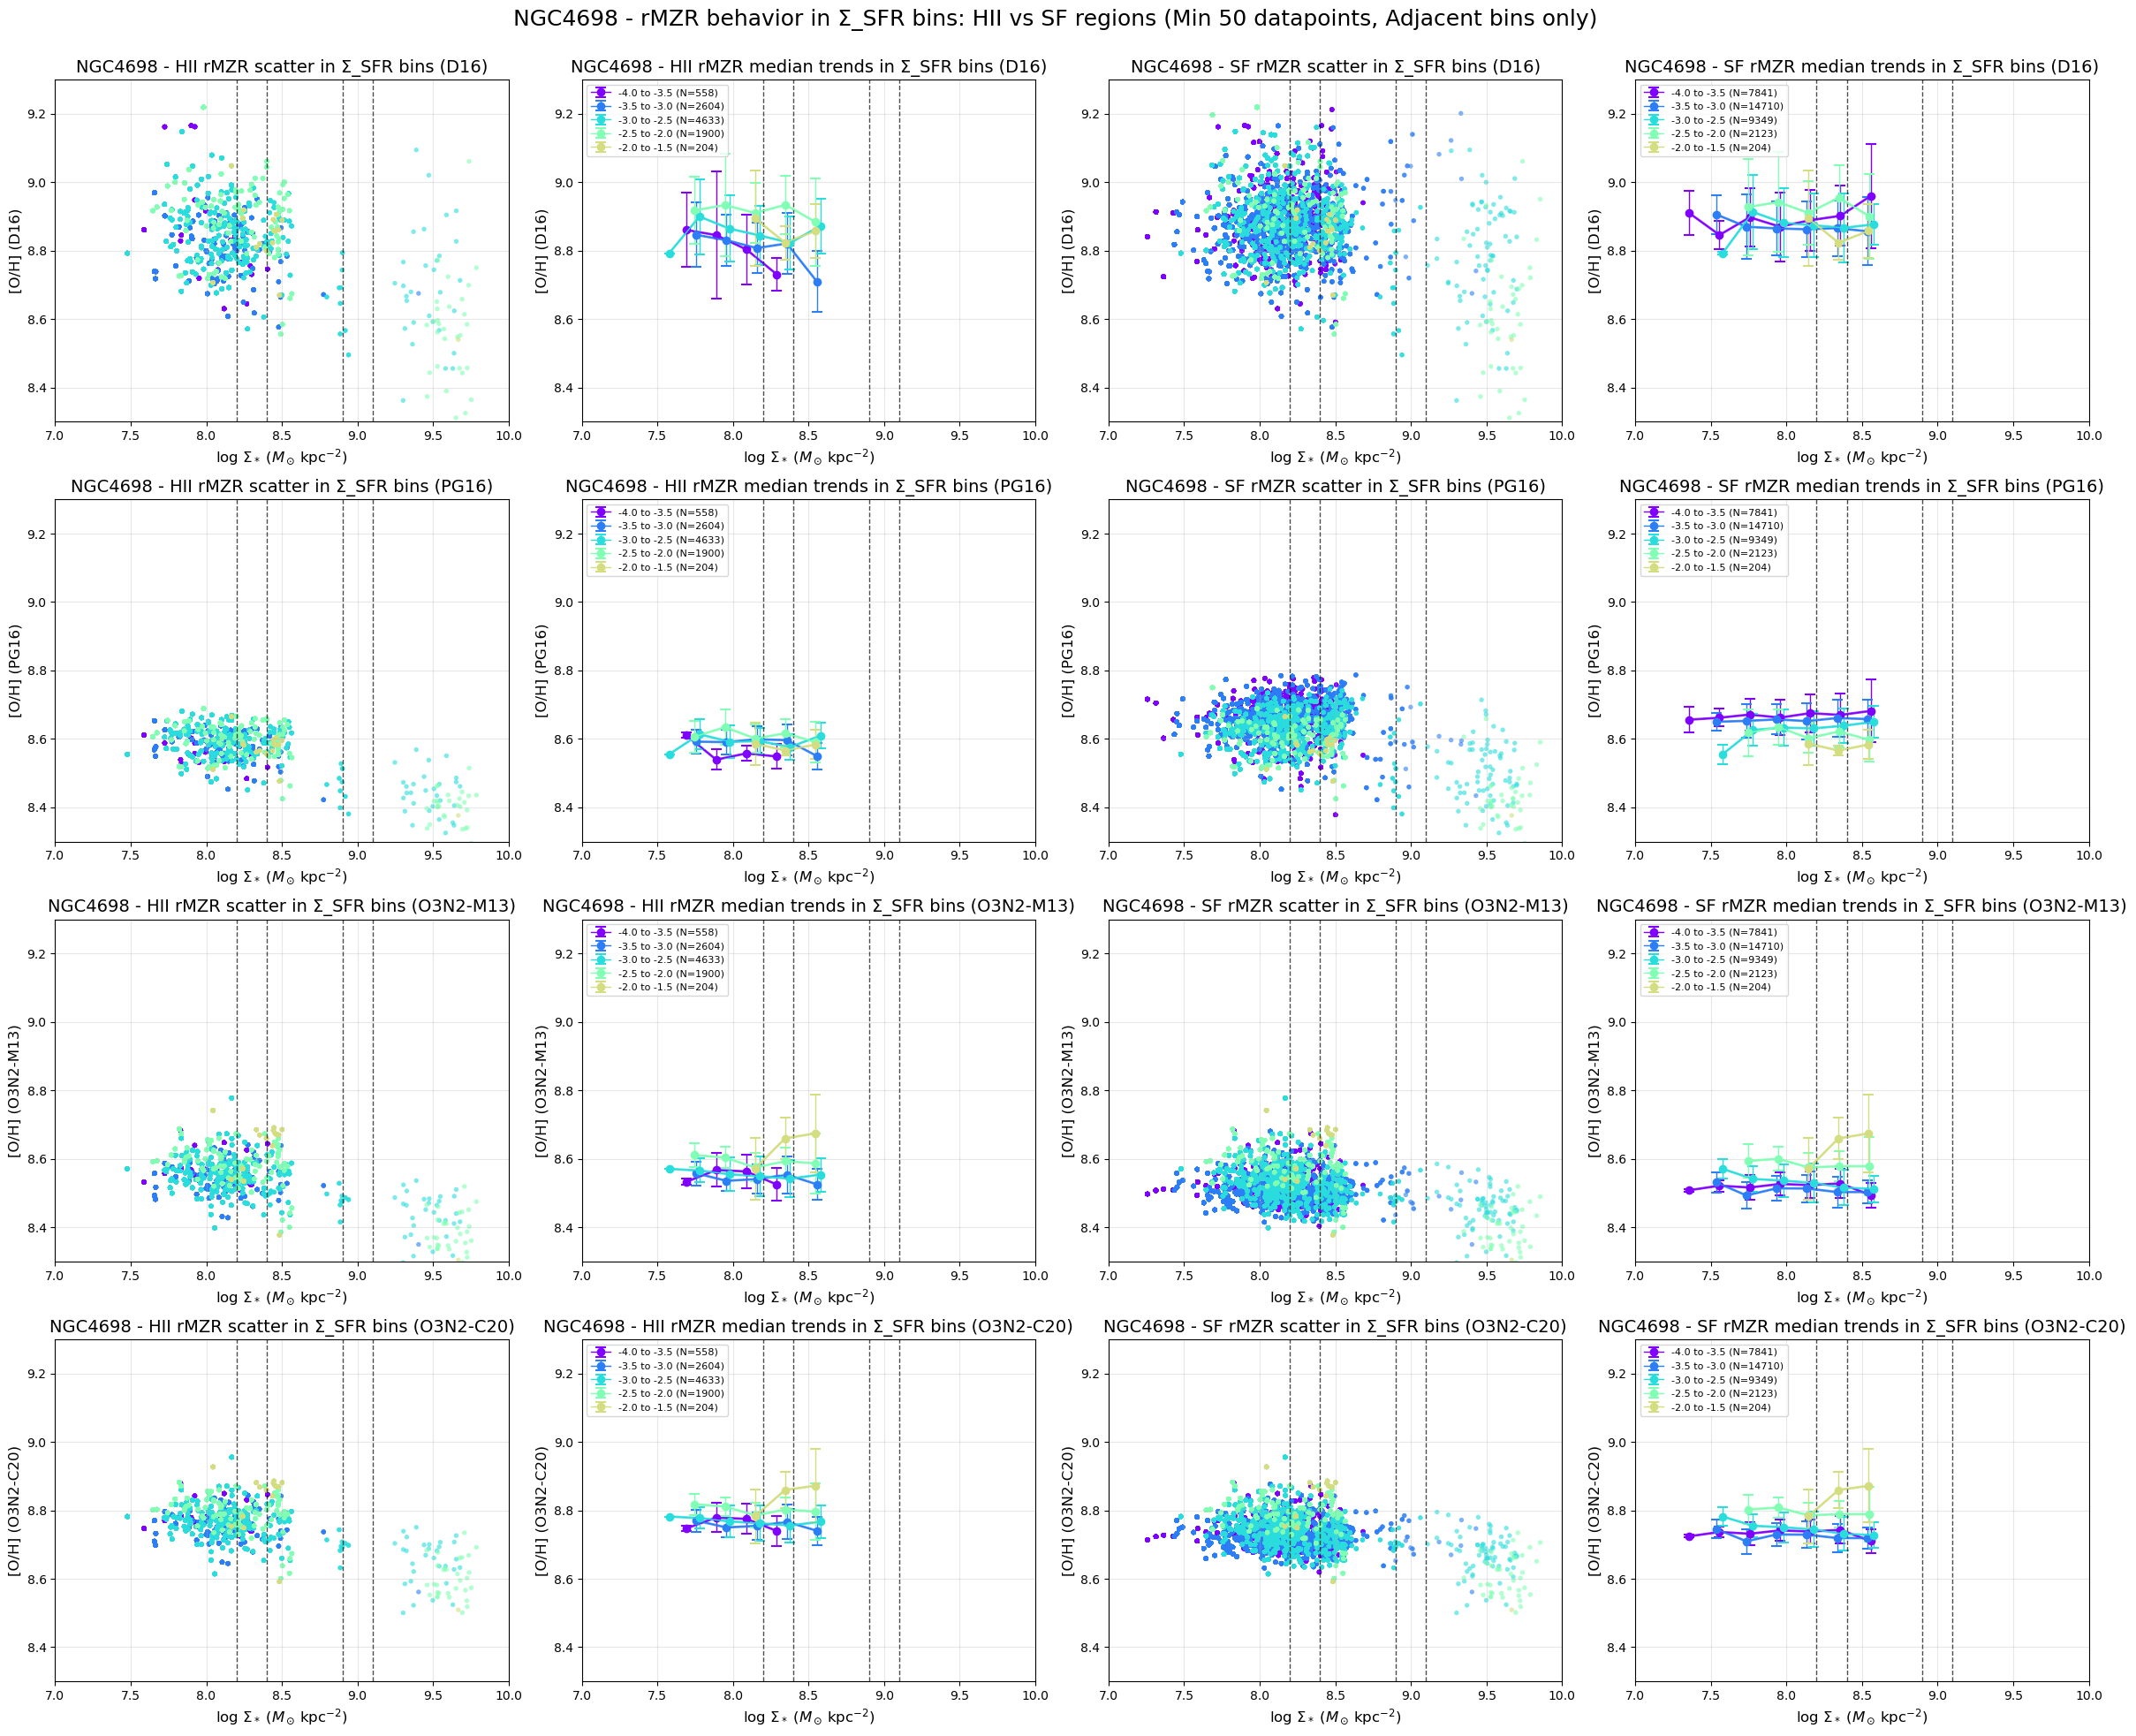


Successfully created combined 4x4 subplot figure showing both HII and SF regions
Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)
Using uniform y-axis range: 8.3 to 9.3
Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins


In [27]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - Combined scatter plots and median trends
# 4 rows x 4 columns: HII regions (scatter + median) + SF regions (scatter + median)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.8)

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data for both HII and SF regions
    (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
     logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = load_maps_all_calibrations(gal)

    # Find common spaxels for HII regions
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    # Find common spaxels for SF regions
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid HII pixels across all calibrations: {np.sum(common_mask_HII)}")
    print(f"Common valid SF pixels across all calibrations: {np.sum(common_mask_SF)}")

    # Define Σ_SFR bins: -4 to 0.0 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.0, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Set uniform y-axis range
    common_ylim = (8.3, 9.3)
    
    # Define vertical line positions
    vline_positions = [8.2, 8.4, 8.9, 9.1]
    
    print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
    
    # Create figure with 4 rows x 4 columns 
    # Columns: HII scatter, HII median, SF scatter, SF median
    fig, axes = plt.subplots(4, 4, figsize=(24, 20))
    
    # Data for each calibration
    calibrations_HII = [
        (oh_d16_HII, 'D16'),
        (oh_pg16_HII, 'PG16'),
        (oh_o3n2_m13_HII, 'O3N2-M13'),
        (oh_o3n2_c20_HII, 'O3N2-C20')
    ]
    
    calibrations_SF = [
        (oh_d16_SF, 'D16'),
        (oh_pg16_SF, 'PG16'),
        (oh_o3n2_m13_SF, 'O3N2-M13'),
        (oh_o3n2_c20_SF, 'O3N2-C20')
    ]
    
    # Process each calibration (one row per calibration)
    for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
        print(f"\nProcessing {calib_name_HII} calibration for both HII and SF regions:")
        
        # Get axes for this row
        ax_scatter_HII = axes[row_idx, 0]  # Column 0: HII scatter plots
        ax_median_HII = axes[row_idx, 1]   # Column 1: HII median trends
        ax_scatter_SF = axes[row_idx, 2]   # Column 2: SF scatter plots
        ax_median_SF = axes[row_idx, 3]    # Column 3: SF median trends
        
        # Process HII regions (columns 0 and 1)
        logSigmaSFR_HII_good = logSigmaSFR_HII[common_mask_HII]
        logSigmaM_HII_good = logSigmaM[common_mask_HII]
        oh_HII_good = oh_data_HII[common_mask_HII]
        
        print(f"  HII {calib_name_HII} range: {np.min(oh_HII_good):.3f} to {np.max(oh_HII_good):.3f}")
        
        # Process SF regions (columns 2 and 3)
        logSigmaSFR_SF_good = logSigmaSFR_SF[common_mask_SF]
        logSigmaM_SF_good = logSigmaM[common_mask_SF]
        oh_SF_good = oh_data_SF[common_mask_SF]
        
        print(f"  SF {calib_name_SF} range: {np.min(oh_SF_good):.3f} to {np.max(oh_SF_good):.3f}")
        
        # Plot each Σ_SFR bin for both HII and SF regions
        valid_bins_HII = 0
        valid_bins_SF = 0
        
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # HII regions processing
            in_bin_HII = (logSigmaSFR_HII_good >= bin_start) & (logSigmaSFR_HII_good < bin_end)
            n_pixels_HII = np.sum(in_bin_HII)
            
            if n_pixels_HII >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_HII = logSigmaM_HII_good[in_bin_HII]
                y_bin_HII = oh_HII_good[in_bin_HII]
                
                # HII Scatter plot (column 0)
                ax_scatter_HII.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                     label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})',
                                     edgecolors='none')
                
                # HII Median trends (column 1)
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                    x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_HII) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_HII, mass_centers_HII, medians_HII, stds_HII, 
                        valid_bin_indices_HII, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})')
                    valid_bins_HII += 1
            
            # SF regions processing
            in_bin_SF = (logSigmaSFR_SF_good >= bin_start) & (logSigmaSFR_SF_good < bin_end)
            n_pixels_SF = np.sum(in_bin_SF)
            
            if n_pixels_SF >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_SF = logSigmaM_SF_good[in_bin_SF]
                y_bin_SF = oh_SF_good[in_bin_SF]
                
                # SF Scatter plot (column 2)
                ax_scatter_SF.scatter(x_bin_SF, y_bin_SF, c=[colors[i]], s=15, alpha=0.6, 
                                    label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})',
                                    edgecolors='none')
                
                # SF Median trends (column 3)
                mass_centers_SF, medians_SF, stds_SF, counts_SF, valid_bin_indices_SF = calculate_binned_stats(
                    x_bin_SF, y_bin_SF, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_SF) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_SF, mass_centers_SF, medians_SF, stds_SF, 
                        valid_bin_indices_SF, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})')
                    valid_bins_SF += 1
        
        # Add vertical dashed lines to all four plots in this row
        for vline_x in vline_positions:
            ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_scatter_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        
        # Format HII scatter plot (column 0)
        ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_scatter_HII.set_title(f'{gal} - HII rMZR scatter in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_scatter_HII.grid(True, alpha=0.3)
        ax_scatter_HII.set_xlim(7, 10)
        ax_scatter_HII.set_ylim(common_ylim)
        
        # Format HII median trends plot (column 1)
        ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_median_HII.set_title(f'{gal} - HII rMZR median trends in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_median_HII.grid(True, alpha=0.3)
        ax_median_HII.set_xlim(7, 10)
        ax_median_HII.set_ylim(common_ylim)
        ax_median_HII.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        # Format SF scatter plot (column 2)
        ax_scatter_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_scatter_SF.set_title(f'{gal} - SF rMZR scatter in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_scatter_SF.grid(True, alpha=0.3)
        ax_scatter_SF.set_xlim(7, 10)
        ax_scatter_SF.set_ylim(common_ylim)
        
        # Format SF median trends plot (column 3)
        ax_median_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_median_SF.set_title(f'{gal} - SF rMZR median trends in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_median_SF.grid(True, alpha=0.3)
        ax_median_SF.set_xlim(7, 10)
        ax_median_SF.set_ylim(common_ylim)
        ax_median_SF.legend(fontsize=8, loc='upper left', framealpha=0.8)
        
        print(f"  Total valid bins - HII: {valid_bins_HII}, SF: {valid_bins_SF}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins: HII vs SF regions (Min 50 datapoints, Adjacent bins only)', 
                 fontsize=18, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 4x4 subplot figure showing both HII and SF regions")
print(f"Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)")
print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
print(f"Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins")

Total pixels: 722912
Common valid SF pixels across all calibrations: 34421

Processing D16 calibration:
  D16 range: 8.274 to 9.219
  Total SF spaxels: 34421
  N2 SF classification: 34421 (100.0%)
  S2 SF classification: 34421 (100.0%)

Processing PG16 calibration:
  PG16 range: 7.645 to 8.787
  Total SF spaxels: 34421
  N2 SF classification: 34421 (100.0%)
  S2 SF classification: 34421 (100.0%)

Processing O3N2-M13 calibration:
  O3N2-M13 range: 8.297 to 8.778
  Total SF spaxels: 34421
  N2 SF classification: 34421 (100.0%)
  S2 SF classification: 34421 (100.0%)

Processing O3N2-C20 calibration:
  O3N2-C20 range: 8.500 to 8.956
  Total SF spaxels: 34421
  N2 SF classification: 34421 (100.0%)
  S2 SF classification: 34421 (100.0%)


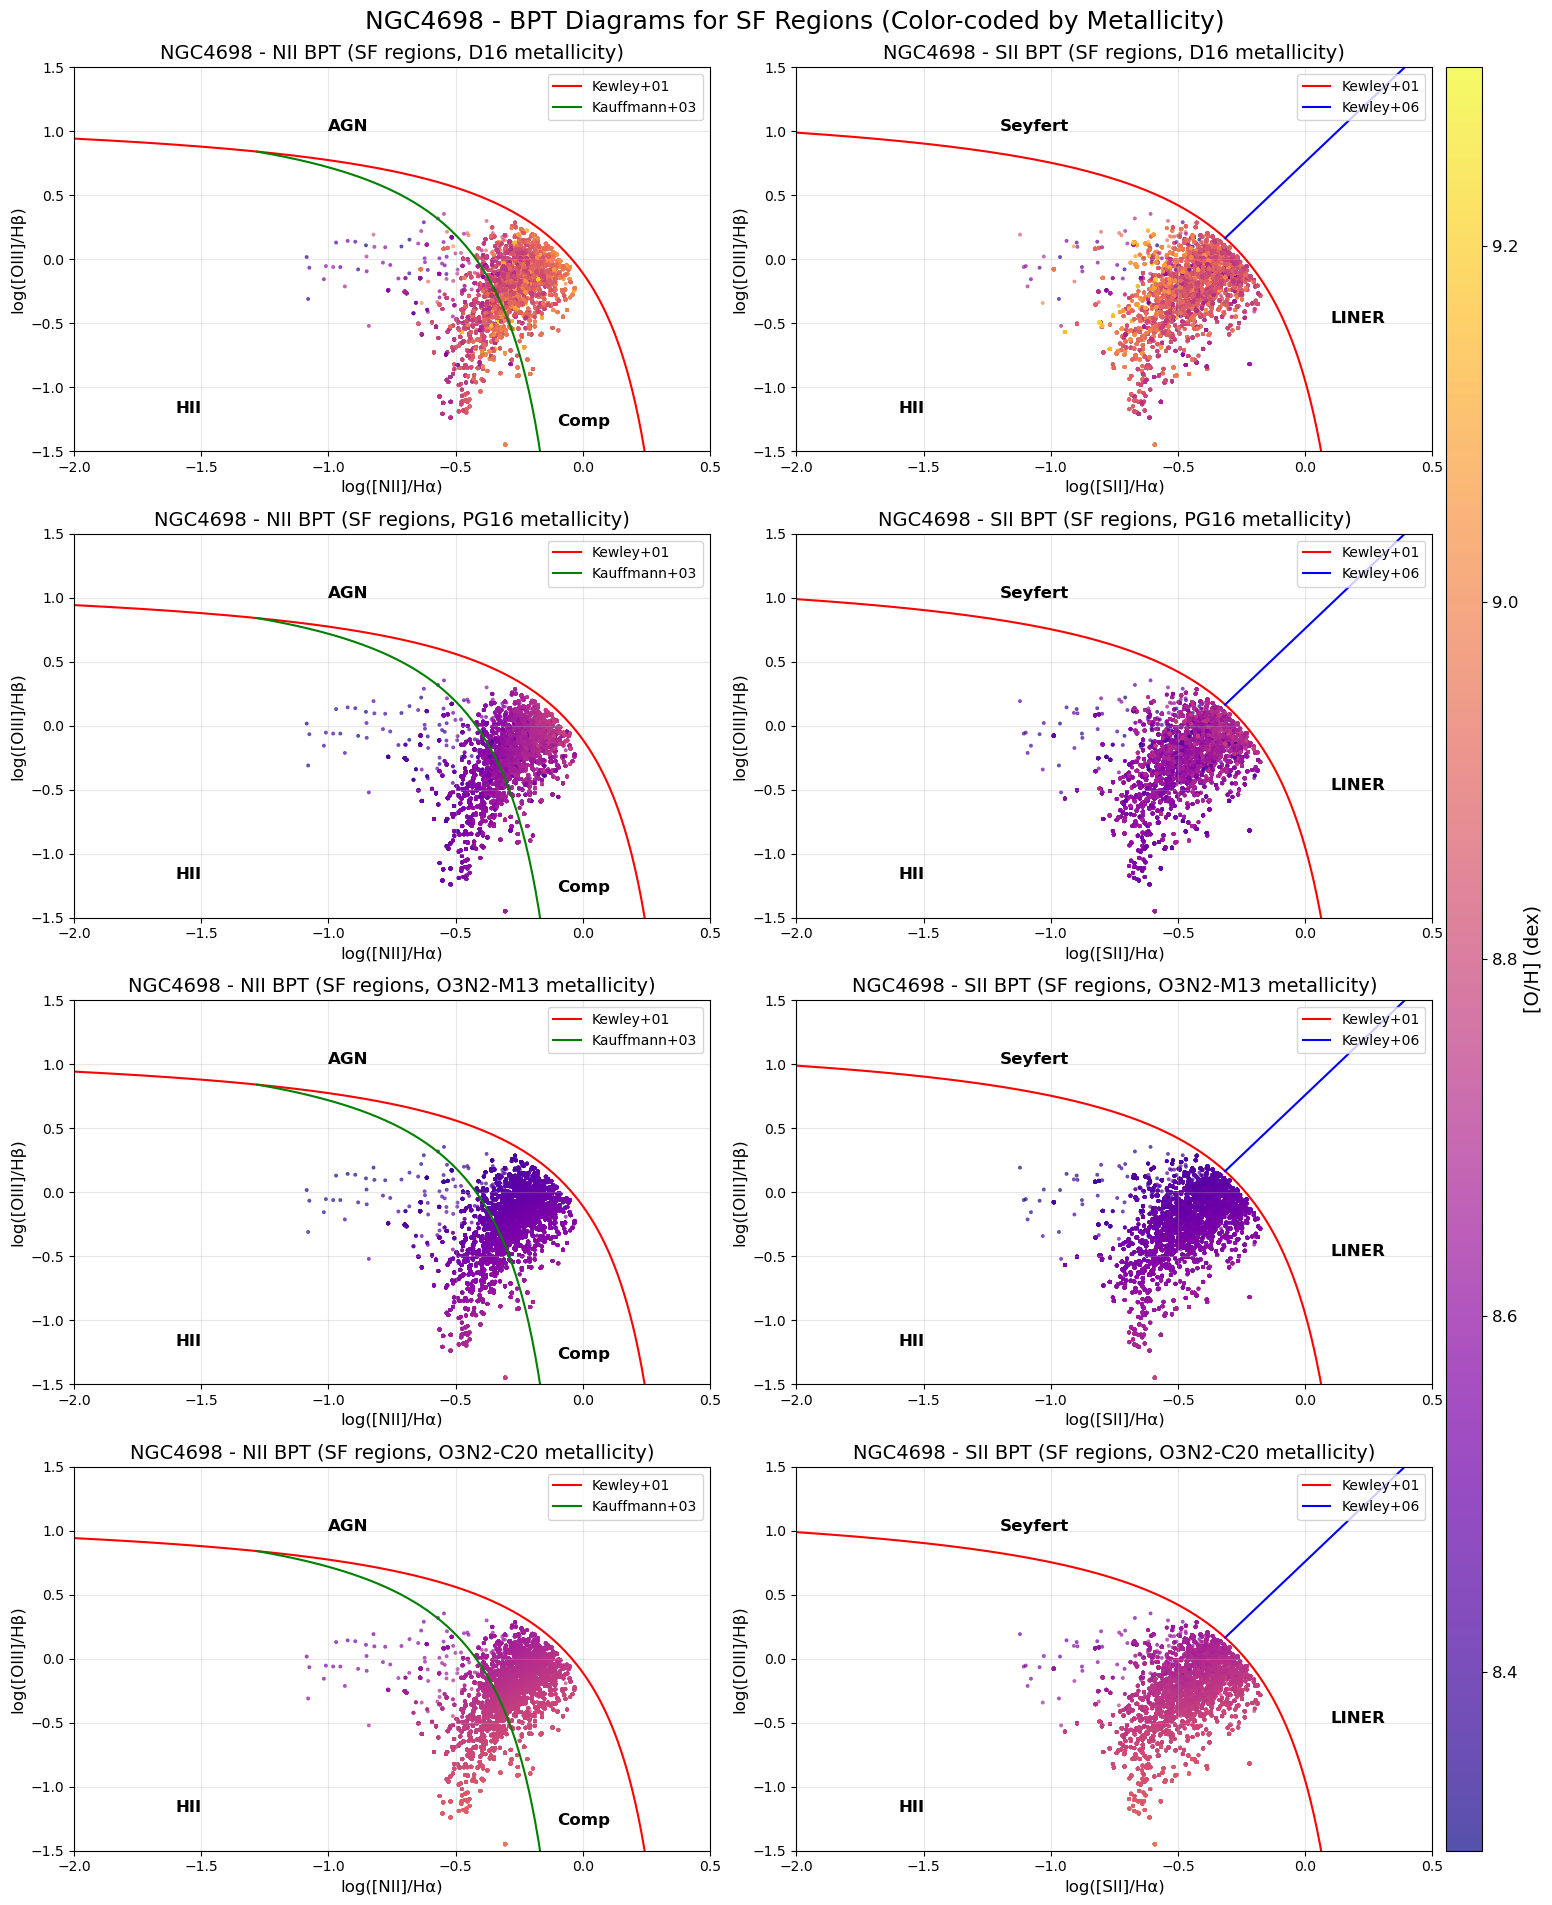


=== NGC4698 BPT Diagram Summary (SF regions only) ===
Common valid SF spaxels (all 4 metallicity calibrations + emission lines): 34421

BPT classifications for common SF spaxels:
  N2 BPT - HII: 10042 (29.2%)
  N2 BPT - Comp: 24379 (70.8%)
  N2 BPT - AGN: 0 (0.0%)
  N2 BPT - Total SF: 34421 (100.0%)
  S2 BPT - HII: 34421 (100.0%)
  S2 BPT - LINER: 0 (0.0%)
  S2 BPT - Seyfert: 0 (0.0%)
  S2 BPT - Total SF: 34421 (100.0%)

Using shared metallicity colorbar range: 8.3 to 9.3
Colormap: plasma


In [28]:
# ------------------------------------------------------------------
# NGC4698 NII and SII BPT Diagrams for SF Regions
# Color-coded by metallicity for each calibration (4 rows)
# Shared colorbar range: 8.2-9.3, using plasma colormap
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Focus on NGC4698
gal = 'NGC4698'
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if gas_file.exists():
    # Load corrected emission line data and all metallicity calibrations for SF regions
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # Load corrected emission line fluxes
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
        
        # Load SF region metallicity calibrations
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    
    # Find common spaxels for SF regions (same as previous cell)
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                      np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                      np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                      np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid SF pixels across all calibrations: {np.sum(common_mask_SF)}")
    
    # Apply common_mask_SF to corrected fluxes to get SF spaxels
    HB_common = HB4861_FLUX_corr[common_mask_SF]
    HA_common = HA6562_FLUX_corr[common_mask_SF]
    OIII_common = OIII5006_FLUX_corr[common_mask_SF]
    NII_common = NII6583_FLUX_corr[common_mask_SF]
    SII6716_common = SII6716_FLUX_corr[common_mask_SF]
    SII6730_common = SII6730_FLUX_corr[common_mask_SF]
    
    # Calculate line ratios for common SF spaxels
    logN2_common = np.log10(NII_common / HA_common)
    logO3_common = np.log10(OIII_common / HB_common)
    logS2_common = np.log10((SII6716_common + SII6730_common) / HA_common)
    
    # Get metallicity values for common SF spaxels
    oh_d16_common = oh_d16_SF[common_mask_SF]
    oh_pg16_common = oh_pg16_SF[common_mask_SF]
    oh_o3n2_m13_common = oh_o3n2_m13_SF[common_mask_SF]
    oh_o3n2_c20_common = oh_o3n2_c20_SF[common_mask_SF]
    
    # Apply BPT classifications to common SF spaxels
    # N2 BPT classifications
    mask_N2_HII_common = logO3_common <= kauff03_N2(logN2_common)
    mask_N2_Comp_common = (logO3_common > kauff03_N2(logN2_common)) & (logO3_common <= kewley01_N2(logN2_common))
    mask_N2_AGN_common = logO3_common > kewley01_N2(logN2_common)
    
    # S2 BPT classifications  
    mask_S2_HII_common = logO3_common <= kewley01_S2(logS2_common)
    mask_S2_above_kewley_common = logO3_common > kewley01_S2(logS2_common)
    mask_S2_LINER_common = mask_S2_above_kewley_common & (logO3_common <= kewley06_Sy_LIN(logS2_common))
    mask_S2_Seyfert_common = mask_S2_above_kewley_common & (logO3_common > kewley06_Sy_LIN(logS2_common))
    
    # Define SF masks for common spaxels
    mask_HII_N2_common = mask_N2_HII_common | mask_N2_Comp_common
    mask_HII_S2_common = mask_S2_HII_common
    
    # Define metallicity range and colormap
    met_vmin, met_vmax = 8.3, 9.3
    cmap_plasma = plt.cm.plasma
    
    # Metallicity calibrations data
    calibrations_data = [
        (oh_d16_common, 'D16'),
        (oh_pg16_common, 'PG16'),
        (oh_o3n2_m13_common, 'O3N2-M13'),
        (oh_o3n2_c20_common, 'O3N2-C20')
    ]
    
    # Create BPT diagrams - 4 rows x 2 columns
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    
    # Process each metallicity calibration (one row per calibration)
    for row_idx, (oh_data, calib_name) in enumerate(calibrations_data):
        print(f"\nProcessing {calib_name} calibration:")
        print(f"  {calib_name} range: {np.min(oh_data):.3f} to {np.max(oh_data):.3f}")
        
        # Get axes for this row
        ax_n2 = axes[row_idx, 0]  # NII BPT
        ax_s2 = axes[row_idx, 1]  # SII BPT
        
        # NII BPT Diagram (left column)
        # Plot all SF spaxels, color-coded by metallicity
        scatter_n2 = ax_n2.scatter(logN2_common, logO3_common, 
                                  c=oh_data, cmap=cmap_plasma, 
                                  vmin=met_vmin, vmax=met_vmax,
                                  s=8, alpha=0.7, edgecolors='none')
        
        # Plot reference lines
        ax_n2.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
        ax_n2.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')
        
        # Format NII BPT
        ax_n2.set_xlabel('log([NII]/Hα)', fontsize=12)
        ax_n2.set_ylabel('log([OIII]/Hβ)', fontsize=12)
        ax_n2.set_xlim(-2.0, 0.5)
        ax_n2.set_ylim(-1.5, 1.5)
        ax_n2.set_title(f'{gal} - NII BPT (SF regions, {calib_name} metallicity)', fontsize=14)
        ax_n2.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
        ax_n2.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
        ax_n2.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
        ax_n2.legend(loc='upper right', fontsize=10)
        ax_n2.grid(True, alpha=0.3)
        
        # SII BPT Diagram (right column)
        # Plot all SF spaxels, color-coded by metallicity
        scatter_s2 = ax_s2.scatter(logS2_common, logO3_common, 
                                  c=oh_data, cmap=cmap_plasma, 
                                  vmin=met_vmin, vmax=met_vmax,
                                  s=8, alpha=0.7, edgecolors='none')
        
        # Plot reference lines
        ax_s2.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5, label='Kewley+01')
        ax_s2.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5, label='Kewley+06')
        
        # Format SII BPT
        ax_s2.set_xlabel('log([SII]/Hα)', fontsize=12)
        ax_s2.set_ylabel('log([OIII]/Hβ)', fontsize=12)
        ax_s2.set_xlim(-2.0, 0.5)
        ax_s2.set_ylim(-1.5, 1.5)
        ax_s2.set_title(f'{gal} - SII BPT (SF regions, {calib_name} metallicity)', fontsize=14)
        ax_s2.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
        ax_s2.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
        ax_s2.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
        ax_s2.legend(loc='upper right', fontsize=10)
        ax_s2.grid(True, alpha=0.3)
        
        # Calculate statistics for this calibration
        total_spaxels = len(oh_data)
        sf_count_N2 = np.sum(mask_HII_N2_common)
        sf_count_S2 = np.sum(mask_HII_S2_common)
        print(f"  Total SF spaxels: {total_spaxels}")
        print(f"  N2 SF classification: {sf_count_N2} ({sf_count_N2/total_spaxels*100:.1f}%)")
        print(f"  S2 SF classification: {sf_count_S2} ({sf_count_S2/total_spaxels*100:.1f}%)")
        
        # Add overall title
        fig.suptitle(f'{gal} - BPT Diagrams for SF Regions (Color-coded by Metallicity)', 
                 fontsize=18, y=0.95)
    
    # Add shared colorbar - positioned at far right, full height
    plt.tight_layout(rect=[0, 0, 0.95, 0.96])  # Apply tight_layout first

    # Create colorbar with proper positioning
    cbar = fig.colorbar(
        scatter_n2,                # any one of your scatters
        ax=axes,                   # attach to ALL subplots
        location='right',
        pad=0.01,                  # increase gap between subplots and colorbar
        fraction=0.03,             # colorbar thickness (relative to figure width)
        shrink=1.0,                # full height of all 4 rows
        aspect=50                  # make colorbar taller/thinner
    )
    cbar.set_label('[O/H] (dex)', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    plt.show()
    
    # Print summary statistics
    total_common = np.sum(common_mask_SF)
    print(f"\n=== {gal} BPT Diagram Summary (SF regions only) ===")
    print(f"Common valid SF spaxels (all 4 metallicity calibrations + emission lines): {total_common}")
    print(f"\nBPT classifications for common SF spaxels:")
    print(f"  N2 BPT - HII: {np.sum(mask_N2_HII_common)} ({np.sum(mask_N2_HII_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Comp: {np.sum(mask_N2_Comp_common)} ({np.sum(mask_N2_Comp_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - AGN: {np.sum(mask_N2_AGN_common)} ({np.sum(mask_N2_AGN_common)/total_common*100:.1f}%)")
    print(f"  N2 BPT - Total SF: {np.sum(mask_HII_N2_common)} ({np.sum(mask_HII_N2_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - HII: {np.sum(mask_S2_HII_common)} ({np.sum(mask_S2_HII_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - LINER: {np.sum(mask_S2_LINER_common)} ({np.sum(mask_S2_LINER_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Seyfert: {np.sum(mask_S2_Seyfert_common)} ({np.sum(mask_S2_Seyfert_common)/total_common*100:.1f}%)")
    print(f"  S2 BPT - Total SF: {np.sum(mask_HII_S2_common)} ({np.sum(mask_HII_S2_common)/total_common*100:.1f}%)")
    
    print(f"\nUsing shared metallicity colorbar range: {met_vmin:.1f} to {met_vmax:.1f}")
    print(f"Colormap: plasma")
    
else:
    print(f"Gas emission line file not found for {gal}")

## 20250925 Check N2S2 calibration

Total pixels: 722912
Common valid HII pixels across all calibrations: 10040
Common valid SF pixels across all calibrations: 34411
Using uniform y-axis range: 8.3 to 9.3

Processing D16 calibration for both HII and SF regions:
  HII D16 range: 8.274 to 9.219
  SF D16 range: 8.274 to 9.219
  Total valid bins - HII: 5, SF: 5

Processing PG16 calibration for both HII and SF regions:
  HII PG16 range: 7.645 to 8.689
  SF PG16 range: 7.645 to 8.787
  Total valid bins - HII: 5, SF: 5

Processing N2S2-N06 calibration for both HII and SF regions:
  HII N2S2-N06 range: 8.664 to 9.309
  SF N2S2-N06 range: 8.664 to 9.309
  Total valid bins - HII: 5, SF: 5

Processing O3N2-M13 calibration for both HII and SF regions:
  HII O3N2-M13 range: 8.297 to 8.778
  SF O3N2-M13 range: 8.297 to 8.778
  Total valid bins - HII: 5, SF: 5

Processing O3N2-C20 calibration for both HII and SF regions:
  HII O3N2-C20 range: 8.500 to 8.956
  SF O3N2-C20 range: 8.500 to 8.956
  Total valid bins - HII: 5, SF: 5


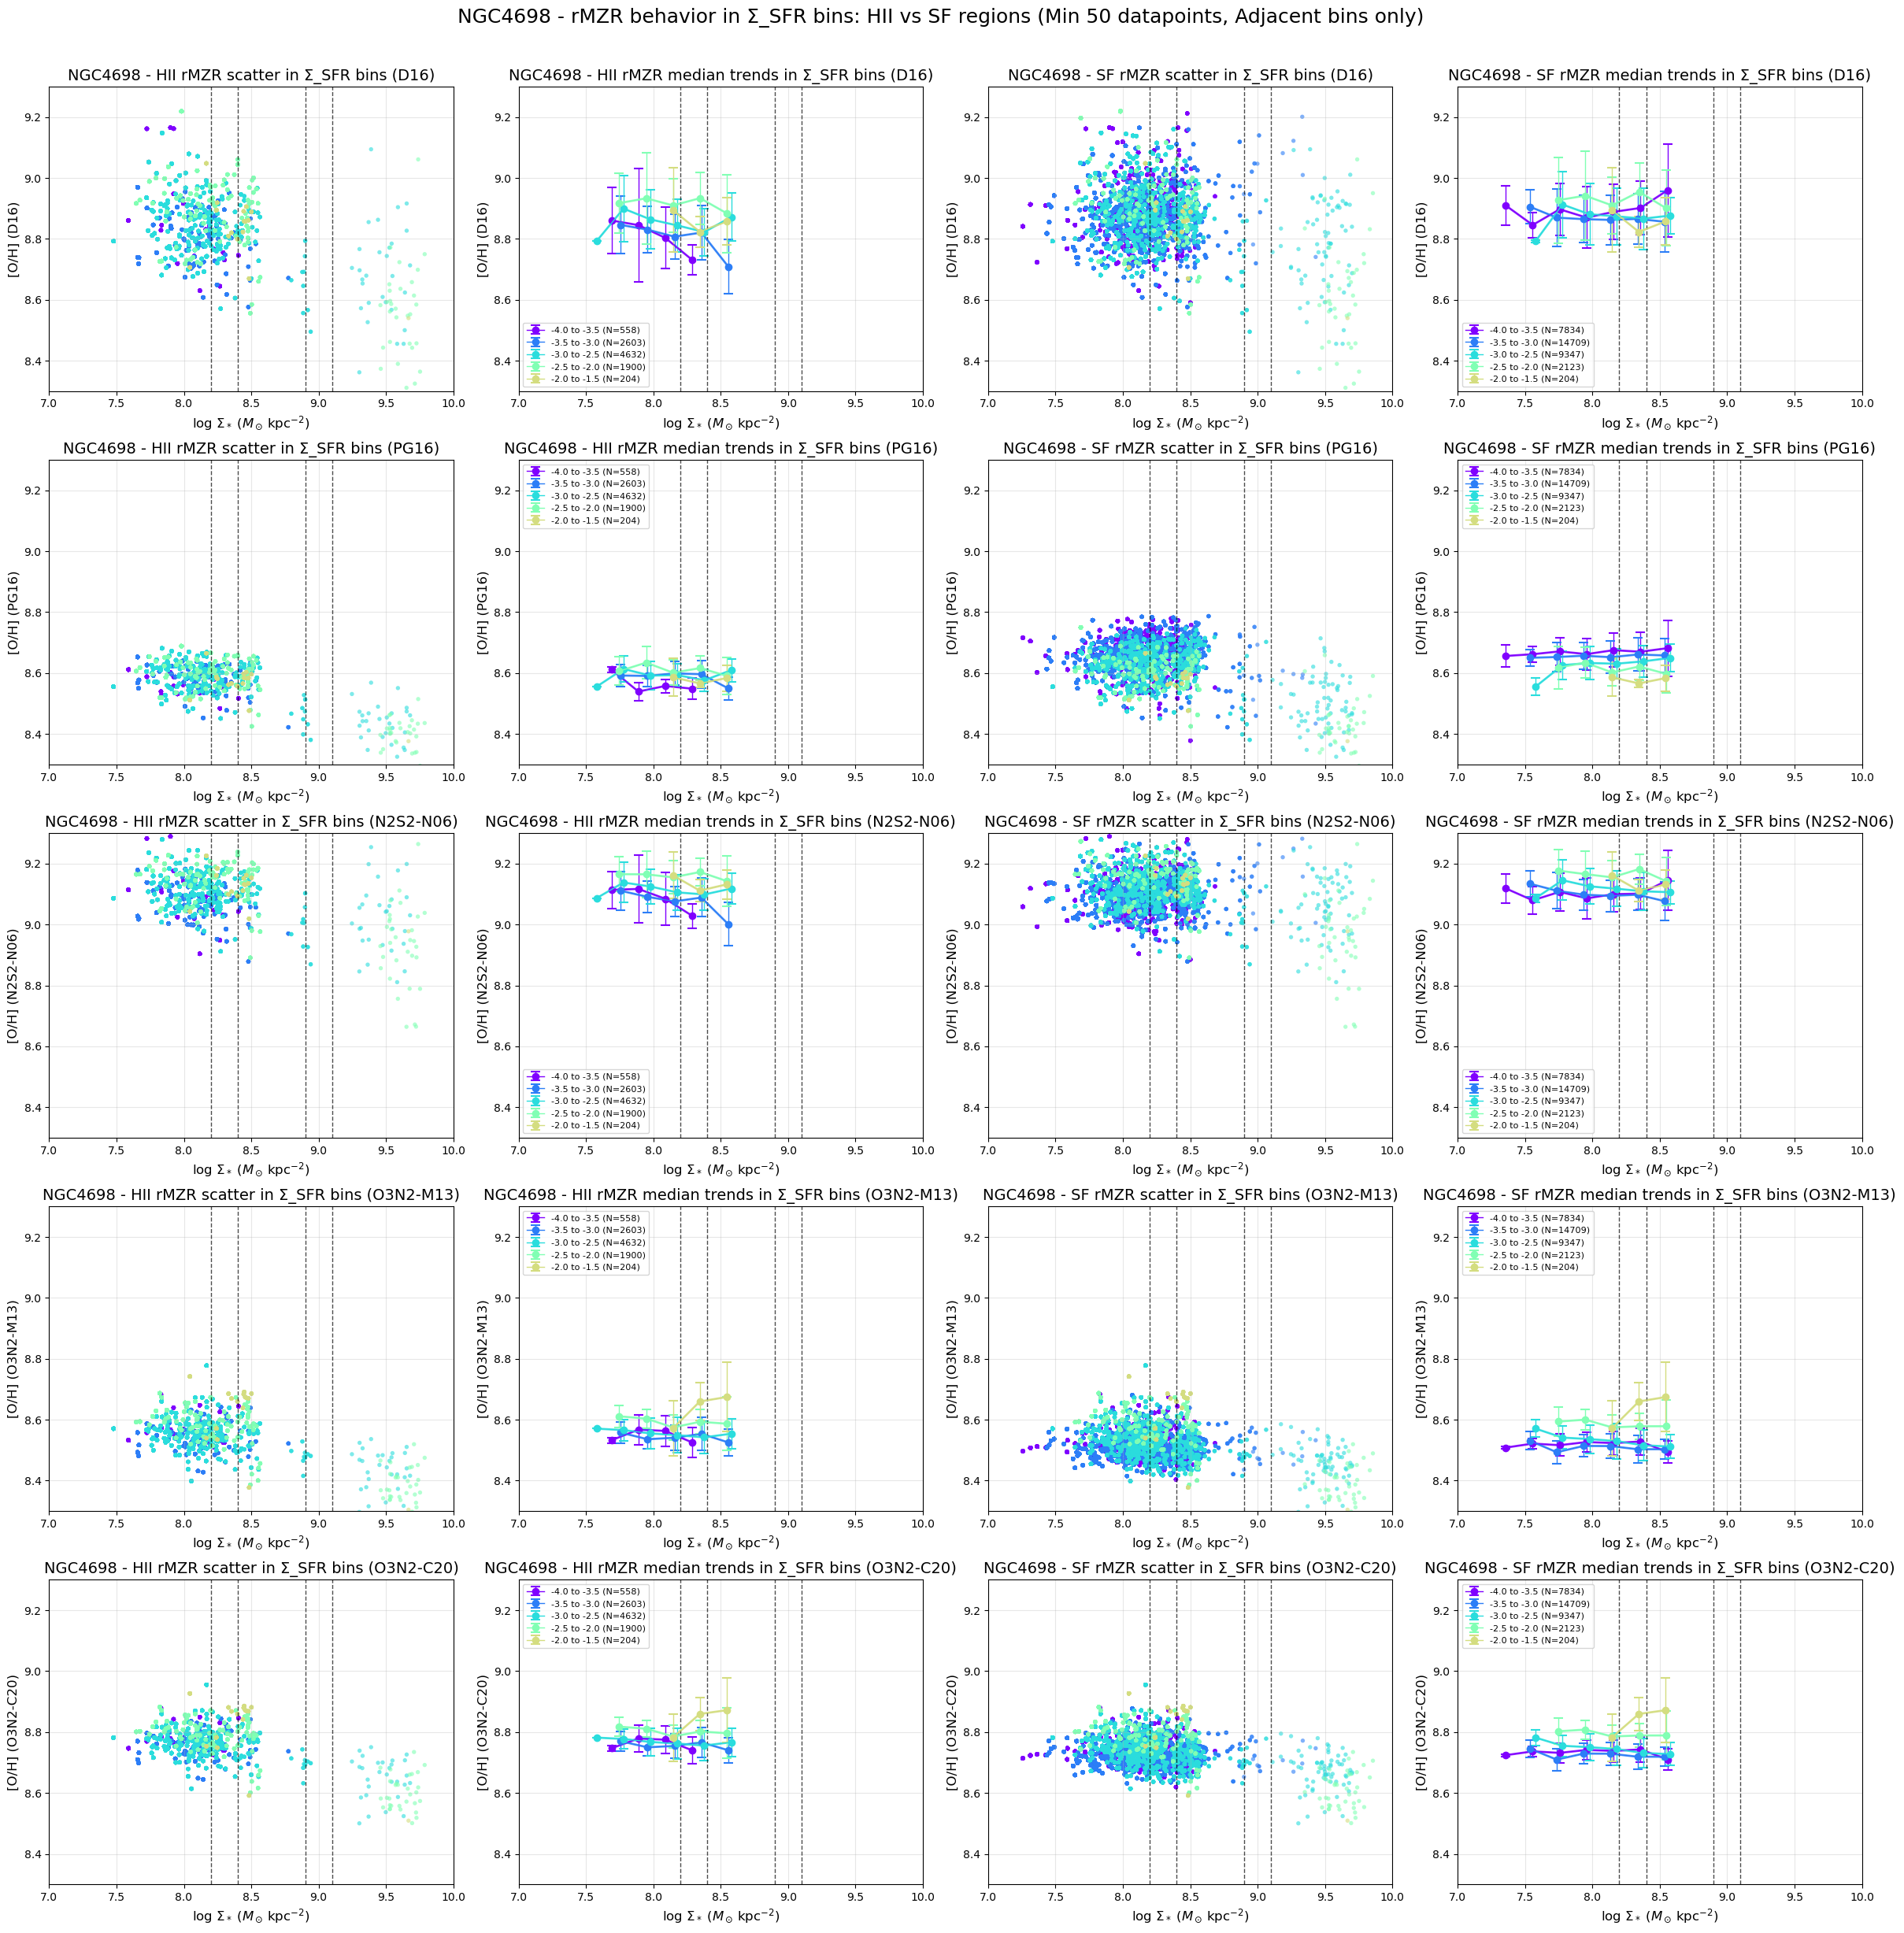


Successfully created combined 5x4 subplot figure showing both HII and SF regions
Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)
Using uniform y-axis range: 8.3 to 9.3
Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins


In [29]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - Combined scatter plots and median trends
# 5 rows x 4 columns: HII regions (scatter + median) + SF regions (scatter + median)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_n2s2_n06_HII = h['O_H_N2S2_N06_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_n2s2_n06_SF = h['O_H_N2S2_N06_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.8)

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data for both HII and SF regions
    (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
     logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = load_maps_all_calibrations(gal)

    # Find common spaxels for HII regions
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_n2s2_n06_HII) & np.isfinite(oh_o3n2_m13_HII) & 
                       np.isfinite(oh_o3n2_c20_HII))
    
    # Find common spaxels for SF regions
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_n2s2_n06_SF) & np.isfinite(oh_o3n2_m13_SF) & 
                      np.isfinite(oh_o3n2_c20_SF))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid HII pixels across all calibrations: {np.sum(common_mask_HII)}")
    print(f"Common valid SF pixels across all calibrations: {np.sum(common_mask_SF)}")

    # Define Σ_SFR bins: -4 to 0.0 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.0, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Set uniform y-axis range
    common_ylim = (8.3, 9.3)
    
    # Define vertical line positions
    vline_positions = [8.2, 8.4, 8.9, 9.1]
    
    print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
    
    # Create figure with 5 rows x 4 columns 
    # Columns: HII scatter, HII median, SF scatter, SF median
    fig, axes = plt.subplots(5, 4, figsize=(24, 25))
    
    # Data for each calibration
    calibrations_HII = [
        (oh_d16_HII, 'D16'),
        (oh_pg16_HII, 'PG16'),
        (oh_n2s2_n06_HII, 'N2S2-N06'),
        (oh_o3n2_m13_HII, 'O3N2-M13'),
        (oh_o3n2_c20_HII, 'O3N2-C20')
    ]
    
    calibrations_SF = [
        (oh_d16_SF, 'D16'),
        (oh_pg16_SF, 'PG16'),
        (oh_n2s2_n06_SF, 'N2S2-N06'),
        (oh_o3n2_m13_SF, 'O3N2-M13'),
        (oh_o3n2_c20_SF, 'O3N2-C20')
    ]
    
    # Process each calibration (one row per calibration)
    for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
        print(f"\nProcessing {calib_name_HII} calibration for both HII and SF regions:")
        
        # Get axes for this row
        ax_scatter_HII = axes[row_idx, 0]  # Column 0: HII scatter plots
        ax_median_HII = axes[row_idx, 1]   # Column 1: HII median trends
        ax_scatter_SF = axes[row_idx, 2]   # Column 2: SF scatter plots
        ax_median_SF = axes[row_idx, 3]    # Column 3: SF median trends
        
        # Process HII regions (columns 0 and 1)
        logSigmaSFR_HII_good = logSigmaSFR_HII[common_mask_HII]
        logSigmaM_HII_good = logSigmaM[common_mask_HII]
        oh_HII_good = oh_data_HII[common_mask_HII]
        
        print(f"  HII {calib_name_HII} range: {np.min(oh_HII_good):.3f} to {np.max(oh_HII_good):.3f}")
        
        # Process SF regions (columns 2 and 3)
        logSigmaSFR_SF_good = logSigmaSFR_SF[common_mask_SF]
        logSigmaM_SF_good = logSigmaM[common_mask_SF]
        oh_SF_good = oh_data_SF[common_mask_SF]
        
        print(f"  SF {calib_name_SF} range: {np.min(oh_SF_good):.3f} to {np.max(oh_SF_good):.3f}")
        
        # Plot each Σ_SFR bin for both HII and SF regions
        valid_bins_HII = 0
        valid_bins_SF = 0
        
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # HII regions processing
            in_bin_HII = (logSigmaSFR_HII_good >= bin_start) & (logSigmaSFR_HII_good < bin_end)
            n_pixels_HII = np.sum(in_bin_HII)
            
            if n_pixels_HII >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_HII = logSigmaM_HII_good[in_bin_HII]
                y_bin_HII = oh_HII_good[in_bin_HII]
                
                # HII Scatter plot (column 0)
                ax_scatter_HII.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                     label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})',
                                     edgecolors='none')
                
                # HII Median trends (column 1)
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                    x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_HII) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_HII, mass_centers_HII, medians_HII, stds_HII, 
                        valid_bin_indices_HII, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})')
                    valid_bins_HII += 1
            
            # SF regions processing
            in_bin_SF = (logSigmaSFR_SF_good >= bin_start) & (logSigmaSFR_SF_good < bin_end)
            n_pixels_SF = np.sum(in_bin_SF)
            
            if n_pixels_SF >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_SF = logSigmaM_SF_good[in_bin_SF]
                y_bin_SF = oh_SF_good[in_bin_SF]
                
                # SF Scatter plot (column 2)
                ax_scatter_SF.scatter(x_bin_SF, y_bin_SF, c=[colors[i]], s=15, alpha=0.6, 
                                    label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})',
                                    edgecolors='none')
                
                # SF Median trends (column 3)
                mass_centers_SF, medians_SF, stds_SF, counts_SF, valid_bin_indices_SF = calculate_binned_stats(
                    x_bin_SF, y_bin_SF, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_SF) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_SF, mass_centers_SF, medians_SF, stds_SF, 
                        valid_bin_indices_SF, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})')
                    valid_bins_SF += 1
        
        # Add vertical dashed lines to all four plots in this row
        for vline_x in vline_positions:
            ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_scatter_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        
        # Format HII scatter plot (column 0)
        ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_scatter_HII.set_title(f'{gal} - HII rMZR scatter in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_scatter_HII.grid(True, alpha=0.3)
        ax_scatter_HII.set_xlim(7, 10)
        ax_scatter_HII.set_ylim(common_ylim)
        
        # Format HII median trends plot (column 1)
        ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_median_HII.set_title(f'{gal} - HII rMZR median trends in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_median_HII.grid(True, alpha=0.3)
        ax_median_HII.set_xlim(7, 10)
        ax_median_HII.set_ylim(common_ylim)
        ax_median_HII.legend(fontsize=8, loc='best', framealpha=0.8)
        
        # Format SF scatter plot (column 2)
        ax_scatter_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_scatter_SF.set_title(f'{gal} - SF rMZR scatter in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_scatter_SF.grid(True, alpha=0.3)
        ax_scatter_SF.set_xlim(7, 10)
        ax_scatter_SF.set_ylim(common_ylim)
        
        # Format SF median trends plot (column 3)
        ax_median_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_median_SF.set_title(f'{gal} - SF rMZR median trends in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_median_SF.grid(True, alpha=0.3)
        ax_median_SF.set_xlim(7, 10)
        ax_median_SF.set_ylim(common_ylim)
        ax_median_SF.legend(fontsize=8, loc='best', framealpha=0.8)
        
        print(f"  Total valid bins - HII: {valid_bins_HII}, SF: {valid_bins_SF}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins: HII vs SF regions (Min 50 datapoints, Adjacent bins only)', 
                 fontsize=18, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 5x4 subplot figure showing both HII and SF regions")
print(f"Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)")
print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
print(f"Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins")

## 20250930 dynamic y-axis range

Total pixels: 722912
Common valid HII pixels across all calibrations: 10040
Common valid SF pixels across all calibrations: 34411

Processing D16 calibration for both HII and SF regions:
  HII D16 range: 8.274 to 9.219
  SF D16 range: 8.274 to 9.219
  HII y-axis range: 8.227 to 9.266
  SF y-axis range: 8.227 to 9.266
  Total valid bins - HII: 5, SF: 5

Processing PG16 calibration for both HII and SF regions:
  HII PG16 range: 7.645 to 8.689
  SF PG16 range: 7.645 to 8.787
  HII y-axis range: 7.592 to 8.741
  SF y-axis range: 7.588 to 8.844
  Total valid bins - HII: 5, SF: 5

Processing N2S2-N06 calibration for both HII and SF regions:
  HII N2S2-N06 range: 8.664 to 9.309
  SF N2S2-N06 range: 8.664 to 9.309
  HII y-axis range: 8.632 to 9.341
  SF y-axis range: 8.632 to 9.341
  Total valid bins - HII: 5, SF: 5

Processing O3N2-M13 calibration for both HII and SF regions:
  HII O3N2-M13 range: 8.297 to 8.778
  SF O3N2-M13 range: 8.297 to 8.778
  HII y-axis range: 8.273 to 8.802
  SF y-axi

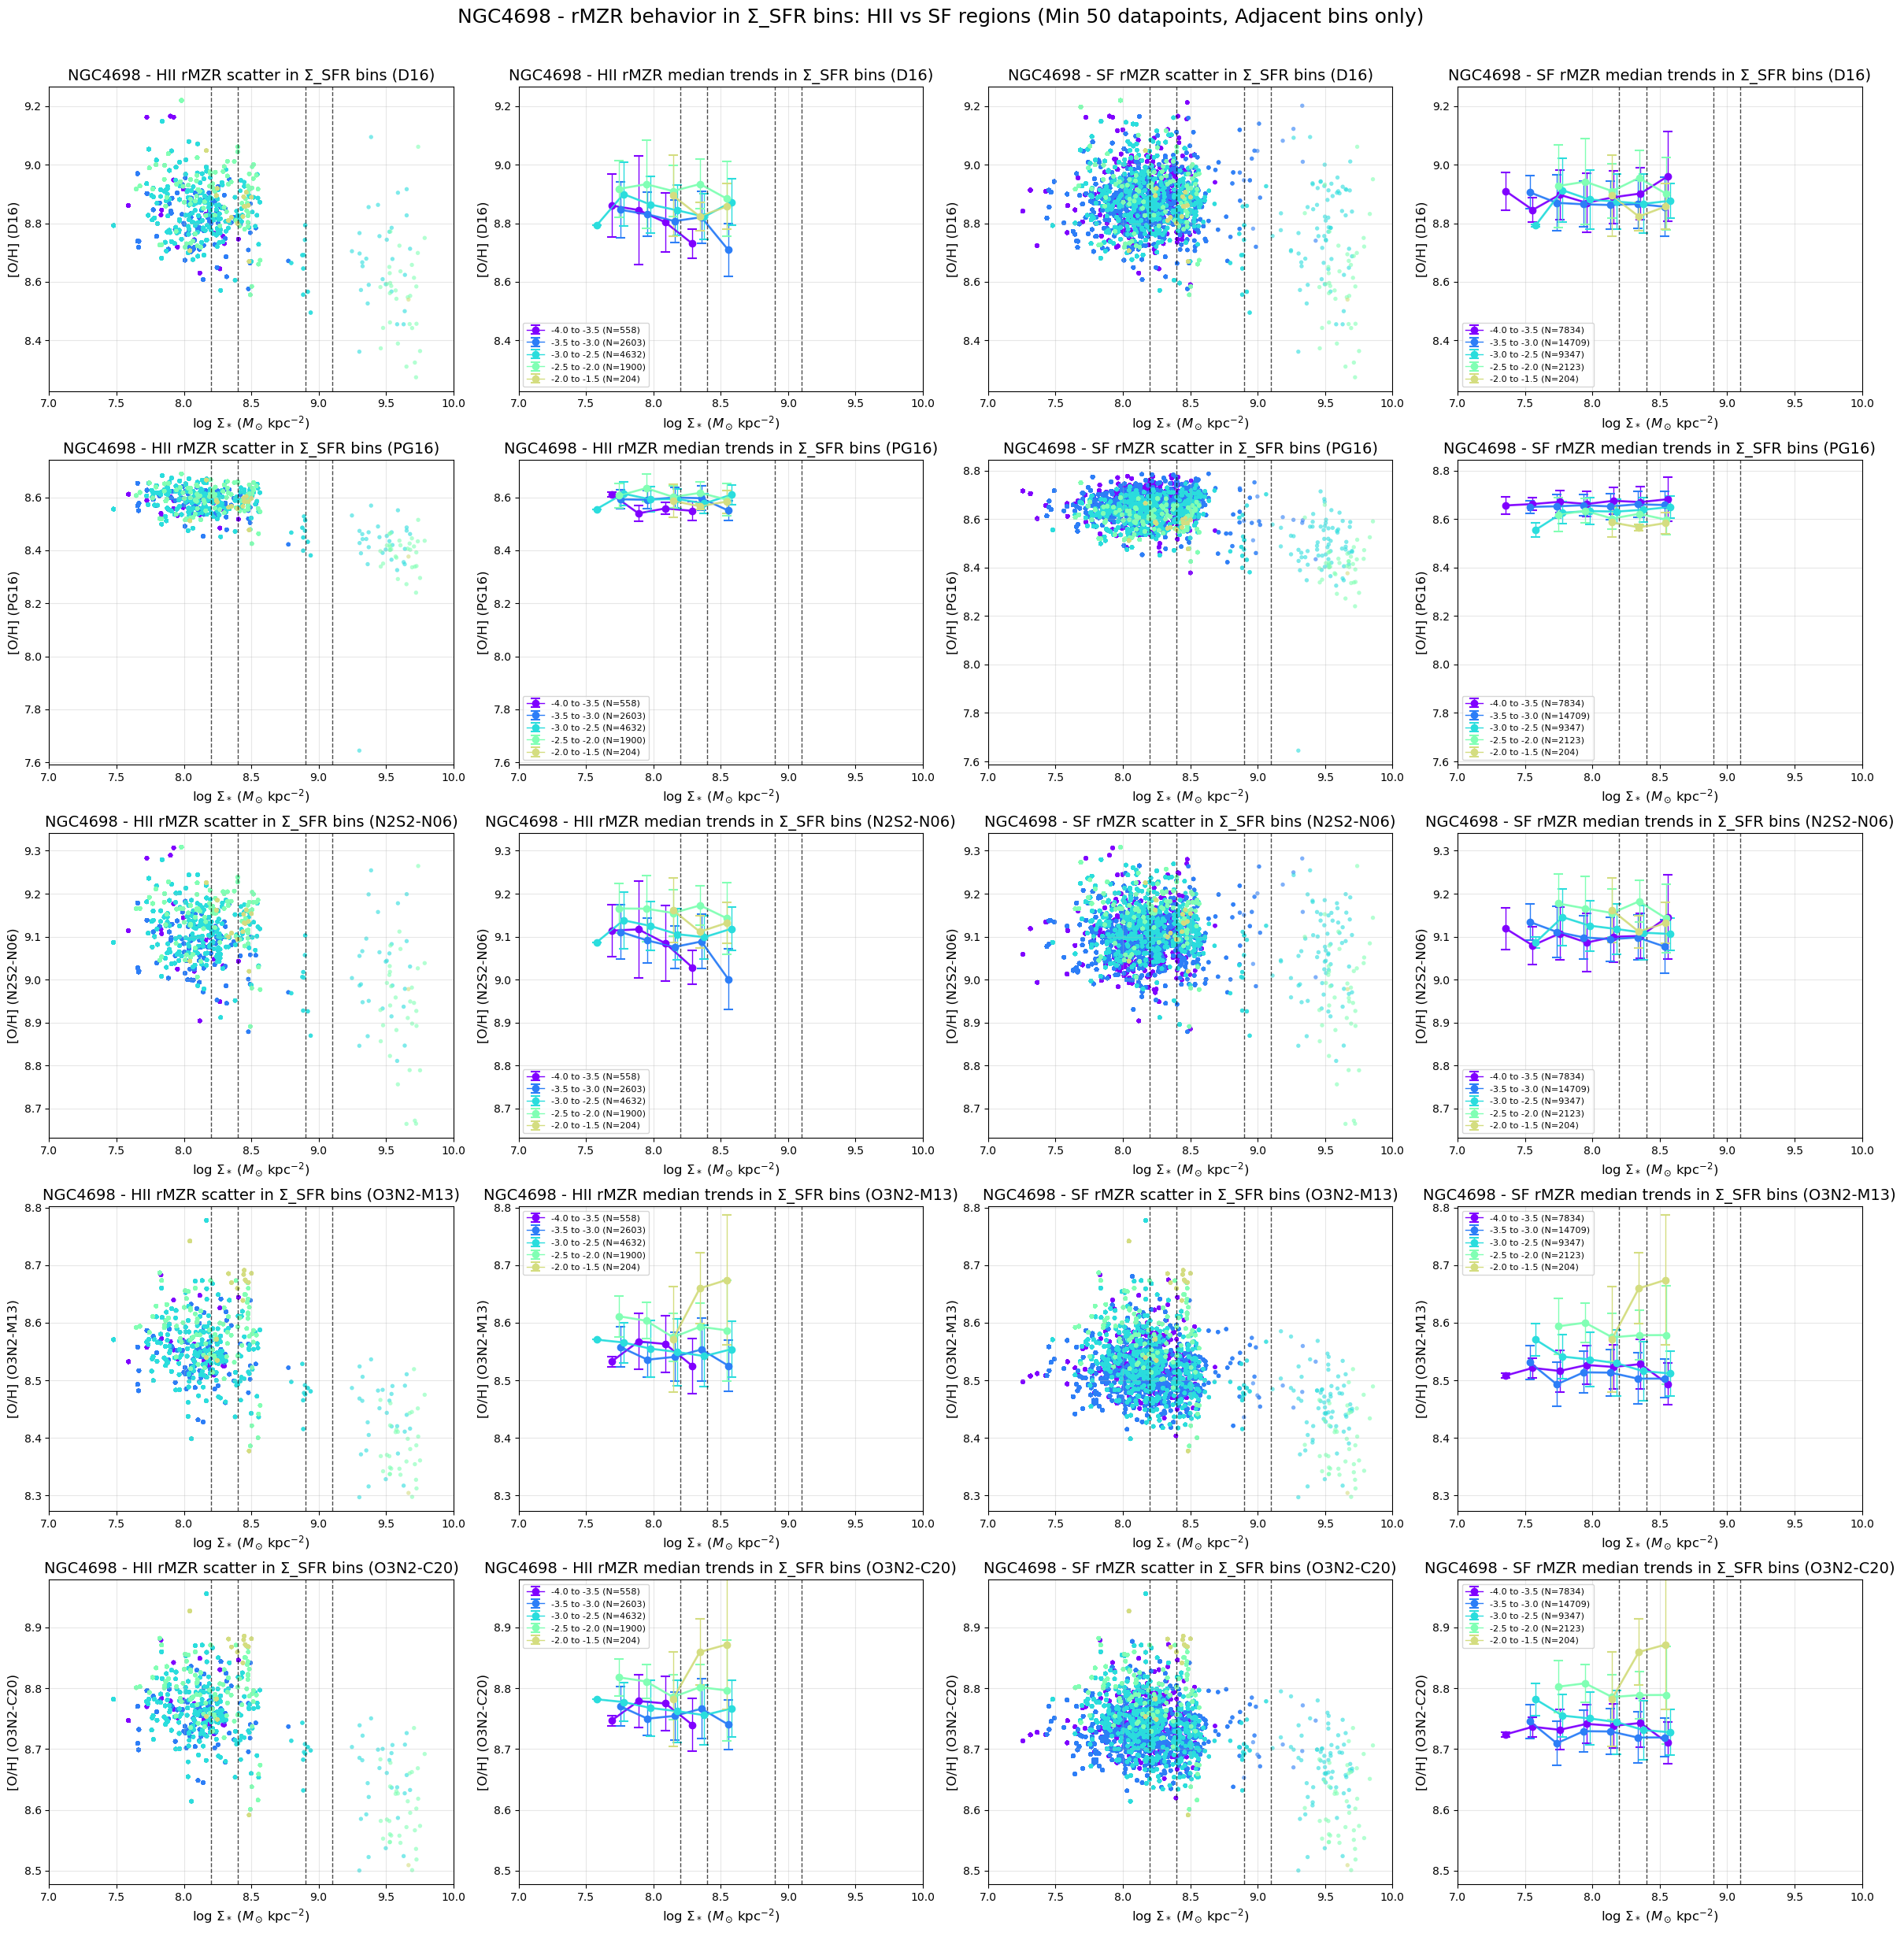


Successfully created combined 5x4 subplot figure showing both HII and SF regions
Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)
Using adaptive y-axis ranges based on actual data ranges for each calibration
Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins


In [30]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - Combined scatter plots and median trends
# 5 rows x 4 columns: HII regions (scatter + median) + SF regions (scatter + median)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_n2s2_n06_HII = h['O_H_N2S2_N06_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_n2s2_n06_SF = h['O_H_N2S2_N06_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.8)

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data for both HII and SF regions
    (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
     logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = load_maps_all_calibrations(gal)

    # Find common spaxels for HII regions
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_n2s2_n06_HII) & np.isfinite(oh_o3n2_m13_HII) & 
                       np.isfinite(oh_o3n2_c20_HII))
    
    # Find common spaxels for SF regions
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_n2s2_n06_SF) & np.isfinite(oh_o3n2_m13_SF) & 
                      np.isfinite(oh_o3n2_c20_SF))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid HII pixels across all calibrations: {np.sum(common_mask_HII)}")
    print(f"Common valid SF pixels across all calibrations: {np.sum(common_mask_SF)}")

    # Define Σ_SFR bins: -4 to 0.0 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.0, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Define vertical line positions
    vline_positions = [8.2, 8.4, 8.9, 9.1]
    
    # Create figure with 5 rows x 4 columns 
    # Columns: HII scatter, HII median, SF scatter, SF median
    fig, axes = plt.subplots(5, 4, figsize=(24, 25))
    
    # Data for each calibration
    calibrations_HII = [
        (oh_d16_HII, 'D16'),
        (oh_pg16_HII, 'PG16'),
        (oh_n2s2_n06_HII, 'N2S2-N06'),
        (oh_o3n2_m13_HII, 'O3N2-M13'),
        (oh_o3n2_c20_HII, 'O3N2-C20')
    ]
    
    calibrations_SF = [
        (oh_d16_SF, 'D16'),
        (oh_pg16_SF, 'PG16'),
        (oh_n2s2_n06_SF, 'N2S2-N06'),
        (oh_o3n2_m13_SF, 'O3N2-M13'),
        (oh_o3n2_c20_SF, 'O3N2-C20')
    ]
    
    # Process each calibration (one row per calibration)
    for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
        print(f"\nProcessing {calib_name_HII} calibration for both HII and SF regions:")
        
        # Get axes for this row
        ax_scatter_HII = axes[row_idx, 0]  # Column 0: HII scatter plots
        ax_median_HII = axes[row_idx, 1]   # Column 1: HII median trends
        ax_scatter_SF = axes[row_idx, 2]   # Column 2: SF scatter plots
        ax_median_SF = axes[row_idx, 3]    # Column 3: SF median trends
        
        # Process HII regions (columns 0 and 1)
        logSigmaSFR_HII_good = logSigmaSFR_HII[common_mask_HII]
        logSigmaM_HII_good = logSigmaM[common_mask_HII]
        oh_HII_good = oh_data_HII[common_mask_HII]
        
        print(f"  HII {calib_name_HII} range: {np.min(oh_HII_good):.3f} to {np.max(oh_HII_good):.3f}")
        
        # Process SF regions (columns 2 and 3)
        logSigmaSFR_SF_good = logSigmaSFR_SF[common_mask_SF]
        logSigmaM_SF_good = logSigmaM[common_mask_SF]
        oh_SF_good = oh_data_SF[common_mask_SF]
        
        print(f"  SF {calib_name_SF} range: {np.min(oh_SF_good):.3f} to {np.max(oh_SF_good):.3f}")
        
        # Calculate dynamic y-axis ranges for scatter plots
        # For HII regions scatter plot
        all_y_HII = []
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            in_bin_HII = (logSigmaSFR_HII_good >= bin_start) & (logSigmaSFR_HII_good < bin_end)
            if np.sum(in_bin_HII) >= 10:
                all_y_HII.extend(oh_HII_good[in_bin_HII])
        
        if all_y_HII:
            y_min_HII = np.min(all_y_HII)
            y_max_HII = np.max(all_y_HII)
            y_range_HII = y_max_HII - y_min_HII
            y_margin_HII = y_range_HII * 0.05  # 5% margin
            ylim_HII = (y_min_HII - y_margin_HII, y_max_HII + y_margin_HII)
        else:
            ylim_HII = (8.3, 9.3)  # fallback
        
        # For SF regions scatter plot
        all_y_SF = []
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            in_bin_SF = (logSigmaSFR_SF_good >= bin_start) & (logSigmaSFR_SF_good < bin_end)
            if np.sum(in_bin_SF) >= 10:
                all_y_SF.extend(oh_SF_good[in_bin_SF])
        
        if all_y_SF:
            y_min_SF = np.min(all_y_SF)
            y_max_SF = np.max(all_y_SF)
            y_range_SF = y_max_SF - y_min_SF
            y_margin_SF = y_range_SF * 0.05  # 5% margin
            ylim_SF = (y_min_SF - y_margin_SF, y_max_SF + y_margin_SF)
        else:
            ylim_SF = (8.3, 9.3)  # fallback
        
        print(f"  HII y-axis range: {ylim_HII[0]:.3f} to {ylim_HII[1]:.3f}")
        print(f"  SF y-axis range: {ylim_SF[0]:.3f} to {ylim_SF[1]:.3f}")
        
        # Plot each Σ_SFR bin for both HII and SF regions
        valid_bins_HII = 0
        valid_bins_SF = 0
        
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # HII regions processing
            in_bin_HII = (logSigmaSFR_HII_good >= bin_start) & (logSigmaSFR_HII_good < bin_end)
            n_pixels_HII = np.sum(in_bin_HII)
            
            if n_pixels_HII >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_HII = logSigmaM_HII_good[in_bin_HII]
                y_bin_HII = oh_HII_good[in_bin_HII]
                
                # HII Scatter plot (column 0)
                ax_scatter_HII.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                     label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})',
                                     edgecolors='none')
                
                # HII Median trends (column 1)
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                    x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_HII) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_HII, mass_centers_HII, medians_HII, stds_HII, 
                        valid_bin_indices_HII, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})')
                    valid_bins_HII += 1
            
            # SF regions processing
            in_bin_SF = (logSigmaSFR_SF_good >= bin_start) & (logSigmaSFR_SF_good < bin_end)
            n_pixels_SF = np.sum(in_bin_SF)
            
            if n_pixels_SF >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_SF = logSigmaM_SF_good[in_bin_SF]
                y_bin_SF = oh_SF_good[in_bin_SF]
                
                # SF Scatter plot (column 2)
                ax_scatter_SF.scatter(x_bin_SF, y_bin_SF, c=[colors[i]], s=15, alpha=0.6, 
                                    label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})',
                                    edgecolors='none')
                
                # SF Median trends (column 3)
                mass_centers_SF, medians_SF, stds_SF, counts_SF, valid_bin_indices_SF = calculate_binned_stats(
                    x_bin_SF, y_bin_SF, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_SF) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_SF, mass_centers_SF, medians_SF, stds_SF, 
                        valid_bin_indices_SF, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})')
                    valid_bins_SF += 1
        
        # Add vertical dashed lines to all four plots in this row
        for vline_x in vline_positions:
            ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_scatter_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        
        # Format HII scatter plot (column 0)
        ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_scatter_HII.set_title(f'{gal} - HII rMZR scatter in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_scatter_HII.grid(True, alpha=0.3)
        ax_scatter_HII.set_xlim(7, 10)
        ax_scatter_HII.set_ylim(ylim_HII)
        
        # Format HII median trends plot (column 1) - use same y-axis as scatter
        ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_median_HII.set_title(f'{gal} - HII rMZR median trends in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_median_HII.grid(True, alpha=0.3)
        ax_median_HII.set_xlim(7, 10)
        ax_median_HII.set_ylim(ylim_HII)  # Same as scatter plot
        ax_median_HII.legend(fontsize=8, loc='best', framealpha=0.8)
        
        # Format SF scatter plot (column 2)
        ax_scatter_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_scatter_SF.set_title(f'{gal} - SF rMZR scatter in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_scatter_SF.grid(True, alpha=0.3)
        ax_scatter_SF.set_xlim(7, 10)
        ax_scatter_SF.set_ylim(ylim_SF)
        
        # Format SF median trends plot (column 3) - use same y-axis as scatter
        ax_median_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_median_SF.set_title(f'{gal} - SF rMZR median trends in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_median_SF.grid(True, alpha=0.3)
        ax_median_SF.set_xlim(7, 10)
        ax_median_SF.set_ylim(ylim_SF)  # Same as scatter plot
        ax_median_SF.legend(fontsize=8, loc='best', framealpha=0.8)
        
        print(f"  Total valid bins - HII: {valid_bins_HII}, SF: {valid_bins_SF}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins: HII vs SF regions (Min 50 datapoints, Adjacent bins only)', 
                 fontsize=18, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 5x4 subplot figure showing both HII and SF regions")
print(f"Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)")
print(f"Using adaptive y-axis ranges based on actual data ranges for each calibration")
print(f"Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins")

Total pixels: 722912
Common valid HII pixels across all calibrations: 10040
Common valid SF pixels across all calibrations: 34411

Processing D16 calibration for both HII and SF regions:
  HII D16 range: 8.274 to 9.219
  SF D16 range: 8.274 to 9.219
  HII y-axis range: 8.227 to 9.266
  SF y-axis range: 8.227 to 9.266
  Total valid bins - HII: 5, SF: 5

Processing PG16 calibration for both HII and SF regions:
  HII PG16 range: 7.645 to 8.689
  SF PG16 range: 7.645 to 8.787
  HII y-axis range: 7.592 to 8.741
  SF y-axis range: 7.588 to 8.844
  Total valid bins - HII: 5, SF: 5

Processing N2S2-N06 calibration for both HII and SF regions:
  HII N2S2-N06 range: 8.664 to 9.309
  SF N2S2-N06 range: 8.664 to 9.309
  HII y-axis range: 8.632 to 9.341
  SF y-axis range: 8.632 to 9.341
  Total valid bins - HII: 5, SF: 5

Processing O3N2-M13 calibration for both HII and SF regions:
  HII O3N2-M13 range: 8.297 to 8.778
  SF O3N2-M13 range: 8.297 to 8.778
  HII y-axis range: 8.273 to 8.802
  SF y-axi

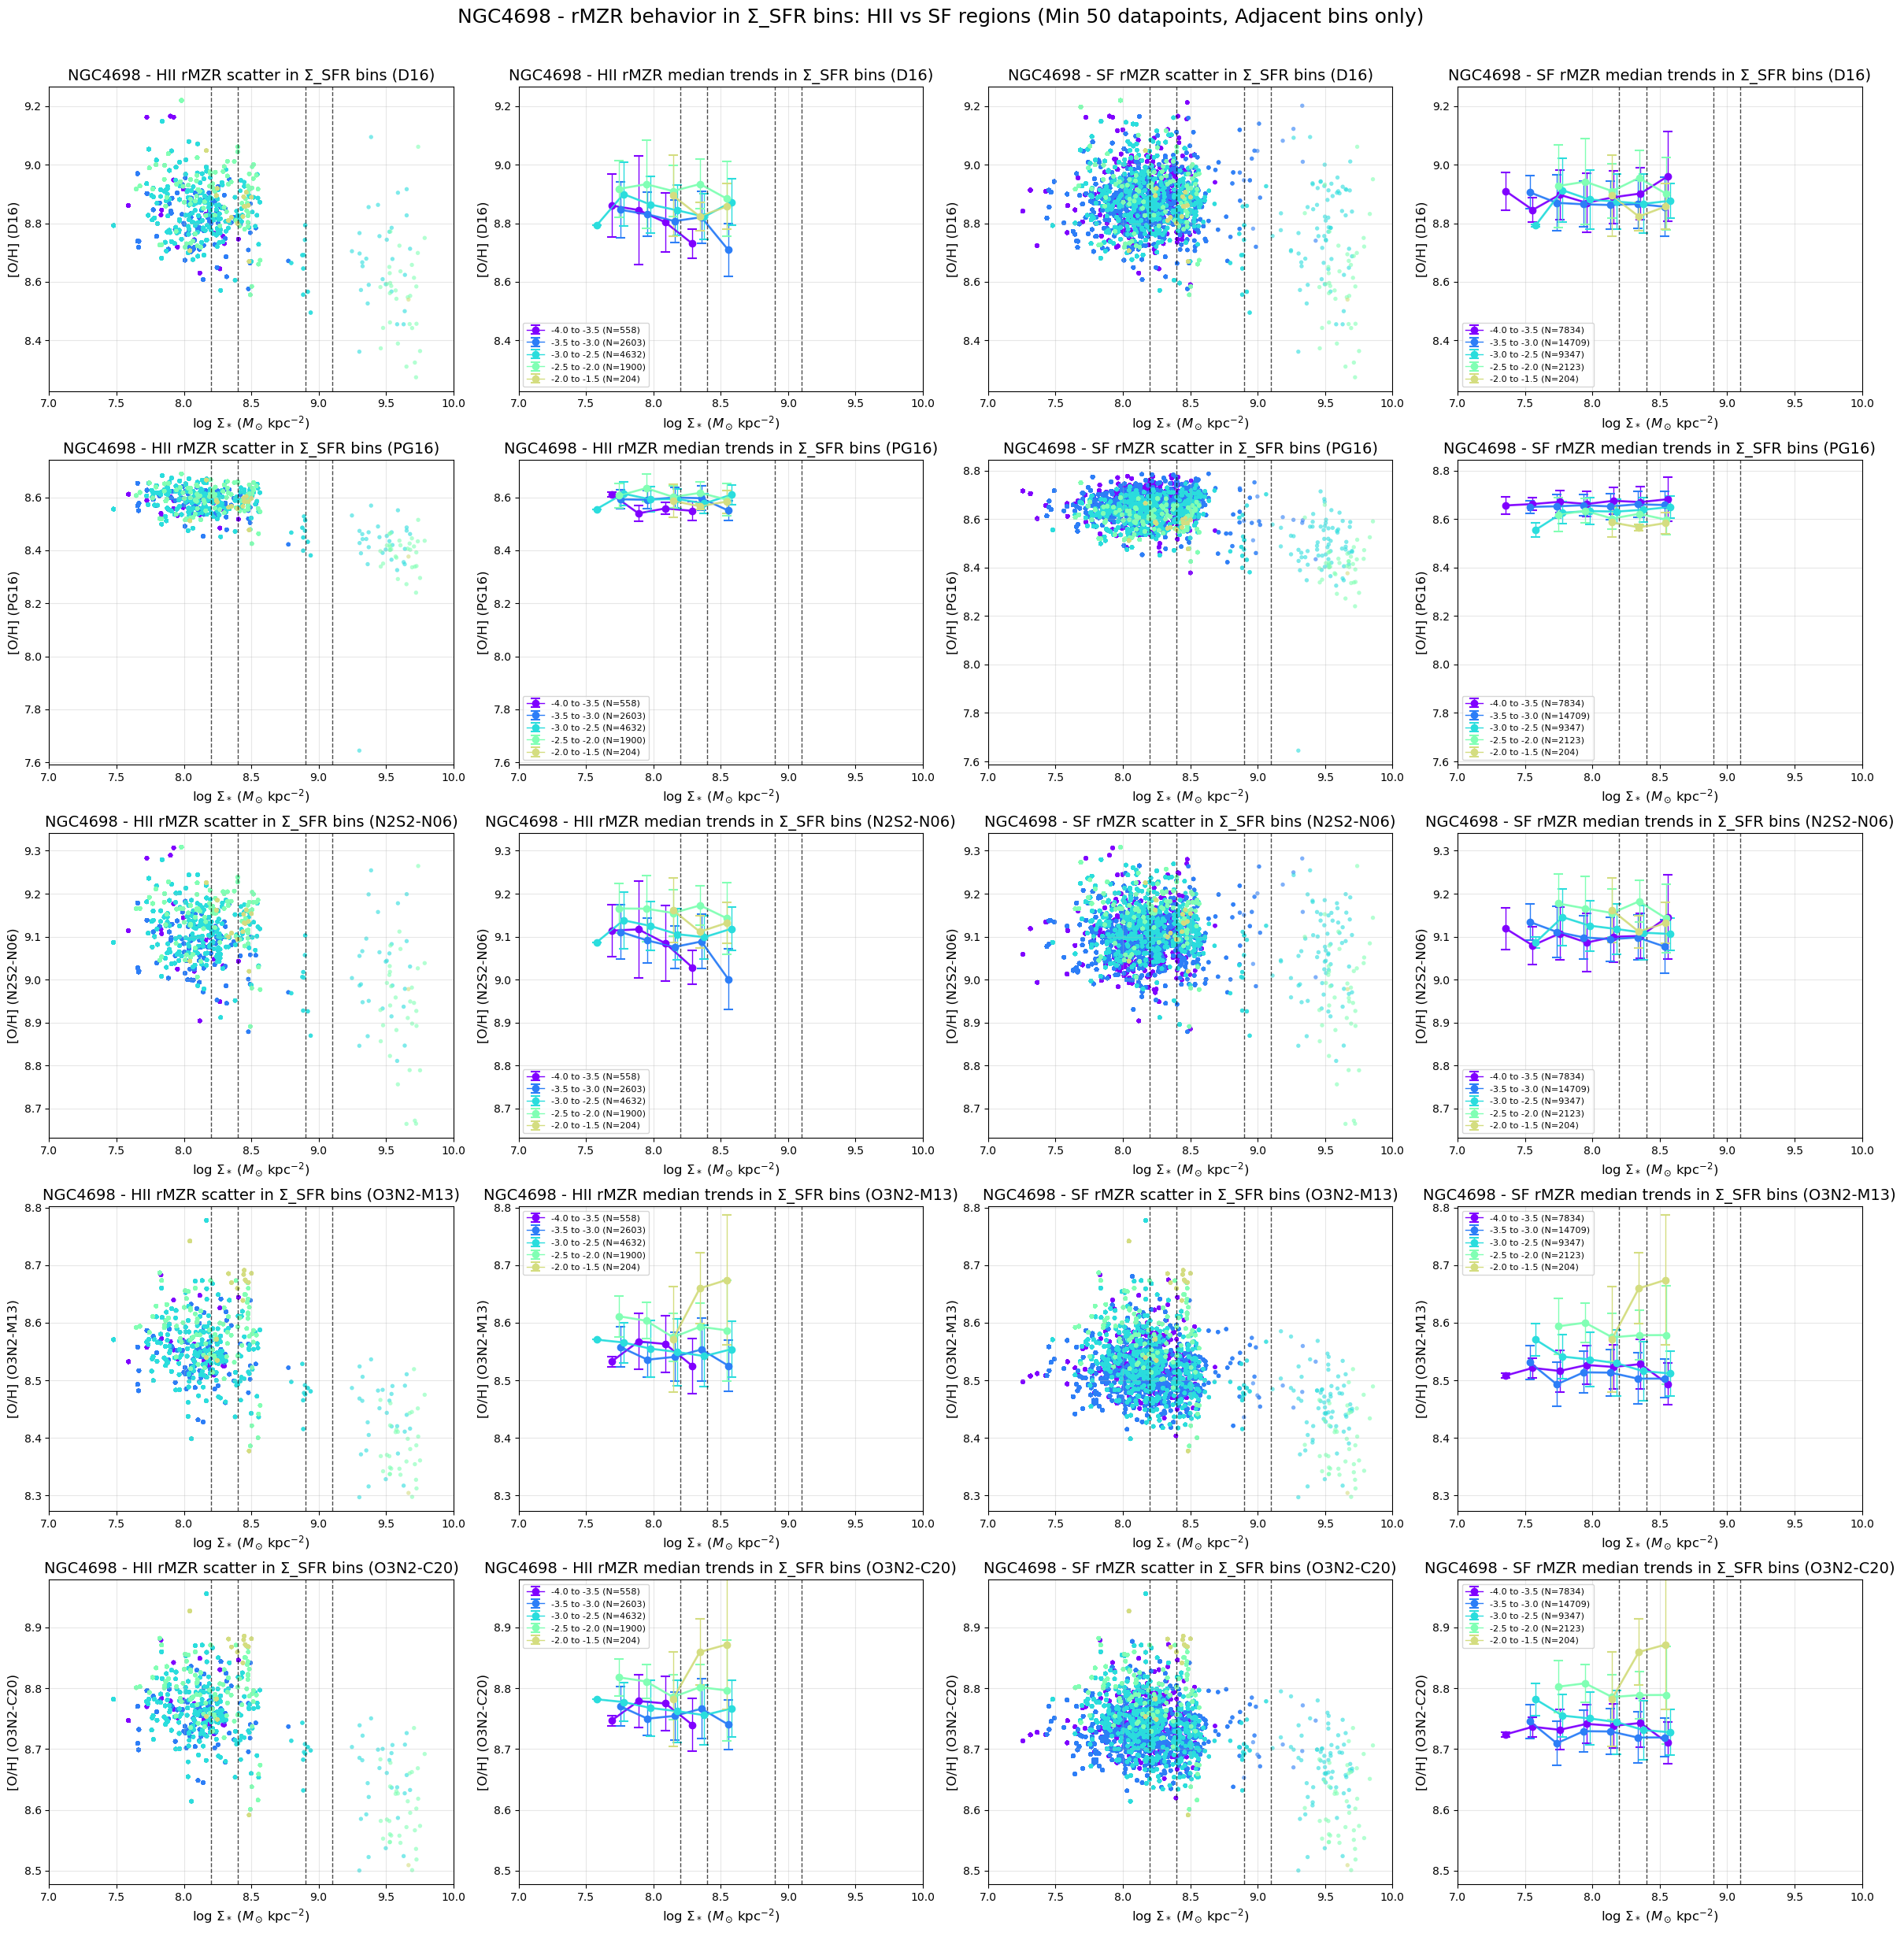


Successfully created combined 5x4 subplot figure showing both HII and SF regions
Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)
Using adaptive y-axis ranges based on actual data ranges for each calibration
Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins


In [31]:
# ------------------------------------------------------------------
# NGC4698 rMZR behavior in Σ_SFR bins - Combined scatter plots and median trends
# 5 rows x 4 columns: HII regions (scatter + median) + SF regions (scatter + median)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_n2s2_n06_HII = h['O_H_N2S2_N06_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_n2s2_n06_SF = h['O_H_N2S2_N06_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.8)

# Focus on NGC4698 only
gal = 'NGC4698'
bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

if bin_file.exists() and gas_file.exists():
    # Load all data for both HII and SF regions
    (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
     logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = load_maps_all_calibrations(gal)

    # Find common spaxels for HII regions
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_n2s2_n06_HII) & np.isfinite(oh_o3n2_m13_HII) & 
                       np.isfinite(oh_o3n2_c20_HII))
    
    # Find common spaxels for SF regions
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_n2s2_n06_SF) & np.isfinite(oh_o3n2_m13_SF) & 
                      np.isfinite(oh_o3n2_c20_SF))
    
    print(f"Total pixels: {np.size(logSigmaM)}")
    print(f"Common valid HII pixels across all calibrations: {np.sum(common_mask_HII)}")
    print(f"Common valid SF pixels across all calibrations: {np.sum(common_mask_SF)}")

    # Define Σ_SFR bins: -4 to 0.0 with 0.5 bin width
    sfr_bin_edges = np.arange(-4, 0.0, 0.5)
    n_bins = len(sfr_bin_edges) - 1
    
    # Colors for different bins
    colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
    
    # Define vertical line positions
    vline_positions = [8.2, 8.4, 8.9, 9.1]
    
    # Create figure with 5 rows x 4 columns 
    # Columns: HII scatter, HII median, SF scatter, SF median
    fig, axes = plt.subplots(5, 4, figsize=(24, 25))
    
    # Data for each calibration
    calibrations_HII = [
        (oh_d16_HII, 'D16'),
        (oh_pg16_HII, 'PG16'),
        (oh_n2s2_n06_HII, 'N2S2-N06'),
        (oh_o3n2_m13_HII, 'O3N2-M13'),
        (oh_o3n2_c20_HII, 'O3N2-C20')
    ]
    
    calibrations_SF = [
        (oh_d16_SF, 'D16'),
        (oh_pg16_SF, 'PG16'),
        (oh_n2s2_n06_SF, 'N2S2-N06'),
        (oh_o3n2_m13_SF, 'O3N2-M13'),
        (oh_o3n2_c20_SF, 'O3N2-C20')
    ]
    
    # Process each calibration (one row per calibration)
    for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
        print(f"\nProcessing {calib_name_HII} calibration for both HII and SF regions:")
        
        # Get axes for this row
        ax_scatter_HII = axes[row_idx, 0]  # Column 0: HII scatter plots
        ax_median_HII = axes[row_idx, 1]   # Column 1: HII median trends
        ax_scatter_SF = axes[row_idx, 2]   # Column 2: SF scatter plots
        ax_median_SF = axes[row_idx, 3]    # Column 3: SF median trends
        
        # Process HII regions (columns 0 and 1)
        logSigmaSFR_HII_good = logSigmaSFR_HII[common_mask_HII]
        logSigmaM_HII_good = logSigmaM[common_mask_HII]
        oh_HII_good = oh_data_HII[common_mask_HII]
        
        print(f"  HII {calib_name_HII} range: {np.min(oh_HII_good):.3f} to {np.max(oh_HII_good):.3f}")
        
        # Process SF regions (columns 2 and 3)
        logSigmaSFR_SF_good = logSigmaSFR_SF[common_mask_SF]
        logSigmaM_SF_good = logSigmaM[common_mask_SF]
        oh_SF_good = oh_data_SF[common_mask_SF]
        
        print(f"  SF {calib_name_SF} range: {np.min(oh_SF_good):.3f} to {np.max(oh_SF_good):.3f}")
        
        # Calculate dynamic y-axis ranges for scatter plots
        # For HII regions scatter plot
        all_y_HII = []
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            in_bin_HII = (logSigmaSFR_HII_good >= bin_start) & (logSigmaSFR_HII_good < bin_end)
            if np.sum(in_bin_HII) >= 10:
                all_y_HII.extend(oh_HII_good[in_bin_HII])
        
        if all_y_HII:
            y_min_HII = np.min(all_y_HII)
            y_max_HII = np.max(all_y_HII)
            y_range_HII = y_max_HII - y_min_HII
            y_margin_HII = y_range_HII * 0.05  # 5% margin
            ylim_HII = (y_min_HII - y_margin_HII, y_max_HII + y_margin_HII)
        else:
            ylim_HII = (8.3, 9.3)  # fallback
        
        # For SF regions scatter plot
        all_y_SF = []
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            in_bin_SF = (logSigmaSFR_SF_good >= bin_start) & (logSigmaSFR_SF_good < bin_end)
            if np.sum(in_bin_SF) >= 10:
                all_y_SF.extend(oh_SF_good[in_bin_SF])
        
        if all_y_SF:
            y_min_SF = np.min(all_y_SF)
            y_max_SF = np.max(all_y_SF)
            y_range_SF = y_max_SF - y_min_SF
            y_margin_SF = y_range_SF * 0.05  # 5% margin
            ylim_SF = (y_min_SF - y_margin_SF, y_max_SF + y_margin_SF)
        else:
            ylim_SF = (8.3, 9.3)  # fallback
        
        print(f"  HII y-axis range: {ylim_HII[0]:.3f} to {ylim_HII[1]:.3f}")
        print(f"  SF y-axis range: {ylim_SF[0]:.3f} to {ylim_SF[1]:.3f}")
        
        # Plot each Σ_SFR bin for both HII and SF regions
        valid_bins_HII = 0
        valid_bins_SF = 0
        
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # HII regions processing
            in_bin_HII = (logSigmaSFR_HII_good >= bin_start) & (logSigmaSFR_HII_good < bin_end)
            n_pixels_HII = np.sum(in_bin_HII)
            
            if n_pixels_HII >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_HII = logSigmaM_HII_good[in_bin_HII]
                y_bin_HII = oh_HII_good[in_bin_HII]
                
                # HII Scatter plot (column 0)
                ax_scatter_HII.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                     label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})',
                                     edgecolors='none')
                
                # HII Median trends (column 1)
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                    x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_HII) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_HII, mass_centers_HII, medians_HII, stds_HII, 
                        valid_bin_indices_HII, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_HII})')
                    valid_bins_HII += 1
            
            # SF regions processing
            in_bin_SF = (logSigmaSFR_SF_good >= bin_start) & (logSigmaSFR_SF_good < bin_end)
            n_pixels_SF = np.sum(in_bin_SF)
            
            if n_pixels_SF >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_SF = logSigmaM_SF_good[in_bin_SF]
                y_bin_SF = oh_SF_good[in_bin_SF]
                
                # SF Scatter plot (column 2)
                ax_scatter_SF.scatter(x_bin_SF, y_bin_SF, c=[colors[i]], s=15, alpha=0.6, 
                                    label=f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})',
                                    edgecolors='none')
                
                # SF Median trends (column 3)
                mass_centers_SF, medians_SF, stds_SF, counts_SF, valid_bin_indices_SF = calculate_binned_stats(
                    x_bin_SF, y_bin_SF, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_SF) > 0:
                    plot_median_trend_with_adjacency(
                        ax_median_SF, mass_centers_SF, medians_SF, stds_SF, 
                        valid_bin_indices_SF, colors[i],
                        f'{bin_start:.1f} to {bin_end:.1f} (N={n_pixels_SF})')
                    valid_bins_SF += 1
        
        # Add vertical dashed lines to all four plots in this row
        for vline_x in vline_positions:
            ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_scatter_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax_median_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        
        # Format HII scatter plot (column 0)
        ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_scatter_HII.set_title(f'{gal} - HII rMZR scatter in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_scatter_HII.grid(True, alpha=0.3)
        ax_scatter_HII.set_xlim(7, 10)
        ax_scatter_HII.set_ylim(ylim_HII)
        
        # Format HII median trends plot (column 1) - use same y-axis as scatter
        ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_median_HII.set_title(f'{gal} - HII rMZR median trends in Σ_SFR bins ({calib_name_HII})', fontsize=14)
        ax_median_HII.grid(True, alpha=0.3)
        ax_median_HII.set_xlim(7, 10)
        ax_median_HII.set_ylim(ylim_HII)  # Same as scatter plot
        ax_median_HII.legend(fontsize=8, loc='best', framealpha=0.8)
        
        # Format SF scatter plot (column 2)
        ax_scatter_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_scatter_SF.set_title(f'{gal} - SF rMZR scatter in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_scatter_SF.grid(True, alpha=0.3)
        ax_scatter_SF.set_xlim(7, 10)
        ax_scatter_SF.set_ylim(ylim_SF)
        
        # Format SF median trends plot (column 3) - use same y-axis as scatter
        ax_median_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
        ax_median_SF.set_title(f'{gal} - SF rMZR median trends in Σ_SFR bins ({calib_name_SF})', fontsize=14)
        ax_median_SF.grid(True, alpha=0.3)
        ax_median_SF.set_xlim(7, 10)
        ax_median_SF.set_ylim(ylim_SF)  # Same as scatter plot
        ax_median_SF.legend(fontsize=8, loc='best', framealpha=0.8)
        
        print(f"  Total valid bins - HII: {valid_bins_HII}, SF: {valid_bins_SF}")
    
    # Add overall title and adjust layout
    fig.suptitle(f'{gal} - rMZR behavior in Σ_SFR bins: HII vs SF regions (Min 50 datapoints, Adjacent bins only)', 
                 fontsize=18, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # Make room for suptitle
    plt.show()
    
else:
    print(f"Data files not found for {gal}")

print(f"\nSuccessfully created combined 5x4 subplot figure showing both HII and SF regions")
print(f"Layout: Columns 0-1 = HII regions (scatter + median), Columns 2-3 = SF regions (scatter + median)")
print(f"Using adaptive y-axis ranges based on actual data ranges for each calibration")
print(f"Requirements: Min 50 datapoints per bin, only connecting adjacent mass bins")